# **Proyek Analisis Data: SmartInvest Portofolio**

## Business Problem

Pertumbuhan jumlah investor di Indonesia yang didominasi oleh generasi muda belum diimbangi dengan kemampuan analisis investasi yang memadai. Investor pemula cenderung mengambil keputusan spekulatif tanpa mempertimbangkan risiko dan diversifikasi. Hal ini meningkatkan potensi kerugian dan menghasilkan alokasi portofolio yang tidak optimal.

## Objective

Proyek ini bertujuan untuk menganalisis data historis saham LQ45 guna memahami hubungan antara return dan risiko, serta menghasilkan insight yang dapat membantu dalam pengambilan keputusan investasi dan penyusunan portofolio yang lebih optimal.

## Analytical Questions

- Bagaimana distribusi return dan risiko (volatilitas) saham LQ45 dan IDX30 selama periode pengamatan 1 April 2021 – 1 April 2026?

- Saham LQ45 dan IDX30 mana yang memiliki rata-rata return tertinggi dan terendah dalam periode tersebut?

- Saham mana yang memiliki tingkat risiko (standar deviasi return) paling tinggi dan paling rendah?

- Bagaimana hubungan (korelasi) antar saham LQ45 dan IDX30, dan saham mana yang memiliki korelasi rendah untuk kebutuhan diversifikasi portofolio?

- Saham mana yang memberikan kombinasi risk-return terbaik berdasarkan rasio (misalnya Sharpe Ratio) selama periode analisis?

- Bagaimana komposisi portofolio optimal yang dapat dibentuk dari saham LQ45 dan IDX30 untuk memaksimalkan return dengan risiko minimum?

- Bagaimana performa portofolio optimal dibandingkan dengan investasi pada satu saham saja dalam periode yang sama?

## Import Semua Packages/Library yang Digunakan

In [ ]:
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from dateutil.relativedelta import relativedelta

## Data Wrangling

## 1. Data Gathering

### Definisi List Saham

#### Definisi List Saham

In [ ]:
# 1.2 DEFINISI LIST SAHAM
idx30_stocks = [
    "AADI.JK","ADMR.JK","ADRO.JK","AMRT.JK","ANTM.JK","ASII.JK",
    "BBCA.JK","BBNI.JK","BBRI.JK","BMRI.JK","BRPT.JK","BUMI.JK",
    "CPIN.JK","EMTK.JK","GOTO.JK","ICBP.JK","INCO.JK","INDF.JK",
    "INKP.JK","JPFA.JK","KLBF.JK","MBMA.JK","MDKA.JK","MEDC.JK",
    "PGAS.JK","PGEO.JK","PTBA.JK","TLKM.JK","UNTR.JK","UNVR.JK"
]

lq45_stocks = [
    "AADI.JK","ADMR.JK","ADRO.JK","AKRA.JK","AMMN.JK","AMRT.JK",
    "ANTM.JK","ASII.JK","BBCA.JK","BBNI.JK","BBRI.JK","BBTN.JK",
    "BMRI.JK","BRPT.JK","BUMI.JK","CPIN.JK","CUAN.JK","DEWA.JK",
    "EMTK.JK","ESSA.JK","EXCL.JK","GOTO.JK","HRTA.JK","ICBP.JK",
    "INCO.JK","INDF.JK","INKP.JK","ISAT.JK","ITMG.JK","JPFA.JK",
    "KLBF.JK","MAPI.JK","MBMA.JK","MDKA.JK","MEDC.JK","PGAS.JK",
    "PGEO.JK","PTBA.JK","SCMA.JK","SMGR.JK","TLKM.JK","TOWR.JK",
    "UNTR.JK","UNVR.JK","WIFI.JK"
]

#### Mapping Index

In [ ]:
# 1.3 MAPPING INDEX
index_map = {
    "IDX30": idx30_stocks,
    "LQ45": lq45_stocks
}

#### Periode Data (5 Tahun)

In [ ]:
# 1.4 PERIODE DATA (5 TAHUN)
start_date = "2021-04-01"
end_date   = "2026-04-01"
interval   = "1d"

market_ticker = "^JKSE"   # IHSG

In [ ]:
# Gabungkan semua ticker tanpa duplikasi
all_stock_tickers = sorted(list(set(idx30_stocks + lq45_stocks)))

print("Jumlah saham unik:", len(all_stock_tickers))
print(all_stock_tickers)

Jumlah saham unik: 45
['AADI.JK', 'ADMR.JK', 'ADRO.JK', 'AKRA.JK', 'AMMN.JK', 'AMRT.JK', 'ANTM.JK', 'ASII.JK', 'BBCA.JK', 'BBNI.JK', 'BBRI.JK', 'BBTN.JK', 'BMRI.JK', 'BRPT.JK', 'BUMI.JK', 'CPIN.JK', 'CUAN.JK', 'DEWA.JK', 'EMTK.JK', 'ESSA.JK', 'EXCL.JK', 'GOTO.JK', 'HRTA.JK', 'ICBP.JK', 'INCO.JK', 'INDF.JK', 'INKP.JK', 'ISAT.JK', 'ITMG.JK', 'JPFA.JK', 'KLBF.JK', 'MAPI.JK', 'MBMA.JK', 'MDKA.JK', 'MEDC.JK', 'PGAS.JK', 'PGEO.JK', 'PTBA.JK', 'SCMA.JK', 'SMGR.JK', 'TLKM.JK', 'TOWR.JK', 'UNTR.JK', 'UNVR.JK', 'WIFI.JK']


#### Download Data Saham

In [ ]:
# 1.5 FUNGSI DOWNLOAD DATA
def download_stock_data(ticker, start_date, end_date, interval="1d"):
    try:
        df = yf.download(
            ticker,
            start=start_date,
            end=end_date,
            interval=interval,
            auto_adjust=False,
            progress=False
        )

        if df.empty:
            print(f"[WARNING] Data kosong: {ticker}")
            return None

        # Handle MultiIndex
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        df = df.reset_index()
        df["Ticker"] = ticker

        # Pastikan kolom Date bertipe datetime
        df["Date"] = pd.to_datetime(df["Date"])

        # Pilih kolom yang dibutuhkan
        required_cols = [
            "Date", "Ticker", "Open", "High", "Low",
            "Close", "Adj Close", "Volume"
        ]

        df = df[required_cols]

        return df

    except Exception as e:
        print(f"[ERROR] {ticker}: {e}")
        return None

#### Download Data Semua Saham

In [ ]:
# Download Data Semua Saham
stock_data_list = []

for ticker in all_stock_tickers:
    print(f"Download saham: {ticker}")
    data = download_stock_data(ticker, start_date, end_date, interval)

    if data is not None:
        stock_data_list.append(data)

Download saham: AADI.JK
Download saham: ADMR.JK
Download saham: ADRO.JK
Download saham: AKRA.JK
Download saham: AMMN.JK
Download saham: AMRT.JK
Download saham: ANTM.JK
Download saham: ASII.JK
Download saham: BBCA.JK
Download saham: BBNI.JK
Download saham: BBRI.JK
Download saham: BBTN.JK
Download saham: BMRI.JK
Download saham: BRPT.JK
Download saham: BUMI.JK
Download saham: CPIN.JK
Download saham: CUAN.JK
Download saham: DEWA.JK
Download saham: EMTK.JK
Download saham: ESSA.JK
Download saham: EXCL.JK
Download saham: GOTO.JK
Download saham: HRTA.JK
Download saham: ICBP.JK
Download saham: INCO.JK
Download saham: INDF.JK
Download saham: INKP.JK
Download saham: ISAT.JK
Download saham: ITMG.JK
Download saham: JPFA.JK
Download saham: KLBF.JK
Download saham: MAPI.JK
Download saham: MBMA.JK
Download saham: MDKA.JK
Download saham: MEDC.JK
Download saham: PGAS.JK
Download saham: PGEO.JK
Download saham: PTBA.JK
Download saham: SCMA.JK
Download saham: SMGR.JK
Download saham: TLKM.JK
Download saham: 

#### Gabungkan Data Saham

In [ ]:
# Gabungkan Data Saham
if stock_data_list:
    raw_stock_data = pd.concat(stock_data_list, ignore_index=True)
    print("✅ Data saham berhasil digabungkan")
else:
    raw_stock_data = pd.DataFrame()
    print("❌ Tidak ada data saham yang berhasil diambil")

display(raw_stock_data.head())
print("Shape raw_stock_data:", raw_stock_data.shape)
print("Jumlah ticker saham:", raw_stock_data["Ticker"].nunique())

✅ Data saham berhasil digabungkan


Price,Date,Ticker,Open,High,Low,Close,Adj Close,Volume
0,2024-12-05,AADI.JK,6650.0,6650.0,6650.0,6650.0,6241.059082,459400
1,2024-12-06,AADI.JK,7975.0,7975.0,7975.0,7975.0,7484.578125,446600
2,2024-12-09,AADI.JK,9550.0,9550.0,9550.0,9550.0,8962.723633,43658100
3,2024-12-10,AADI.JK,10500.0,11375.0,9600.0,10275.0,9643.139648,228636600
4,2024-12-11,AADI.JK,10275.0,10450.0,9575.0,9600.0,9009.649414,100219900


Shape raw_stock_data: (50622, 8)
Jumlah ticker saham: 45


#### Download Data IHSG

In [ ]:
# 1.7 Download Data IHSG
raw_market_data = download_stock_data(
    market_ticker,
    start_date,
    end_date,
    interval
)

if raw_market_data is not None:
    raw_market_data = raw_market_data.rename(columns={"Ticker": "Market"})
    print("✅ Data IHSG berhasil diambil")
else:
    raw_market_data = pd.DataFrame()
    print("❌ Data IHSG gagal diambil")

display(raw_market_data.head())
print("Shape raw_market_data:", raw_market_data.shape)

✅ Data IHSG berhasil diambil


Price,Date,Market,Open,High,Low,Close,Adj Close,Volume
0,2021-04-01,^JKSE,5988.022949,6020.164062,5960.816895,6011.456055,6011.456055,106367400
1,2021-04-05,^JKSE,6040.055176,6051.621094,5964.483887,5970.286133,5970.286133,122053600
2,2021-04-06,^JKSE,5973.986816,6008.504883,5944.420898,6002.770020,6002.770020,126386100
3,2021-04-07,^JKSE,6011.958008,6040.456055,5982.066895,6036.616211,6036.616211,141523800
4,2021-04-08,^JKSE,6035.037109,6073.914062,6030.286133,6071.724121,6071.724121,169546400


Shape raw_market_data: (1199, 8)


#### Load BI-Rate

In [ ]:
# 1.8 Load BI-Rate

bi_rate_file = "BI-Rate.xlsx"  # pastikan file ada di directory

print("File BI Rate:", bi_rate_file)

# Load file
raw_bi_rate = pd.read_excel(bi_rate_file)

# Final check
display(raw_bi_rate.head())
display(raw_bi_rate.tail())

# Info dasar
print("Shape raw_bi_rate:", raw_bi_rate.shape)
print("Kolom raw_bi_rate:", raw_bi_rate.columns.tolist())

# Rename kolom agar aman (hindari tanda "-")
raw_bi_rate = raw_bi_rate.rename(columns={
    "BI-Rate": "BI_Rate"
})

# Pastikan tipe data benar
raw_bi_rate["Date"] = pd.to_datetime(raw_bi_rate["Date"])
raw_bi_rate["BI_Rate"] = raw_bi_rate["BI_Rate"].astype(float)

# Sort tanggal (penting)
raw_bi_rate = raw_bi_rate.sort_values(by="Date").reset_index(drop=True)

print("\nTipe data:")
print(raw_bi_rate.dtypes)

File BI Rate: BI-Rate.xlsx


,Date,BI-Rate
0,2026-03-17,0.0475
1,2026-02-19,0.0475
2,2026-01-21,0.0475
3,2025-12-17,0.0475
4,2025-11-19,0.0475


,Date,BI-Rate
56,2021-07-22,0.035
57,2021-06-17,0.035
58,2021-05-25,0.035
59,2021-04-20,0.035
60,2021-03-18,0.035


Shape raw_bi_rate: (61, 2)
Kolom raw_bi_rate: ['Date', 'BI-Rate']

Tipe data:
Date       datetime64[ns]
BI_Rate           float64
dtype: object


#### Simpan Raw Data

In [ ]:
# Simpan Raw Data
raw_stock_data.to_csv("raw_stock_data_lq45_idx30.csv", index=False)
raw_market_data.to_csv("raw_market_data_ihsg.csv", index=False)
raw_bi_rate.to_csv("raw_bi_rate.csv", index=False)

print("✅ File raw berhasil disimpan:")
print("- raw_stock_data_lq45_idx30.csv")
print("- raw_market_data_ihsg.csv")
print("- raw_bi_rate.csv")

✅ File raw berhasil disimpan:
- raw_stock_data_lq45_idx30.csv
- raw_market_data_ihsg.csv
- raw_bi_rate.csv


**Insight:**
- Data saham dari indeks IDX30 dan LQ45 berhasil digabungkan menjadi 45 ticker saham unik tanpa duplikasi ticker.
- Dataset `raw_stock_data` berhasil dibentuk dengan total 50.622 baris data historis saham periode 2021–2026.
- Data IHSG (`^JKSE`) berhasil diambil sebagai market benchmark dengan total 1.199 baris data.
- Data BI Rate berhasil dimuat dan dikonversi ke format yang sesuai (`datetime` dan `float`) sehingga siap digunakan sebagai risk-free rate pada analisis CAPM dan Sharpe Ratio.
- Seluruh dataset berhasil distandarisasi dan disimpan dalam format CSV untuk mendukung proses analisis dan preprocessing selanjutnya.
- Beberapa saham kemungkinan memiliki histori data yang tidak lengkap karena faktor IPO atau keterbatasan data perdagangan sehingga perlu dilakukan filtering pada tahap berikutnya.


## 2. Data Assessing

### Assessing Data Saham

#### Cek Ukuran Data Saham

In [ ]:
# 2.1.1 Cek ukuran data saham
print("=== SHAPE DATA SAHAM ===")
print("Ukuran data saham:", raw_stock_data.shape)

=== SHAPE DATA SAHAM ===
Ukuran data saham: (50622, 8)


#### Cek Informasi Data Saham

In [ ]:
# 2.1.2 Cek informasi data saham
print("\n=== INFO DATA SAHAM ===")
raw_stock_data.info()


=== INFO DATA SAHAM ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50622 entries, 0 to 50621
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       50622 non-null  datetime64[ns]
 1   Ticker     50622 non-null  object        
 2   Open       50622 non-null  float64       
 3   High       50622 non-null  float64       
 4   Low        50622 non-null  float64       
 5   Close      50622 non-null  float64       
 6   Adj Close  50622 non-null  float64       
 7   Volume     50622 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 3.1+ MB


#### Preview Data Saham

In [ ]:
# 2.1.3 Preview data saham
print("\n=== 5 BARIS PERTAMA DATA SAHAM ===")
display(raw_stock_data.head())

print("\n=== 5 BARIS TERAKHIR DATA SAHAM ===")
display(raw_stock_data.tail())


=== 5 BARIS PERTAMA DATA SAHAM ===


Price,Date,Ticker,Open,High,Low,Close,Adj Close,Volume
0,2024-12-05,AADI.JK,6650.0,6650.0,6650.0,6650.0,6241.059082,459400
1,2024-12-06,AADI.JK,7975.0,7975.0,7975.0,7975.0,7484.578125,446600
2,2024-12-09,AADI.JK,9550.0,9550.0,9550.0,9550.0,8962.723633,43658100
3,2024-12-10,AADI.JK,10500.0,11375.0,9600.0,10275.0,9643.139648,228636600
4,2024-12-11,AADI.JK,10275.0,10450.0,9575.0,9600.0,9009.649414,100219900



=== 5 BARIS TERAKHIR DATA SAHAM ===


Price,Date,Ticker,Open,High,Low,Close,Adj Close,Volume
50617,2026-03-25,WIFI.JK,2000.0,2230.0,2000.0,2200.0,2200.0,38022200
50618,2026-03-26,WIFI.JK,2240.0,2270.0,2150.0,2180.0,2180.0,22709400
50619,2026-03-27,WIFI.JK,2150.0,2230.0,2140.0,2200.0,2200.0,14668600
50620,2026-03-30,WIFI.JK,2140.0,2200.0,2120.0,2170.0,2170.0,17482200
50621,2026-03-31,WIFI.JK,2180.0,2200.0,2120.0,2130.0,2130.0,10847300


#### Cek Daftar Kolom

In [ ]:
# 2.1.4 Cek daftar kolom
print("\n=== DAFTAR KOLOM DATA SAHAM ===")
print(raw_stock_data.columns.tolist())


=== DAFTAR KOLOM DATA SAHAM ===
['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


#### Cek Tipe Data

In [ ]:
# 2.1.5 Cek tipe data
print("\n=== TIPE DATA DATA SAHAM ===")
print(raw_stock_data.dtypes)


=== TIPE DATA DATA SAHAM ===
Price
Date         datetime64[ns]
Ticker               object
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object


#### Cek Jumlah Ticker Unik

In [ ]:
# 2.1.6 Cek jumlah ticker unik
print("\n=== JUMLAH TICKER UNIK DATA SAHAM ===")
print(raw_stock_data["Ticker"].nunique())

print("\n=== DAFTAR TICKER DATA SAHAM ===")
print(sorted(raw_stock_data["Ticker"].unique().tolist()))


=== JUMLAH TICKER UNIK DATA SAHAM ===
45

=== DAFTAR TICKER DATA SAHAM ===
['AADI.JK', 'ADMR.JK', 'ADRO.JK', 'AKRA.JK', 'AMMN.JK', 'AMRT.JK', 'ANTM.JK', 'ASII.JK', 'BBCA.JK', 'BBNI.JK', 'BBRI.JK', 'BBTN.JK', 'BMRI.JK', 'BRPT.JK', 'BUMI.JK', 'CPIN.JK', 'CUAN.JK', 'DEWA.JK', 'EMTK.JK', 'ESSA.JK', 'EXCL.JK', 'GOTO.JK', 'HRTA.JK', 'ICBP.JK', 'INCO.JK', 'INDF.JK', 'INKP.JK', 'ISAT.JK', 'ITMG.JK', 'JPFA.JK', 'KLBF.JK', 'MAPI.JK', 'MBMA.JK', 'MDKA.JK', 'MEDC.JK', 'PGAS.JK', 'PGEO.JK', 'PTBA.JK', 'SCMA.JK', 'SMGR.JK', 'TLKM.JK', 'TOWR.JK', 'UNTR.JK', 'UNVR.JK', 'WIFI.JK']


#### Cek Ticker Yang Gagal Terdownload

In [ ]:
# 2.1.7 Cek ticker yang gagal terdownload
downloaded_tickers = set(raw_stock_data["Ticker"].unique())

idx30_missing = sorted(list(set(idx30_stocks) - downloaded_tickers))
lq45_missing = sorted(list(set(lq45_stocks) - downloaded_tickers))

print("=== TICKER IDX30 YANG TIDAK TERDOWNLOAD ===")
print(idx30_missing)

print("\n=== TICKER LQ45 YANG TIDAK TERDOWNLOAD ===")
print(lq45_missing)

=== TICKER IDX30 YANG TIDAK TERDOWNLOAD ===
[]

=== TICKER LQ45 YANG TIDAK TERDOWNLOAD ===
[]


#### Cek Jumlah Data per Saham

In [ ]:
# 2.1.8 Cek jumlah data per saham
print("\n=== JUMLAH DATA PER SAHAM ===")
stock_counts = raw_stock_data["Ticker"].value_counts().sort_index()
print(stock_counts)


=== JUMLAH DATA PER SAHAM ===
Ticker
AADI.JK     307
ADMR.JK    1013
ADRO.JK    1199
AKRA.JK    1199
AMMN.JK     649
AMRT.JK    1199
ANTM.JK    1199
ASII.JK    1199
BBCA.JK    1199
BBNI.JK    1199
BBRI.JK    1199
BBTN.JK    1199
BMRI.JK    1199
BRPT.JK    1199
BUMI.JK    1199
CPIN.JK    1199
CUAN.JK     721
DEWA.JK    1199
EMTK.JK    1199
ESSA.JK    1199
EXCL.JK    1199
GOTO.JK     946
HRTA.JK    1199
ICBP.JK    1199
INCO.JK    1199
INDF.JK    1199
INKP.JK    1199
ISAT.JK    1199
ITMG.JK    1199
JPFA.JK    1199
KLBF.JK    1199
MAPI.JK    1199
MBMA.JK     695
MDKA.JK    1199
MEDC.JK    1199
PGAS.JK    1199
PGEO.JK     729
PTBA.JK    1199
SCMA.JK    1199
SMGR.JK    1199
TLKM.JK    1199
TOWR.JK    1199
UNTR.JK    1199
UNVR.JK    1199
WIFI.JK    1199
Name: count, dtype: int64


#### Cek Rentang Tanggal Data Saham

In [ ]:
# 2.1.9 Cek rentang tanggal data saham
print("\n=== RENTANG TANGGAL DATA SAHAM ===")
print("Tanggal minimum:", raw_stock_data["Date"].min())
print("Tanggal maksimum:", raw_stock_data["Date"].max())


=== RENTANG TANGGAL DATA SAHAM ===
Tanggal minimum: 2021-04-01 00:00:00
Tanggal maksimum: 2026-03-31 00:00:00


#### Cek Rentang Tanggal per Saham

In [ ]:
# 2.1.10 Cek rentang tanggal per saham
print("\n=== RENTANG TANGGAL PER SAHAM ===")
stock_date_range = raw_stock_data.groupby("Ticker")["Date"].agg(["min", "max", "count"])
display(stock_date_range)


=== RENTANG TANGGAL PER SAHAM ===


,min,max,count
Ticker,,,
AADI.JK,2024-12-05,2026-03-31,307
ADMR.JK,2022-01-03,2026-03-31,1013
ADRO.JK,2021-04-01,2026-03-31,1199
AKRA.JK,2021-04-01,2026-03-31,1199
AMMN.JK,2023-07-07,2026-03-31,649
AMRT.JK,2021-04-01,2026-03-31,1199
ANTM.JK,2021-04-01,2026-03-31,1199
ASII.JK,2021-04-01,2026-03-31,1199
BBCA.JK,2021-04-01,2026-03-31,1199


#### Cek Missing Value per Kolom

In [ ]:
# 2.1.11 Cek missing value per kolom
print("\n=== MISSING VALUE PER KOLOM DATA SAHAM ===")
print(raw_stock_data.isnull().sum())


=== MISSING VALUE PER KOLOM DATA SAHAM ===
Price
Date         0
Ticker       0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


#### Cek Missing Value per Saham

In [ ]:
# 2.1.12 Cek missing value per saham
print("\n=== MISSING VALUE PER SAHAM ===")
missing_stock_per_ticker = raw_stock_data.groupby("Ticker").apply(lambda x: x.isnull().sum())
display(missing_stock_per_ticker)


=== MISSING VALUE PER SAHAM ===


/tmp/ipykernel_13039/471639778.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_stock_per_ticker = raw_stock_data.groupby("Ticker").apply(lambda x: x.isnull().sum())


Price,Date,Ticker,Open,High,Low,Close,Adj Close,Volume
Ticker,,,,,,,,
AADI.JK,0,0,0,0,0,0,0,0
ADMR.JK,0,0,0,0,0,0,0,0
ADRO.JK,0,0,0,0,0,0,0,0
AKRA.JK,0,0,0,0,0,0,0,0
AMMN.JK,0,0,0,0,0,0,0,0
AMRT.JK,0,0,0,0,0,0,0,0
ANTM.JK,0,0,0,0,0,0,0,0
ASII.JK,0,0,0,0,0,0,0,0
BBCA.JK,0,0,0,0,0,0,0,0


#### Cek Duplikasi

In [ ]:
# 2.1.13 Cek duplikasi
print("\n=== CEK DUPLIKAT DATA SAHAM ===")
print("Jumlah duplikat:", raw_stock_data.duplicated().sum())


=== CEK DUPLIKAT DATA SAHAM ===
Jumlah duplikat: 0


#### Statistik Deskriptif

In [ ]:
# 2.1.14 Statistik deskriptif
print("\n=== STATISTIK DESKRIPTIF DATA SAHAM ===")
display(raw_stock_data.describe())


=== STATISTIK DESKRIPTIF DATA SAHAM ===


Price,Date,Open,High,Low,Close,Adj Close,Volume
count,50622,50622.000000,50622.000000,50622.000000,50622.000000,50622.000000,5.062200e+04
mean,2023-10-23 09:06:30.423136512,4016.961696,4071.902432,3957.402644,4012.221416,3392.789654,1.692138e+08
min,2021-04-01 00:00:00,27.400000,27.400000,24.000000,27.400000,27.400000,0.000000e+00
25%,2022-08-05 00:00:00,1030.000000,1050.000000,1010.000000,1030.000000,931.729721,1.223152e+07
50%,2023-11-01 00:00:00,2130.000000,2170.000000,2080.000000,2120.000000,1811.626099,3.256830e+07
75%,2025-01-15 00:00:00,4860.000000,4923.750000,4800.000000,4860.000000,4233.673096,8.025030e+07
max,2026-03-31 00:00:00,45350.000000,45650.000000,44775.000000,45350.000000,30874.699219,6.601081e+10
std,NaN,5669.514775,5736.436147,5600.005606,5666.205706,4334.202674,8.996094e+08


#### Validasi Logika Harga dan Volume

In [ ]:
# 2.1.15 Validasi logika harga dan volume
print("\n=== VALIDASI LOGIKA DATA SAHAM ===")

price_cols = ["Open", "High", "Low", "Close", "Adj Close"]

print("\nJumlah harga negatif:")
print((raw_stock_data[price_cols] < 0).sum())

print("\nJumlah volume negatif:")
print((raw_stock_data["Volume"] < 0).sum())

print("\nJumlah volume nol:")
print((raw_stock_data["Volume"] == 0).sum())


=== VALIDASI LOGIKA DATA SAHAM ===

Jumlah harga negatif:
Price
Open         0
High         0
Low          0
Close        0
Adj Close    0
dtype: int64

Jumlah volume negatif:
0

Jumlah volume nol:
60


#### Identifikasi Kelengkapan Data Saham

In [ ]:
# 2.1.16 Identifikasi kelengkapan data saham
max_stock_count = stock_counts.max()

stock_completeness = pd.DataFrame({
    "Ticker": stock_counts.index,
    "Data_Count": stock_counts.values,
    "Completeness_Ratio": stock_counts.values / max_stock_count
}).sort_values(by="Completeness_Ratio", ascending=True)

incomplete_stocks = stock_completeness[
    stock_completeness["Completeness_Ratio"] < 1
]

complete_stocks = stock_completeness[
    stock_completeness["Completeness_Ratio"] == 1
]

print("\n=== SAHAM DENGAN DATA TIDAK LENGKAP ===")
display(incomplete_stocks)

print("\n=== SAHAM DENGAN DATA LENGKAP ===")
display(complete_stocks)


=== SAHAM DENGAN DATA TIDAK LENGKAP ===


,Ticker,Data_Count,Completeness_Ratio
0,AADI.JK,307,0.256047
4,AMMN.JK,649,0.541284
32,MBMA.JK,695,0.579650
16,CUAN.JK,721,0.601334
36,PGEO.JK,729,0.608007
21,GOTO.JK,946,0.788991
1,ADMR.JK,1013,0.844871



=== SAHAM DENGAN DATA LENGKAP ===


,Ticker,Data_Count,Completeness_Ratio
5,AMRT.JK,1199,1.0
8,BBCA.JK,1199,1.0
9,BBNI.JK,1199,1.0
10,BBRI.JK,1199,1.0
11,BBTN.JK,1199,1.0
12,BMRI.JK,1199,1.0
13,BRPT.JK,1199,1.0
3,AKRA.JK,1199,1.0
2,ADRO.JK,1199,1.0
15,CPIN.JK,1199,1.0


## Assessing Data IHSG

### Cek Ukuran Data IHSG

In [ ]:
# 2.2.1 Cek ukuran data IHSG
print("=== SHAPE DATA IHSG ===")
print("Ukuran data IHSG:", raw_market_data.shape)

=== SHAPE DATA IHSG ===
Ukuran data IHSG: (1199, 8)


### Cek Informasi Data IHSG

In [ ]:
# 2.2.2 Cek informasi data IHSG
print("\n=== INFO DATA IHSG ===")
raw_market_data.info()


=== INFO DATA IHSG ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1199 entries, 0 to 1198
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1199 non-null   datetime64[ns]
 1   Market     1199 non-null   object        
 2   Open       1199 non-null   float64       
 3   High       1199 non-null   float64       
 4   Low        1199 non-null   float64       
 5   Close      1199 non-null   float64       
 6   Adj Close  1199 non-null   float64       
 7   Volume     1199 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 75.1+ KB


### Preview Data IHSG

In [ ]:
# 2.2.3 Preview data IHSG
print("\n=== 5 BARIS PERTAMA DATA IHSG ===")
display(raw_market_data.head())

print("\n=== 5 BARIS TERAKHIR DATA IHSG ===")
display(raw_market_data.tail())


=== 5 BARIS PERTAMA DATA IHSG ===


Price,Date,Market,Open,High,Low,Close,Adj Close,Volume
0,2021-04-01,^JKSE,5988.022949,6020.164062,5960.816895,6011.456055,6011.456055,106367400
1,2021-04-05,^JKSE,6040.055176,6051.621094,5964.483887,5970.286133,5970.286133,122053600
2,2021-04-06,^JKSE,5973.986816,6008.504883,5944.420898,6002.770020,6002.770020,126386100
3,2021-04-07,^JKSE,6011.958008,6040.456055,5982.066895,6036.616211,6036.616211,141523800
4,2021-04-08,^JKSE,6035.037109,6073.914062,6030.286133,6071.724121,6071.724121,169546400



=== 5 BARIS TERAKHIR DATA IHSG ===


Price,Date,Market,Open,High,Low,Close,Adj Close,Volume
1194,2026-03-25,^JKSE,7084.622070,7302.121094,7057.223145,7302.121094,7302.121094,346637800
1195,2026-03-26,^JKSE,7313.665039,7323.702148,7152.591797,7164.090820,7164.090820,257658000
1196,2026-03-27,^JKSE,7136.366211,7154.558105,7070.211914,7097.057129,7097.057129,171896900
1197,2026-03-30,^JKSE,7020.532227,7104.642090,6945.501953,7091.669922,7091.669922,221811800
1198,2026-03-31,^JKSE,7122.992188,7155.547852,7031.104980,7048.222168,7048.222168,231095700


### Cek daftar kolom IHSG

In [ ]:
# 2.2.4 Cek daftar kolom IHSG
print("\n=== DAFTAR KOLOM DATA IHSG ===")
print(raw_market_data.columns.tolist())


=== DAFTAR KOLOM DATA IHSG ===
['Date', 'Market', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


### Cek Tipe Data IHSG

In [ ]:
# 2.2.5 Cek tipe data IHSG
print("\n=== TIPE DATA IHSG ===")
print(raw_market_data.dtypes)


=== TIPE DATA IHSG ===
Price
Date         datetime64[ns]
Market               object
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object


### Cek Rentang Tanggal IHSG

In [ ]:
# 2.2.6 Cek rentang tanggal IHSG
print("\n=== RENTANG TANGGAL DATA IHSG ===")
print("Tanggal minimum:", raw_market_data["Date"].min())
print("Tanggal maksimum:", raw_market_data["Date"].max())


=== RENTANG TANGGAL DATA IHSG ===
Tanggal minimum: 2021-04-01 00:00:00
Tanggal maksimum: 2026-03-31 00:00:00


In [ ]:
# 2.2.7 Cek kesesuaian tanggal saham dan IHSG
stock_dates = set(raw_stock_data["Date"].unique())
market_dates = set(raw_market_data["Date"].unique())

stock_not_in_market = stock_dates - market_dates
market_not_in_stock = market_dates - stock_dates

print("=== CEK ALIGNMENT TANGGAL SAHAM DAN IHSG ===")
print("Tanggal saham yang tidak ada di IHSG:", len(stock_not_in_market))
print("Tanggal IHSG yang tidak ada di saham:", len(market_not_in_stock))

if len(stock_not_in_market) > 0:
    print("Contoh tanggal saham tidak ada di IHSG:")
    print(sorted(list(stock_not_in_market))[:10])

if len(market_not_in_stock) > 0:
    print("Contoh tanggal IHSG tidak ada di saham:")
    print(sorted(list(market_not_in_stock))[:10])

=== CEK ALIGNMENT TANGGAL SAHAM DAN IHSG ===
Tanggal saham yang tidak ada di IHSG: 0
Tanggal IHSG yang tidak ada di saham: 0


In [ ]:
# 2.2.8 Cek missing value IHSG
print("\n=== MISSING VALUE DATA IHSG ===")
print(raw_market_data.isnull().sum())


=== MISSING VALUE DATA IHSG ===
Price
Date         0
Market       0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [ ]:
# 2.2.9 Cek duplikasi IHSG
print("\n=== CEK DUPLIKAT DATA IHSG ===")
print("Jumlah duplikat:", raw_market_data.duplicated().sum())


=== CEK DUPLIKAT DATA IHSG ===
Jumlah duplikat: 0


In [ ]:
# 2.2.10 Statistik deskriptif IHSG
print("\n=== STATISTIK DESKRIPTIF DATA IHSG ===")
display(raw_market_data.describe())


=== STATISTIK DESKRIPTIF DATA IHSG ===


Price,Date,Open,High,Low,Close,Adj Close,Volume
count,1199,1199.000000,1199.000000,1199.000000,1199.000000,1199.000000,1.199000e+03
mean,2023-09-21 22:14:18.715596288,7052.369566,7089.129230,7006.513658,7047.695913,7047.695913,2.099769e+08
min,2021-04-01 00:00:00,5759.629883,5805.152832,5742.038086,5760.583984,5760.583984,0.000000e+00
25%,2022-06-28 12:00:00,6711.572998,6745.034912,6667.232178,6712.767578,6712.767578,1.504544e+08
50%,2023-09-18 00:00:00,6987.368164,7018.429199,6942.351074,6980.651855,6980.651855,1.812623e+08
75%,2024-12-14 12:00:00,7264.100830,7301.854492,7224.352539,7256.612549,7256.612549,2.312068e+08
max,2026-03-31 00:00:00,9156.189453,9174.473633,9120.154297,9134.700195,9134.700195,9.062331e+08
std,NaN,615.735484,617.392034,607.588524,612.707446,612.707446,9.729316e+07


In [ ]:
# 2.2.11 Validasi logika IHSG
print("\n=== VALIDASI LOGIKA DATA IHSG ===")

market_price_cols = ["Open", "High", "Low", "Close", "Adj Close"]

print("\nJumlah harga negatif:")
print((raw_market_data[market_price_cols] < 0).sum())

print("\nJumlah volume negatif:")
print((raw_market_data["Volume"] < 0).sum())

print("\nJumlah volume nol:")
print((raw_market_data["Volume"] == 0).sum())


=== VALIDASI LOGIKA DATA IHSG ===

Jumlah harga negatif:
Price
Open         0
High         0
Low          0
Close        0
Adj Close    0
dtype: int64

Jumlah volume negatif:
0

Jumlah volume nol:
2


## Assesing Data BI Rate

In [ ]:
# 2.3.1 Cek ukuran data BI Rate
print("=== SHAPE DATA BI RATE ===")
print("Ukuran data BI Rate:", raw_bi_rate.shape)

=== SHAPE DATA BI RATE ===
Ukuran data BI Rate: (61, 2)


In [ ]:
# 2.3.2 Cek informasi data BI Rate
print("\n=== INFO DATA BI RATE ===")
raw_bi_rate.info()


=== INFO DATA BI RATE ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     61 non-null     datetime64[ns]
 1   BI_Rate  61 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.1 KB


In [ ]:
# 2.3.3 Preview data BI Rate
print("\n=== 5 BARIS PERTAMA DATA BI RATE ===")
display(raw_bi_rate.head())

print("\n=== 5 BARIS TERAKHIR DATA BI RATE ===")
display(raw_bi_rate.tail())


=== 5 BARIS PERTAMA DATA BI RATE ===


,Date,BI_Rate
0,2021-03-18,0.035
1,2021-04-20,0.035
2,2021-05-25,0.035
3,2021-06-17,0.035
4,2021-07-22,0.035



=== 5 BARIS TERAKHIR DATA BI RATE ===


,Date,BI_Rate
56,2025-11-19,0.0475
57,2025-12-17,0.0475
58,2026-01-21,0.0475
59,2026-02-19,0.0475
60,2026-03-17,0.0475


In [ ]:
# 2.3.4 Cek daftar kolom BI Rate
print("\n=== DAFTAR KOLOM DATA BI RATE ===")
print(raw_bi_rate.columns.tolist())


=== DAFTAR KOLOM DATA BI RATE ===
['Date', 'BI_Rate']


In [ ]:
# 2.3.5 Cek tipe data BI Rate
print("\n=== TIPE DATA BI RATE ===")
print(raw_bi_rate.dtypes)


=== TIPE DATA BI RATE ===
Date       datetime64[ns]
BI_Rate           float64
dtype: object


### Cek Rentang Tanggal BI Rate

In [ ]:
# 2.3.6 Cek rentang tanggal BI Rate
print("\n=== RENTANG TANGGAL DATA BI RATE ===")
print("Tanggal minimum:", raw_bi_rate["Date"].min())
print("Tanggal maksimum:", raw_bi_rate["Date"].max())


=== RENTANG TANGGAL DATA BI RATE ===
Tanggal minimum: 2021-03-18 00:00:00
Tanggal maksimum: 2026-03-17 00:00:00


In [ ]:
### Cek Missing Value BI Rate

In [ ]:
# 2.3.7 Cek missing value BI Rate
print("\n=== MISSING VALUE DATA BI RATE ===")
print(raw_bi_rate.isnull().sum())


=== MISSING VALUE DATA BI RATE ===
Date       0
BI_Rate    0
dtype: int64


In [ ]:
### Cek Duplikasi BI Rate

In [ ]:
# 2.3.8 Cek duplikasi BI Rate
print("\n=== CEK DUPLIKAT DATA BI RATE ===")
print("Jumlah duplikat:", raw_bi_rate.duplicated().sum())


=== CEK DUPLIKAT DATA BI RATE ===
Jumlah duplikat: 0


### Statistik Deskriptif BI Rate

In [ ]:
# 2.3.9 Statistik deskriptif BI Rate
print("\n=== STATISTIK DESKRIPTIF DATA BI RATE ===")
display(raw_bi_rate.describe())


=== STATISTIK DESKRIPTIF DATA BI RATE ===


,Date,BI_Rate
count,61,61.000000
mean,2023-09-19 14:09:50.163934464,0.049754
min,2021-03-18 00:00:00,0.035000
25%,2022-06-23 00:00:00,0.035000
50%,2023-09-21 00:00:00,0.055000
75%,2024-12-18 00:00:00,0.057500
max,2026-03-17 00:00:00,0.062500
std,NaN,0.010554


### Validasi Nilai BI Rate

In [ ]:
# 2.3.10 Validasi nilai BI Rate
print("\n=== VALIDASI LOGIKA DATA BI RATE ===")

print("\nJumlah BI Rate negatif:")
print((raw_bi_rate["BI_Rate"] < 0).sum())

print("\nJumlah BI Rate lebih dari 1:")
print((raw_bi_rate["BI_Rate"] > 1).sum())

print("\nNilai unik BI Rate:")
print(sorted(raw_bi_rate["BI_Rate"].unique()))


=== VALIDASI LOGIKA DATA BI RATE ===

Jumlah BI Rate negatif:
0

Jumlah BI Rate lebih dari 1:
0

Nilai unik BI Rate:
[np.float64(0.035), np.float64(0.0375), np.float64(0.0425), np.float64(0.0475), np.float64(0.05), np.float64(0.0525), np.float64(0.055), np.float64(0.0575), np.float64(0.06), np.float64(0.0625)]


### Ringkasan Assessing

In [ ]:
print("=== RINGKASAN ASSESSING ===")

print("\nDATA SAHAM")
print("- Shape:", raw_stock_data.shape)
print("- Jumlah ticker:", raw_stock_data["Ticker"].nunique())
print("- Rentang tanggal:", raw_stock_data["Date"].min(), "sampai", raw_stock_data["Date"].max())
print("- Missing value total:", raw_stock_data.isnull().sum().sum())
print("- Duplikat:", raw_stock_data.duplicated().sum())
print("- Saham dengan data lengkap:", len(complete_stocks))
print("- Saham dengan data tidak lengkap:", len(incomplete_stocks))

print("\nDATA IHSG")
print("- Shape:", raw_market_data.shape)
print("- Rentang tanggal:", raw_market_data["Date"].min(), "sampai", raw_market_data["Date"].max())
print("- Missing value total:", raw_market_data.isnull().sum().sum())
print("- Duplikat:", raw_market_data.duplicated().sum())

print("\nDATA BI RATE")
print("- Shape:", raw_bi_rate.shape)
print("- Rentang tanggal:", raw_bi_rate["Date"].min(), "sampai", raw_bi_rate["Date"].max())
print("- Missing value total:", raw_bi_rate.isnull().sum().sum())
print("- Duplikat:", raw_bi_rate.duplicated().sum())
print("- BI Rate minimum:", raw_bi_rate["BI_Rate"].min())
print("- BI Rate maksimum:", raw_bi_rate["BI_Rate"].max())

=== RINGKASAN ASSESSING ===

DATA SAHAM
- Shape: (50622, 8)
- Jumlah ticker: 45
- Rentang tanggal: 2021-04-01 00:00:00 sampai 2026-03-31 00:00:00
- Missing value total: 0
- Duplikat: 0
- Saham dengan data lengkap: 38
- Saham dengan data tidak lengkap: 7

DATA IHSG
- Shape: (1199, 8)
- Rentang tanggal: 2021-04-01 00:00:00 sampai 2026-03-31 00:00:00
- Missing value total: 0
- Duplikat: 0

DATA BI RATE
- Shape: (61, 2)
- Rentang tanggal: 2021-03-18 00:00:00 sampai 2026-03-17 00:00:00
- Missing value total: 0
- Duplikat: 0
- BI Rate minimum: 0.035
- BI Rate maksimum: 0.0625


**Insight:**
- Dataset saham memiliki total 50.622 baris data dengan 45 ticker saham dan rentang periode 1 April 2021 hingga 31 Maret 2026.
- Tidak ditemukan missing value maupun data duplikat pada dataset saham, IHSG, dan BI Rate sehingga kualitas data awal tergolong baik untuk analisis.
- Sebanyak 38 saham memiliki data historis lengkap, sedangkan 7 saham memiliki data yang tidak lengkap, kemungkinan disebabkan oleh IPO baru atau keterbatasan histori perdagangan.
- Dataset IHSG berhasil diperoleh secara lengkap dengan periode yang selaras dengan data saham sehingga siap digunakan sebagai market benchmark.
- Dataset BI Rate memiliki rentang nilai antara 3,5% hingga 6,25% dan siap digunakan sebagai risk-free rate pada perhitungan SIM, CAPM, dan Sharpe Ratio.
- Perbedaan kelengkapan data antar saham menunjukkan perlunya proses dynamic filtering pada tahap preprocessing selanjutnya.


## 3. Data Cleaning & Preparation

### Mengcopy Data

In [ ]:
# 3.1 Copy Data
df_clean = raw_stock_data.copy()

### Standarisasi Tipe Data

In [ ]:
# 3.2 Standarisasi tipe data
df_clean["Date"] = pd.to_datetime(df_clean["Date"])

# Sorting data
df_clean = df_clean.sort_values(by=["Ticker", "Date"]).reset_index(drop=True)

### Cek Jumlah Data per Saham

In [ ]:
# 3.3 Cek jumlah data per saham
print("=== JUMLAH DATA PER SAHAM ===")

ticker_counts = df_clean["Ticker"].value_counts().sort_index()
print(ticker_counts)

=== JUMLAH DATA PER SAHAM ===
Ticker
AADI.JK     307
ADMR.JK    1013
ADRO.JK    1199
AKRA.JK    1199
AMMN.JK     649
AMRT.JK    1199
ANTM.JK    1199
ASII.JK    1199
BBCA.JK    1199
BBNI.JK    1199
BBRI.JK    1199
BBTN.JK    1199
BMRI.JK    1199
BRPT.JK    1199
BUMI.JK    1199
CPIN.JK    1199
CUAN.JK     721
DEWA.JK    1199
EMTK.JK    1199
ESSA.JK    1199
EXCL.JK    1199
GOTO.JK     946
HRTA.JK    1199
ICBP.JK    1199
INCO.JK    1199
INDF.JK    1199
INKP.JK    1199
ISAT.JK    1199
ITMG.JK    1199
JPFA.JK    1199
KLBF.JK    1199
MAPI.JK    1199
MBMA.JK     695
MDKA.JK    1199
MEDC.JK    1199
PGAS.JK    1199
PGEO.JK     729
PTBA.JK    1199
SCMA.JK    1199
SMGR.JK    1199
TLKM.JK    1199
TOWR.JK    1199
UNTR.JK    1199
UNVR.JK    1199
WIFI.JK    1199
Name: count, dtype: int64


### Simpan Informasi Kelengkapan Data Saham

In [ ]:
# 3.4 Simpan informasi kelengkapan data saham

max_count = ticker_counts.max()

stock_completeness = pd.DataFrame({
    "Ticker": ticker_counts.index,
    "Data_Count": ticker_counts.values,
    "Completeness_Ratio": ticker_counts.values / max_count
}).sort_values(by="Completeness_Ratio", ascending=True)

incomplete_stocks_master = stock_completeness[
    stock_completeness["Completeness_Ratio"] < 1
]

complete_stocks_master = stock_completeness[
    stock_completeness["Completeness_Ratio"] == 1
]

print("=== INFORMASI KELENGKAPAN DATA SAHAM MASTER 5 TAHUN ===")
display(stock_completeness)

print("\n=== SAHAM DENGAN DATA TIDAK LENGKAP PADA MASTER 5 TAHUN ===")
display(incomplete_stocks_master)

print("\n=== SAHAM DENGAN DATA LENGKAP PADA MASTER 5 TAHUN ===")
display(complete_stocks_master)

=== INFORMASI KELENGKAPAN DATA SAHAM MASTER 5 TAHUN ===


,Ticker,Data_Count,Completeness_Ratio
0,AADI.JK,307,0.256047
4,AMMN.JK,649,0.541284
32,MBMA.JK,695,0.579650
16,CUAN.JK,721,0.601334
36,PGEO.JK,729,0.608007
21,GOTO.JK,946,0.788991
1,ADMR.JK,1013,0.844871
5,AMRT.JK,1199,1.000000
8,BBCA.JK,1199,1.000000
9,BBNI.JK,1199,1.000000



=== SAHAM DENGAN DATA TIDAK LENGKAP PADA MASTER 5 TAHUN ===


,Ticker,Data_Count,Completeness_Ratio
0,AADI.JK,307,0.256047
4,AMMN.JK,649,0.541284
32,MBMA.JK,695,0.579650
16,CUAN.JK,721,0.601334
36,PGEO.JK,729,0.608007
21,GOTO.JK,946,0.788991
1,ADMR.JK,1013,0.844871



=== SAHAM DENGAN DATA LENGKAP PADA MASTER 5 TAHUN ===


,Ticker,Data_Count,Completeness_Ratio
5,AMRT.JK,1199,1.0
8,BBCA.JK,1199,1.0
9,BBNI.JK,1199,1.0
10,BBRI.JK,1199,1.0
11,BBTN.JK,1199,1.0
12,BMRI.JK,1199,1.0
13,BRPT.JK,1199,1.0
3,AKRA.JK,1199,1.0
2,ADRO.JK,1199,1.0
15,CPIN.JK,1199,1.0


### Validasi Master Data Setelah Cleaning Dasar

In [ ]:
# 3.5 Validasi master data setelah cleaning dasar

print("=== MASTER DATA SETELAH CLEANING DASAR ===")
print("Ukuran data:", df_clean.shape)

print("\nJumlah ticker:", df_clean["Ticker"].nunique())

print("\nJumlah data per saham:")
print(df_clean["Ticker"].value_counts().sort_index())

print("\nMissing value total:", df_clean.isnull().sum().sum())
print("Duplikat:", df_clean.duplicated().sum())

print("\nCatatan:")
print("Saham dengan data tidak lengkap tetap disimpan dalam master data.")
print("Filtering saham valid akan dilakukan secara dinamis berdasarkan periode yang dipilih user.")

=== MASTER DATA SETELAH CLEANING DASAR ===
Ukuran data: (50622, 8)

Jumlah ticker: 45

Jumlah data per saham:
Ticker
AADI.JK     307
ADMR.JK    1013
ADRO.JK    1199
AKRA.JK    1199
AMMN.JK     649
AMRT.JK    1199
ANTM.JK    1199
ASII.JK    1199
BBCA.JK    1199
BBNI.JK    1199
BBRI.JK    1199
BBTN.JK    1199
BMRI.JK    1199
BRPT.JK    1199
BUMI.JK    1199
CPIN.JK    1199
CUAN.JK     721
DEWA.JK    1199
EMTK.JK    1199
ESSA.JK    1199
EXCL.JK    1199
GOTO.JK     946
HRTA.JK    1199
ICBP.JK    1199
INCO.JK    1199
INDF.JK    1199
INKP.JK    1199
ISAT.JK    1199
ITMG.JK    1199
JPFA.JK    1199
KLBF.JK    1199
MAPI.JK    1199
MBMA.JK     695
MDKA.JK    1199
MEDC.JK    1199
PGAS.JK    1199
PGEO.JK     729
PTBA.JK    1199
SCMA.JK    1199
SMGR.JK    1199
TLKM.JK    1199
TOWR.JK    1199
UNTR.JK    1199
UNVR.JK    1199
WIFI.JK    1199
Name: count, dtype: int64

Missing value total: 0
Duplikat: 0

Catatan:
Saham dengan data tidak lengkap tetap disimpan dalam master data.
Filtering saham valid aka

### Final Sorting

In [ ]:
# 3.6 Final sorting
df_clean = df_clean.sort_values(by=["Ticker", "Date"]).reset_index(drop=True)

### Cek Missing Value Long Format

In [ ]:
# 3.7 Cek missing value long format
print("=== CEK MISSING VALUE LONG FORMAT ===")
print(df_clean.isnull().sum())

=== CEK MISSING VALUE LONG FORMAT ===
Price
Date         0
Ticker       0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


### Preview Data Clean

In [ ]:
# 3.8 Preview data clean
print("=== DATA CLEAN MASTER SIAP DIPROSES ===")
display(df_clean.head())
display(df_clean.tail())

=== DATA CLEAN MASTER SIAP DIPROSES ===


Price,Date,Ticker,Open,High,Low,Close,Adj Close,Volume
0,2024-12-05,AADI.JK,6650.0,6650.0,6650.0,6650.0,6241.059082,459400
1,2024-12-06,AADI.JK,7975.0,7975.0,7975.0,7975.0,7484.578125,446600
2,2024-12-09,AADI.JK,9550.0,9550.0,9550.0,9550.0,8962.723633,43658100
3,2024-12-10,AADI.JK,10500.0,11375.0,9600.0,10275.0,9643.139648,228636600
4,2024-12-11,AADI.JK,10275.0,10450.0,9575.0,9600.0,9009.649414,100219900


Price,Date,Ticker,Open,High,Low,Close,Adj Close,Volume
50617,2026-03-25,WIFI.JK,2000.0,2230.0,2000.0,2200.0,2200.0,38022200
50618,2026-03-26,WIFI.JK,2240.0,2270.0,2150.0,2180.0,2180.0,22709400
50619,2026-03-27,WIFI.JK,2150.0,2230.0,2140.0,2200.0,2200.0,14668600
50620,2026-03-30,WIFI.JK,2140.0,2200.0,2120.0,2170.0,2170.0,17482200
50621,2026-03-31,WIFI.JK,2180.0,2200.0,2120.0,2130.0,2130.0,10847300


### Transformasi ke Price Matrix

In [ ]:
# 3.9 Transformasi ke Price Matrix
price_matrix = df_clean.pivot(
    index="Date",
    columns="Ticker",
    values="Adj Close"
)

### Menyorting Index Price Matrix

In [ ]:
# 3.10 Sorting index price matrix
price_matrix = price_matrix.sort_index()

### Memvalidasi Price Matrix

In [ ]:
# 3.11 Validasi Price Matrix
print("=== SHAPE PRICE MATRIX ===")
print(price_matrix.shape)

print("\n=== PREVIEW PRICE MATRIX ===")
display(price_matrix.head())

print("\n=== TOTAL MISSING VALUE DI PRICE MATRIX ===")
print(price_matrix.isnull().sum().sum())

print("\n=== MISSING VALUE PER SAHAM ===")
missing_price_per_ticker = price_matrix.isnull().sum().sort_values(ascending=False)
display(missing_price_per_ticker[missing_price_per_ticker > 0])

=== SHAPE PRICE MATRIX ===
(1199, 45)

=== PREVIEW PRICE MATRIX ===


Ticker,AADI.JK,ADMR.JK,ADRO.JK,AKRA.JK,AMMN.JK,AMRT.JK,ANTM.JK,ASII.JK,BBCA.JK,BBNI.JK,...,PGAS.JK,PGEO.JK,PTBA.JK,SCMA.JK,SMGR.JK,TLKM.JK,TOWR.JK,UNTR.JK,UNVR.JK,WIFI.JK
Date,,,,,,,,,,,,,,,,,,,,,
2021-04-01,NaN,NaN,351.529297,448.830139,NaN,839.525940,1848.045166,3568.551270,5260.095703,2136.897949,...,902.862122,NaN,1181.458984,266.682434,9008.543945,2610.046631,961.459290,12725.558594,5369.898438,694.914551
2021-04-05,NaN,NaN,353.018768,450.228485,NaN,825.296570,1815.044556,3568.551270,5200.946777,2165.138916,...,878.831482,NaN,1132.417358,270.604248,8900.528320,2602.347412,961.459290,12739.906250,5248.315918,694.914551
2021-04-06,NaN,NaN,360.466461,453.024902,NaN,849.012024,1922.297241,3568.551270,5209.395508,2193.379883,...,889.130310,NaN,1123.500488,269.819885,8965.336914,2594.648438,961.459290,12811.640625,5248.315918,699.878235
2021-04-07,NaN,NaN,363.445526,453.024902,NaN,896.442932,1947.047729,3551.875488,5281.221191,2174.552734,...,892.563232,NaN,1123.500488,280.800934,8943.733398,2617.746094,957.089355,12811.640625,5288.843750,744.551270
2021-04-08,NaN,NaN,366.424591,455.821320,NaN,943.873779,2037.799683,3535.200195,5256.715820,2200.742188,...,892.563232,NaN,1132.417358,280.016571,9021.451172,2610.046631,948.348694,12955.107422,5349.634277,779.296997



=== TOTAL MISSING VALUE DI PRICE MATRIX ===
3333

=== MISSING VALUE PER SAHAM ===


,0
Ticker,
AADI.JK,892
AMMN.JK,550
MBMA.JK,504
CUAN.JK,478
PGEO.JK,470
GOTO.JK,253
ADMR.JK,186


### Menyinkronkan dengan IHSG

In [ ]:
# 3.12 Sinkronisasi dengan IHSG

market_data = raw_market_data.copy()

market_data["Date"] = pd.to_datetime(market_data["Date"])
market_data = market_data.sort_values(by="Date")

market_price = market_data[["Date", "Adj Close"]].rename(
    columns={"Adj Close": "IHSG"}
)

market_price = market_price.set_index("Date")

# Align IHSG dengan tanggal pada price_matrix
market_price = market_price.reindex(price_matrix.index)

print("=== MARKET DATA (IHSG) ===")
display(market_price.head())
display(market_price.tail())

print("\nMissing value IHSG setelah align:")
print(market_price.isnull().sum())

=== MARKET DATA (IHSG) ===


Price,IHSG
Date,
2021-04-01,6011.456055
2021-04-05,5970.286133
2021-04-06,6002.770020
2021-04-07,6036.616211
2021-04-08,6071.724121


Price,IHSG
Date,
2026-03-25,7302.121094
2026-03-26,7164.090820
2026-03-27,7097.057129
2026-03-30,7091.669922
2026-03-31,7048.222168



Missing value IHSG setelah align:
Price
IHSG    0
dtype: int64


### Menyinkronkan BI Rate ke Daily

In [ ]:
# 3.13 Sinkronisasi BI Rate ke Daily

bi_rate_daily = raw_bi_rate.copy()

bi_rate_daily["Date"] = pd.to_datetime(bi_rate_daily["Date"])
bi_rate_daily = bi_rate_daily.sort_values(by="Date")
bi_rate_daily = bi_rate_daily.set_index("Date")

# Forward fill: BI Rate berlaku sampai update berikutnya
bi_rate_daily = bi_rate_daily.reindex(price_matrix.index, method="ffill")

# Backward fill untuk berjaga-jaga jika awal periode belum memiliki BI Rate
bi_rate_daily = bi_rate_daily.bfill()

print("=== BI RATE DAILY ===")
display(bi_rate_daily.head())
display(bi_rate_daily.tail())

print("\nMissing value BI Rate setelah align:")
print(bi_rate_daily.isnull().sum())

=== BI RATE DAILY ===


,BI_Rate
Date,
2021-04-01,0.035
2021-04-05,0.035
2021-04-06,0.035
2021-04-07,0.035
2021-04-08,0.035


,BI_Rate
Date,
2026-03-25,0.0475
2026-03-26,0.0475
2026-03-27,0.0475
2026-03-30,0.0475
2026-03-31,0.0475



Missing value BI Rate setelah align:
BI_Rate    0
dtype: int64


### Menyimpan output Data Preparation

In [ ]:
# 3.14 Simpan output data preparation

df_clean.to_csv("clean_master_stock_data.csv", index=False)
price_matrix.to_csv("price_matrix_master.csv")
market_price.to_csv("market_price_ihsg.csv")
bi_rate_daily.to_csv("bi_rate_daily.csv")
stock_completeness.to_csv("stock_completeness_master.csv", index=False)

print("✅ File hasil Data Cleaning & Preparation berhasil disimpan:")
print("- clean_master_stock_data.csv")
print("- price_matrix_master.csv")
print("- market_price_ihsg.csv")
print("- bi_rate_daily.csv")
print("- stock_completeness_master.csv")

✅ File hasil Data Cleaning & Preparation berhasil disimpan:
- clean_master_stock_data.csv
- price_matrix_master.csv
- market_price_ihsg.csv
- bi_rate_daily.csv
- stock_completeness_master.csv


**Insight:**
- Data saham berhasil dibersihkan dan distandarisasi dengan format tanggal (`datetime`) serta urutan data berdasarkan ticker dan tanggal.
- Tidak ditemukan missing value maupun data duplikat pada dataset hasil cleaning sehingga data siap digunakan untuk analisis lanjutan.
- Sebagian besar saham memiliki data historis lengkap selama 5 tahun, namun beberapa saham seperti AADI.JK, AMMN.JK, CUAN.JK, GOTO.JK, MBMA.JK, dan PGEO.JK memiliki jumlah data lebih sedikit akibat IPO baru atau histori perdagangan yang belum lengkap.
- Saham dengan data tidak lengkap tetap dipertahankan dalam master dataset agar sistem dapat melakukan filtering secara dinamis sesuai periode analisis yang dipilih user.
- Dataset berhasil ditransformasikan ke dalam bentuk `price_matrix` menggunakan harga `Adj Close` untuk mendukung perhitungan return, covariance matrix, dan optimasi portofolio.
- Data IHSG dan BI Rate berhasil disinkronkan dengan tanggal pada `price_matrix` sehingga seluruh data siap digunakan untuk proses feature engineering dan portfolio analysis.
- Seluruh output hasil data preparation berhasil disimpan dalam format CSV untuk mendukung reproducibility dan integrasi ke tahap analisis berikutnya.


## 4. Dynamic Filtering Function

### Validasi Input Periode

In [ ]:
# 4.1 Validasi input periode
def validate_period(start_date, end_date, min_months=6):
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)

    if start_date >= end_date:
        raise ValueError("Tanggal awal harus lebih kecil dari tanggal akhir.")

    minimum_end_date = start_date + relativedelta(months=min_months)

    if end_date < minimum_end_date:
        raise ValueError(f"Periode analisis minimal {min_months} bulan.")

    return start_date, end_date

### Function Dynamic Filtering

In [ ]:
# 4.2 Function Dynamic Filtering

def dynamic_filtering(
    index_choice,
    start_date,
    end_date,
    price_matrix,
    market_price,
    bi_rate_daily,
    index_map,
    min_months=6
):
    """
    Melakukan filtering data berdasarkan input user:
    - pilihan indeks saham
    - periode analisis
    - saham dengan data lengkap pada periode tersebut

    Output:
    - filtered_price
    - filtered_market
    - filtered_bi_rate
    - valid_tickers
    - removed_tickers
    """

    # 1. Validasi pilihan indeks
    if index_choice not in index_map:
        raise ValueError(f"Index {index_choice} tidak tersedia. Pilih dari: {list(index_map.keys())}")

    # 2. Validasi periode minimal
    start_date, end_date = validate_period(start_date, end_date, min_months=min_months)

    # 3. Ambil list ticker sesuai indeks
    selected_tickers = index_map[index_choice]

    # 4. Pastikan ticker tersedia dalam price_matrix
    available_tickers = [ticker for ticker in selected_tickers if ticker in price_matrix.columns]
    unavailable_tickers = [ticker for ticker in selected_tickers if ticker not in price_matrix.columns]

    if len(available_tickers) == 0:
        raise ValueError("Tidak ada ticker dari indeks yang tersedia di price_matrix.")

    # 5. Filter periode dan ticker
    filtered_price = price_matrix.loc[start_date:end_date, available_tickers]

    # 6. Cek apakah data periode kosong
    if filtered_price.empty:
        raise ValueError("Data harga kosong pada periode yang dipilih.")

    # 7. Dynamic filtering saham lengkap
    expected_count = filtered_price.shape[0]
    data_counts = filtered_price.count()

    valid_tickers = data_counts[data_counts == expected_count].index.tolist()
    removed_tickers = data_counts[data_counts < expected_count].index.tolist()

    if len(valid_tickers) < 2:
        raise ValueError("Jumlah saham valid terlalu sedikit untuk optimasi portofolio.")

    filtered_price = filtered_price[valid_tickers]

    # 8. Filter IHSG sesuai periode
    filtered_market = market_price.loc[start_date:end_date]

    # 9. Align IHSG dengan tanggal filtered_price
    filtered_market = filtered_market.reindex(filtered_price.index)

    # 10. Filter BI Rate sesuai periode
    filtered_bi_rate = bi_rate_daily.loc[start_date:end_date]

    # 11. Align BI Rate dengan tanggal filtered_price
    filtered_bi_rate = filtered_bi_rate.reindex(filtered_price.index, method="ffill").bfill()

    # 12. Validasi akhir
    if filtered_price.isnull().sum().sum() > 0:
        raise ValueError("Masih terdapat missing value pada filtered_price setelah dynamic filtering.")

    if filtered_market.isnull().sum().sum() > 0:
        raise ValueError("Masih terdapat missing value pada filtered_market setelah alignment.")

    if filtered_bi_rate.isnull().sum().sum() > 0:
        raise ValueError("Masih terdapat missing value pada filtered_bi_rate setelah alignment.")

    # 13. Buat ringkasan filtering
    filtering_summary = {
        "index_choice": index_choice,
        "start_date": start_date,
        "end_date": end_date,
        "initial_ticker_count": len(selected_tickers),
        "available_ticker_count": len(available_tickers),
        "valid_ticker_count": len(valid_tickers),
        "removed_ticker_count": len(removed_tickers),
        "unavailable_tickers": unavailable_tickers,
        "removed_tickers_due_to_incomplete_data": removed_tickers,
        "trading_days_used": filtered_price.shape[0]
    }

    return {
        "filtered_price": filtered_price,
        "filtered_market": filtered_market,
        "filtered_bi_rate": filtered_bi_rate,
        "valid_tickers": valid_tickers,
        "removed_tickers": removed_tickers,
        "filtering_summary": filtering_summary
    }

### Simulasi User Input

In [ ]:
# 4.3 Simulasi User Input

user_input = {
    "index_choice": "LQ45",
    "start_date": "2023-06-21",
    "end_date": "2024-09-30",
    "investment_amount": 10_000_000,
    "model_choice": "MVEP"
}

print("=== USER INPUT SIMULATION ===")
for key, value in user_input.items():
    print(f"{key}: {value}")

=== USER INPUT SIMULATION ===
index_choice: LQ45
start_date: 2023-06-21
end_date: 2024-09-30
investment_amount: 10000000
model_choice: MVEP


### Menjalankan Dynamic Filtering

In [ ]:
# 4.4 Jalankan Dynamic Filtering

filtered_result = dynamic_filtering(
    index_choice=user_input["index_choice"],
    start_date=user_input["start_date"],
    end_date=user_input["end_date"],
    price_matrix=price_matrix,
    market_price=market_price,
    bi_rate_daily=bi_rate_daily,
    index_map=index_map,
    min_months=6
)

### Ambil Output Filtering

In [ ]:
# 4.5 Ambil Output Filtering

filtered_price = filtered_result["filtered_price"]
filtered_market = filtered_result["filtered_market"]
filtered_bi_rate = filtered_result["filtered_bi_rate"]

valid_tickers = filtered_result["valid_tickers"]
removed_tickers = filtered_result["removed_tickers"]
filtering_summary = filtered_result["filtering_summary"]

### Ringkasan Filtering

In [ ]:
# 4.6 Ringkasan Filtering

print("=== RINGKASAN DYNAMIC FILTERING ===")

for key, value in filtering_summary.items():
    print(f"{key}: {value}")

=== RINGKASAN DYNAMIC FILTERING ===
index_choice: LQ45
start_date: 2023-06-21 00:00:00
end_date: 2024-09-30 00:00:00
initial_ticker_count: 45
available_ticker_count: 45
valid_ticker_count: 43
removed_ticker_count: 2
unavailable_tickers: []
removed_tickers_due_to_incomplete_data: ['AADI.JK', 'AMMN.JK']
trading_days_used: 305


### Validasi Output Filtering

In [ ]:
# 4.7 Validasi Output Filtering

print("=== FILTERED PRICE ===")
print(filtered_price.shape)
display(filtered_price.head())

print("\n=== FILTERED MARKET ===")
print(filtered_market.shape)
display(filtered_market.head())

print("\n=== FILTERED BI RATE ===")
print(filtered_bi_rate.shape)
display(filtered_bi_rate.head())

print("\n=== VALID TICKERS ===")
print(valid_tickers)

print("\n=== REMOVED TICKERS ===")
print(removed_tickers)

=== FILTERED PRICE ===
(305, 43)


Ticker,ADMR.JK,ADRO.JK,AKRA.JK,AMRT.JK,ANTM.JK,ASII.JK,BBCA.JK,BBNI.JK,BBRI.JK,BBTN.JK,...,PGAS.JK,PGEO.JK,PTBA.JK,SCMA.JK,SMGR.JK,TLKM.JK,TOWR.JK,UNTR.JK,UNVR.JK,WIFI.JK
Date,,,,,,,,,,,,,,,,,,,,,
2023-06-21,779.175842,947.688416,1171.012451,2530.824463,1696.631714,5370.582520,8156.060059,3668.265869,4381.673828,1215.021606,...,1068.978882,760.797668,2079.436279,131.803329,5697.592285,3476.966309,966.239136,18301.414062,3768.194824,246.198288
2023-06-22,867.296936,947.688416,1182.722656,2530.824463,1696.631714,5254.251953,8089.023926,3648.110352,4303.079102,1205.954346,...,1073.074463,765.195435,2041.628418,130.215332,5697.592285,3442.022217,970.906921,18438.576172,3673.125488,246.198288
2023-06-23,885.848694,935.108459,1167.109009,2550.367432,1696.631714,5254.251953,8089.023926,3638.032471,4244.132812,1205.954346,...,1068.978882,773.990723,1998.419556,132.282227,5792.158203,3450.758057,984.910461,18321.009766,3690.411377,236.270935
2023-06-26,862.658936,926.721741,1163.205688,2540.595947,1713.770996,5273.640137,8111.370117,3678.343018,4283.430664,1192.353394,...,1068.978882,769.593079,2415.634033,131.455475,5815.799805,3485.702637,989.578308,18242.630859,3655.840332,228.329056
2023-06-27,858.020996,935.108459,1108.558350,2521.052979,1713.770996,5254.251953,8178.405273,3688.420654,4263.781250,1196.886963,...,1068.978882,769.593079,2055.206299,133.935776,5744.875000,3494.438477,984.910461,18242.630859,3681.768066,210.459824



=== FILTERED MARKET ===
(305, 1)


Price,IHSG
Date,
2023-06-21,6702.625000
2023-06-22,6652.261230
2023-06-23,6639.732910
2023-06-26,6664.667969
2023-06-27,6661.878906



=== FILTERED BI RATE ===
(305, 1)


,BI_Rate
Date,
2023-06-21,0.0575
2023-06-22,0.0575
2023-06-23,0.0575
2023-06-26,0.0575
2023-06-27,0.0575



=== VALID TICKERS ===
['ADMR.JK', 'ADRO.JK', 'AKRA.JK', 'AMRT.JK', 'ANTM.JK', 'ASII.JK', 'BBCA.JK', 'BBNI.JK', 'BBRI.JK', 'BBTN.JK', 'BMRI.JK', 'BRPT.JK', 'BUMI.JK', 'CPIN.JK', 'CUAN.JK', 'DEWA.JK', 'EMTK.JK', 'ESSA.JK', 'EXCL.JK', 'GOTO.JK', 'HRTA.JK', 'ICBP.JK', 'INCO.JK', 'INDF.JK', 'INKP.JK', 'ISAT.JK', 'ITMG.JK', 'JPFA.JK', 'KLBF.JK', 'MAPI.JK', 'MBMA.JK', 'MDKA.JK', 'MEDC.JK', 'PGAS.JK', 'PGEO.JK', 'PTBA.JK', 'SCMA.JK', 'SMGR.JK', 'TLKM.JK', 'TOWR.JK', 'UNTR.JK', 'UNVR.JK', 'WIFI.JK']

=== REMOVED TICKERS ===
['AADI.JK', 'AMMN.JK']


### Cek Missing Value Setelah Filtering

In [ ]:
# 4.8 Cek Missing Value Setelah Filtering

print("=== CEK MISSING VALUE SETELAH FILTERING ===")

print("\nFiltered Price:")
print(filtered_price.isnull().sum().sum())

print("\nFiltered Market:")
print(filtered_market.isnull().sum().sum())

print("\nFiltered BI Rate:")
print(filtered_bi_rate.isnull().sum().sum())

=== CEK MISSING VALUE SETELAH FILTERING ===

Filtered Price:
0

Filtered Market:
0

Filtered BI Rate:
0


**Insight:**
- Sistem dynamic filtering berhasil memvalidasi input user berdasarkan pilihan indeks saham dan periode analisis minimal 6 bulan.
- Pada simulasi menggunakan indeks LQ45 periode 21 Juni 2023 hingga 30 September 2024, seluruh 45 ticker saham tersedia dalam master dataset.
- Berdasarkan periode analisis yang dipilih, sistem menghasilkan 43 saham valid dengan data historis lengkap yang siap digunakan untuk analisis portofolio.
- Sebanyak 2 saham, yaitu `AADI.JK` dan `AMMN.JK`, otomatis dikeluarkan sementara karena data historis pada periode tersebut tidak lengkap.
- Data saham, IHSG, dan BI Rate berhasil disinkronkan dengan total 305 hari perdagangan tanpa missing value setelah proses filtering.
- Jumlah saham valid dapat berubah secara dinamis tergantung indeks dan periode analisis yang dipilih user.
- Hasil dynamic filtering menunjukkan bahwa sistem mampu menyesuaikan data analisis secara fleksibel sesuai kebutuhan user sebelum masuk ke tahap feature engineering dan portfolio modeling.


## 5. Feature Engineering (Financial Features)

### Log Return Saham

In [ ]:
# 5.1 LOG RETURN SAHAM

log_return_matrix = np.log(filtered_price / filtered_price.shift(1)).dropna()

print("=== LOG RETURN MATRIX ===")
print(log_return_matrix.shape)
display(log_return_matrix.head())

=== LOG RETURN MATRIX ===
(304, 43)


Ticker,ADMR.JK,ADRO.JK,AKRA.JK,AMRT.JK,ANTM.JK,ASII.JK,BBCA.JK,BBNI.JK,BBRI.JK,BBTN.JK,...,PGAS.JK,PGEO.JK,PTBA.JK,SCMA.JK,SMGR.JK,TLKM.JK,TOWR.JK,UNTR.JK,UNVR.JK,WIFI.JK
Date,,,,,,,,,,,,,,,,,,,,,
2023-06-22,0.107145,0.000000,0.009950,0.000000,0.000000,-0.021899,-0.008253,-0.005510,-0.018100,-0.007491,...,0.003824,0.005764,-0.018349,-0.012121,0.000000,-0.010101,0.004819,0.007467,-0.025553,0.000000
2023-06-23,0.021165,-0.013363,-0.013289,0.007692,0.000000,0.000000,0.000000,-0.002766,-0.013793,0.000000,...,-0.003824,0.011429,-0.021391,0.015748,0.016461,0.002535,0.014320,-0.006397,0.004695,-0.041158
2023-06-26,-0.026527,-0.009009,-0.003350,-0.003839,0.010051,0.003683,0.002759,0.011019,0.009217,-0.011342,...,0.000000,-0.005698,0.189605,-0.006270,0.004073,0.010076,0.004728,-0.004287,-0.009412,-0.034191
2023-06-27,-0.005391,0.009009,-0.048119,-0.007722,0.000000,-0.003683,0.008230,0.002736,-0.004598,0.003795,...,0.000000,0.000000,-0.161586,0.018692,-0.012270,0.002503,-0.004728,0.000000,0.007067,-0.081493
2023-07-03,0.010753,0.043867,-0.010619,0.003868,0.007663,0.007353,-0.008230,0.008163,0.009174,-0.003795,...,0.003824,-0.023122,0.014815,0.000000,0.000000,0.000000,-0.004751,-0.009714,0.011669,-0.158089


### Log Return Market / IHSG

In [ ]:
# 5.2 LOG RETURN MARKET / IHSG

market_log_return = np.log(filtered_market["IHSG"] / filtered_market["IHSG"].shift(1)).dropna()

print("=== MARKET LOG RETURN ===")
print(market_log_return.shape)
display(market_log_return.head())

=== MARKET LOG RETURN ===
(304,)


,IHSG
Date,
2023-06-22,-0.007542
2023-06-23,-0.001885
2023-06-26,0.003748
2023-06-27,-0.000419
2023-07-03,0.005216


### Align Data Return Saham dan IHSG

In [ ]:
# 5.3 ALIGN DATA RETURN SAHAM DAN IHSG

common_index = log_return_matrix.index.intersection(market_log_return.index)

log_return_matrix = log_return_matrix.loc[common_index]
market_log_return = market_log_return.loc[common_index]

print("=== SETELAH ALIGN ===")
print("Log Return Matrix:", log_return_matrix.shape)
print("Market Log Return:", market_log_return.shape)

=== SETELAH ALIGN ===
Log Return Matrix: (304, 43)
Market Log Return: (304,)


### Hitung Mean Log Return Awal

In [ ]:
# 5.4 HITUNG MEAN LOG RETURN AWAL

mean_log_return_initial = log_return_matrix.mean()

negative_return_tickers = mean_log_return_initial[
    mean_log_return_initial < 0
].index.tolist()

positive_return_tickers = mean_log_return_initial[
    mean_log_return_initial >= 0
].index.tolist()

print("=== ELIMINASI SAHAM DENGAN MEAN LOG RETURN NEGATIF ===")
print("Jumlah saham sebelum eliminasi:", log_return_matrix.shape[1])
print("Jumlah saham dieliminasi:", len(negative_return_tickers))
print("Jumlah saham tersisa:", len(positive_return_tickers))

print("\nSaham dieliminasi:")
print(negative_return_tickers)

=== ELIMINASI SAHAM DENGAN MEAN LOG RETURN NEGATIF ===
Jumlah saham sebelum eliminasi: 43
Jumlah saham dieliminasi: 16
Jumlah saham tersisa: 27

Saham dieliminasi:
['ANTM.JK', 'ASII.JK', 'BBRI.JK', 'CPIN.JK', 'EMTK.JK', 'GOTO.JK', 'HRTA.JK', 'INCO.JK', 'KLBF.JK', 'MBMA.JK', 'MDKA.JK', 'SCMA.JK', 'SMGR.JK', 'TLKM.JK', 'TOWR.JK', 'UNVR.JK']


### Filter Saham yang Mean Log Returnnya Positif / Nol

In [ ]:
# 5.5 FILTER SAHAM YANG MEAN LOG RETURN-NYA POSITIF / NOL

log_return_matrix = log_return_matrix[positive_return_tickers]

if log_return_matrix.empty or log_return_matrix.shape[1] == 0:
    raise ValueError("Tidak ada saham dengan mean log return positif pada periode ini.")

print("=== LOG RETURN MATRIX SETELAH ELIMINASI ===")
print(log_return_matrix.shape)
display(log_return_matrix.head())

=== LOG RETURN MATRIX SETELAH ELIMINASI ===
(304, 27)


Ticker,ADMR.JK,ADRO.JK,AKRA.JK,AMRT.JK,BBCA.JK,BBNI.JK,BBTN.JK,BMRI.JK,BRPT.JK,BUMI.JK,...,ISAT.JK,ITMG.JK,JPFA.JK,MAPI.JK,MEDC.JK,PGAS.JK,PGEO.JK,PTBA.JK,UNTR.JK,WIFI.JK
Date,,,,,,,,,,,,,,,,,,,,,
2023-06-22,0.107145,0.000000,0.009950,0.000000,-0.008253,-0.005510,-0.007491,-0.004914,-0.013606,-0.034786,...,-0.028655,0.001041,0.015748,-0.032119,-0.010811,0.003824,0.005764,-0.018349,0.007467,0.000000
2023-06-23,0.021165,-0.013363,-0.013289,0.007692,0.000000,-0.002766,0.000000,0.000000,0.013606,-0.008889,...,0.011561,-0.005217,0.034552,0.011800,-0.016439,-0.003824,0.011429,-0.021391,-0.006397,-0.041158
2023-06-26,-0.026527,-0.009009,-0.003350,-0.003839,0.002759,0.011019,-0.011342,0.009804,0.000000,0.008889,...,0.008584,0.004175,-0.019048,-0.008837,-0.005540,0.000000,-0.005698,0.189605,-0.004287,-0.034191
2023-06-27,-0.005391,0.009009,-0.048119,-0.007722,0.008230,0.002736,0.003795,0.014528,0.006734,0.017544,...,-0.017242,0.005195,0.030305,0.000000,-0.011173,0.000000,0.000000,-0.161586,0.000000,-0.081493
2023-07-03,0.010753,0.043867,-0.010619,0.003868,-0.008230,0.008163,-0.003795,0.028438,0.006689,0.025752,...,0.022924,0.022542,0.033031,-0.008915,0.005602,0.003824,-0.023122,0.014815,-0.009714,-0.158089


### Statistik Log Return Saham

In [ ]:
# 5.6 STATISTIK LOG RETURN SAHAM

trading_days = 252
mean_log_return = log_return_matrix.mean()
std_log_return = log_return_matrix.std()
var_log_return = log_return_matrix.var()
sum_log_return = log_return_matrix.sum()

annualized_return = mean_log_return * trading_days
annualized_volatility = std_log_return * np.sqrt(trading_days)

stock_return_stats = pd.DataFrame({
    "mean_log_return": mean_log_return,
    "std_log_return": std_log_return,
    "var_log_return": var_log_return,
    "sum_log_return": sum_log_return,
    "annualized_return": annualized_return,
    "annualized_volatility": annualized_volatility
})

print("=== STATISTIK LOG RETURN SAHAM ===")
display(stock_return_stats.head())

=== STATISTIK LOG RETURN SAHAM ===


,mean_log_return,std_log_return,var_log_return,sum_log_return,annualized_return,annualized_volatility
Ticker,,,,,,
ADMR.JK,0.001796,0.030710,0.000943,0.545917,0.452536,0.487513
ADRO.JK,0.002232,0.019545,0.000382,0.678671,0.562583,0.310269
AKRA.JK,0.000558,0.017749,0.000315,0.169515,0.140519,0.281751
AMRT.JK,0.000687,0.016495,0.000272,0.208922,0.173186,0.261858
BBCA.JK,0.000497,0.012409,0.000154,0.151093,0.125248,0.196979


### Statistik Log Return IHSG

In [ ]:
# 5.7 STATISTIK LOG RETURN IHSG

market_mean_log_return = market_log_return.mean()
market_std_log_return = market_log_return.std()
market_var_log_return = market_log_return.var()
market_sum_log_return = market_log_return.sum()

market_annualized_return = market_mean_log_return * trading_days
market_annualized_volatility = market_std_log_return * np.sqrt(trading_days)

market_return_stats = pd.DataFrame({
    "mean_log_return": [market_mean_log_return],
    "std_log_return": [market_std_log_return],
    "var_log_return": [market_var_log_return],
    "sum_log_return": [market_sum_log_return],
    "annualized_return": [market_annualized_return],
    "annualized_volatility": [market_annualized_volatility]
}, index=["IHSG"])

print("=== STATISTIK LOG RETURN IHSG ===")
display(market_return_stats)

=== STATISTIK LOG RETURN IHSG ===


,mean_log_return,std_log_return,var_log_return,sum_log_return,annualized_return,annualized_volatility
IHSG,0.000382,0.007202,0.000052,0.116121,0.096258,0.114329


### Covariance Matrix untuk MVEP

In [ ]:
# 5.8 COVARIANCE MATRIX UNTUK MVEP

covariance_matrix = log_return_matrix.cov()

print("=== COVARIANCE MATRIX ===")
print(covariance_matrix.shape)
display(covariance_matrix.head())

=== COVARIANCE MATRIX ===
(27, 27)


Ticker,ADMR.JK,ADRO.JK,AKRA.JK,AMRT.JK,BBCA.JK,BBNI.JK,BBTN.JK,BMRI.JK,BRPT.JK,BUMI.JK,...,ISAT.JK,ITMG.JK,JPFA.JK,MAPI.JK,MEDC.JK,PGAS.JK,PGEO.JK,PTBA.JK,UNTR.JK,WIFI.JK
Ticker,,,,,,,,,,,,,,,,,,,,,
ADMR.JK,0.000943,0.000233,0.000074,0.000002,0.000004,0.000020,0.000060,0.000045,0.000197,0.000165,...,-0.000018,0.000102,-0.000003,-0.000008,0.000173,0.000046,0.000133,0.000088,0.000101,0.000047
ADRO.JK,0.000233,0.000382,0.000102,0.000026,0.000028,0.000023,0.000048,0.000041,0.000153,0.000210,...,0.000043,0.000170,-0.000012,0.000062,0.000229,0.000099,0.000089,0.000169,0.000161,0.000008
AKRA.JK,0.000074,0.000102,0.000315,-0.000005,0.000005,0.000016,0.000021,0.000040,0.000046,0.000090,...,0.000030,0.000063,0.000020,0.000038,0.000219,0.000044,0.000080,0.000097,0.000064,0.000040
AMRT.JK,0.000002,0.000026,-0.000005,0.000272,0.000038,0.000049,0.000050,0.000051,0.000097,0.000036,...,0.000044,0.000011,0.000018,0.000055,-0.000027,0.000027,0.000041,0.000008,0.000003,0.000043
BBCA.JK,0.000004,0.000028,0.000005,0.000038,0.000154,0.000069,0.000088,0.000093,0.000071,0.000095,...,0.000044,0.000018,0.000022,0.000076,0.000029,0.000014,0.000016,0.000031,0.000015,0.000015


### Correlation Matrix

In [ ]:
# 5.9 CORRELATION MATRIX

correlation_matrix = log_return_matrix.corr()

print("=== CORRELATION MATRIX ===")
print(correlation_matrix.shape)
display(correlation_matrix.head())

=== CORRELATION MATRIX ===
(27, 27)


Ticker,ADMR.JK,ADRO.JK,AKRA.JK,AMRT.JK,BBCA.JK,BBNI.JK,BBTN.JK,BMRI.JK,BRPT.JK,BUMI.JK,...,ISAT.JK,ITMG.JK,JPFA.JK,MAPI.JK,MEDC.JK,PGAS.JK,PGEO.JK,PTBA.JK,UNTR.JK,WIFI.JK
Ticker,,,,,,,,,,,,,,,,,,,,,
ADMR.JK,1.000000,0.387922,0.135381,0.003258,0.010048,0.040419,0.103966,0.089104,0.140795,0.183388,...,-0.029496,0.222092,-0.005421,-0.009294,0.177809,0.085487,0.139239,0.132679,0.205820,0.049262
ADRO.JK,0.387922,1.000000,0.295402,0.079233,0.116435,0.073058,0.131679,0.126848,0.172147,0.367534,...,0.110397,0.581959,-0.029690,0.120750,0.369574,0.288916,0.145766,0.401603,0.515724,0.013644
AKRA.JK,0.135381,0.295402,1.000000,-0.017305,0.023264,0.057138,0.061557,0.135420,0.056839,0.173608,...,0.085793,0.238244,0.053011,0.081862,0.388552,0.140107,0.145026,0.252705,0.226065,0.072548
AMRT.JK,0.003258,0.079233,-0.017305,1.000000,0.183809,0.182885,0.161008,0.186440,0.129016,0.075447,...,0.133975,0.046008,0.053145,0.125498,-0.052023,0.093806,0.080471,0.021608,0.013128,0.082532
BBCA.JK,0.010048,0.116435,0.023264,0.183809,1.000000,0.346118,0.377944,0.453770,0.126428,0.262914,...,0.179515,0.098778,0.085172,0.230897,0.073750,0.062425,0.041950,0.116240,0.075328,0.037828


### Risk-Free Rate dari BI-Rate

In [ ]:
# 5.10 RISK-FREE RATE DARI BI RATE

# BI Rate kamu sudah dalam bentuk tahunan decimal, contoh 0.0575 = 5.75%
risk_free_rate_annual = filtered_bi_rate["BI_Rate"].mean()

# Konversi annual risk-free rate ke daily
risk_free_rate_daily = (1 + risk_free_rate_annual) ** (1 / trading_days) - 1

print("Risk Free Rate Annual:", risk_free_rate_annual)
print("Risk Free Rate Daily:", risk_free_rate_daily)

Risk Free Rate Annual: 0.060139344262295086
Risk Free Rate Daily: 0.0002317743012896223


### Beta Saham

In [ ]:
# 5.11 BETA SAHAM

# Rumus:
# beta_i = covariance(return_i, return_market) / variance(return_market)

beta_values = {}

market_variance = market_log_return.var()

for ticker in log_return_matrix.columns:
    covariance_with_market = log_return_matrix[ticker].cov(market_log_return)
    beta_values[ticker] = covariance_with_market / market_variance

beta_series = pd.Series(beta_values, name="beta")

print("=== BETA SAHAM ===")
display(beta_series.head())

=== BETA SAHAM ===


,beta
ADMR.JK,0.932192
ADRO.JK,0.837921
AKRA.JK,0.520342
AMRT.JK,0.735861
BBCA.JK,0.934774


### Alpha Saham

In [ ]:
# 5.12 ALPHA SAHAM

# Rumus:
# alpha_i = mean_return_i - beta_i * mean_return_market

alpha_series = mean_log_return - (beta_series * market_mean_log_return)
alpha_series.name = "alpha"

print("=== ALPHA SAHAM ===")
display(alpha_series.head())

=== ALPHA SAHAM ===


,alpha
Ticker,
ADMR.JK,0.001440
ADRO.JK,0.001912
AKRA.JK,0.000359
AMRT.JK,0.000406
BBCA.JK,0.000140


### Expected Return CAPM

In [ ]:
# 5.13 EXPECTED RETURN CAPM

expected_return_capm = risk_free_rate_annual + beta_series * (
    market_annualized_return - risk_free_rate_annual
)

expected_return_capm.name = "expected_return_capm"

print("=== EXPECTED RETURN CAPM ===")
display(expected_return_capm.head())

=== EXPECTED RETURN CAPM ===


,expected_return_capm
ADMR.JK,0.093809
ADRO.JK,0.090404
AKRA.JK,0.078933
AMRT.JK,0.086718
BBCA.JK,0.093902


### Sharpe Ratio

In [ ]:
# 5.14 SHARPE RATIO

sharpe_ratio = (annualized_return - risk_free_rate_annual) / annualized_volatility
sharpe_ratio.name = "sharpe_ratio"

print("=== SHARPE RATIO ===")
display(sharpe_ratio.head())

=== SHARPE RATIO ===


,sharpe_ratio
Ticker,
ADMR.JK,0.804895
ADRO.JK,1.619378
AKRA.JK,0.285285
AMRT.JK,0.431709
BBCA.JK,0.330534


### Stock Summary Final

In [ ]:
# 5.15 STOCK SUMMARY FINAL

stock_summary = pd.DataFrame({
    "mean_log_return": mean_log_return,
    "std_log_return": std_log_return,
    "var_log_return": var_log_return,
    "sum_log_return": sum_log_return,
    "annualized_return": annualized_return,
    "annualized_volatility": annualized_volatility,
    "sharpe_ratio": sharpe_ratio,
    "beta": beta_series,
    "alpha": alpha_series,
    "expected_return_capm": expected_return_capm
}).reset_index().rename(columns={"index": "Ticker"})

print("=== STOCK SUMMARY FINAL ===")
display(stock_summary.head())

=== STOCK SUMMARY FINAL ===


,Ticker,mean_log_return,std_log_return,var_log_return,sum_log_return,annualized_return,annualized_volatility,sharpe_ratio,beta,alpha,expected_return_capm
0,ADMR.JK,0.001796,0.030710,0.000943,0.545917,0.452536,0.487513,0.804895,0.932192,0.001440,0.093809
1,ADRO.JK,0.002232,0.019545,0.000382,0.678671,0.562583,0.310269,1.619378,0.837921,0.001912,0.090404
2,AKRA.JK,0.000558,0.017749,0.000315,0.169515,0.140519,0.281751,0.285285,0.520342,0.000359,0.078933
3,AMRT.JK,0.000687,0.016495,0.000272,0.208922,0.173186,0.261858,0.431709,0.735861,0.000406,0.086718
4,BBCA.JK,0.000497,0.012409,0.000154,0.151093,0.125248,0.196979,0.330534,0.934774,0.000140,0.093902


### Feature Engineering Summary

In [ ]:
# 5.16 FEATURE ENGINEERING SUMMARY

feature_engineering_summary = {
    "initial_ticker_count": len(valid_tickers),
    "removed_negative_return_count": len(negative_return_tickers),
    "final_ticker_count": log_return_matrix.shape[1],
    "removed_negative_return_tickers": negative_return_tickers,
    "trading_days_used": log_return_matrix.shape[0],
    "risk_free_rate_annual": risk_free_rate_annual,
    "risk_free_rate_daily": risk_free_rate_daily,
    "market_mean_log_return": market_mean_log_return,
    "market_annualized_return": market_annualized_return
}

print("=== FEATURE ENGINEERING SUMMARY ===")
for key, value in feature_engineering_summary.items():
    print(f"{key}: {value}")

=== FEATURE ENGINEERING SUMMARY ===
initial_ticker_count: 43
removed_negative_return_count: 16
final_ticker_count: 27
removed_negative_return_tickers: ['ANTM.JK', 'ASII.JK', 'BBRI.JK', 'CPIN.JK', 'EMTK.JK', 'GOTO.JK', 'HRTA.JK', 'INCO.JK', 'KLBF.JK', 'MBMA.JK', 'MDKA.JK', 'SCMA.JK', 'SMGR.JK', 'TLKM.JK', 'TOWR.JK', 'UNVR.JK']
trading_days_used: 304
risk_free_rate_annual: 0.060139344262295086
risk_free_rate_daily: 0.0002317743012896223
market_mean_log_return: 0.00038197617281259915
market_annualized_return: 0.09625799554877498


### Simpan Hasil Feature Engineering

In [ ]:
# 5.17 SIMPAN HASIL FEATURE ENGINEERING

log_return_matrix.to_csv("filtered_log_return_matrix.csv")
market_log_return.to_csv("filtered_market_log_return.csv")

covariance_matrix.to_csv("filtered_covariance_matrix.csv")
correlation_matrix.to_csv("filtered_correlation_matrix.csv")

stock_return_stats.to_csv("filtered_stock_return_stats.csv")
market_return_stats.to_csv("filtered_market_return_stats.csv")

stock_summary.to_csv("filtered_stock_summary.csv", index=False)

pd.DataFrame({
    "removed_negative_return_tickers": negative_return_tickers
}).to_csv("removed_negative_return_tickers.csv", index=False)

print("✅ Feature Engineering selesai & disimpan")

✅ Feature Engineering selesai & disimpan


**Insight:**
- Feature engineering dilakukan menggunakan data hasil dynamic filtering dengan total 304 hari perdagangan dan 43 saham valid awal.
- Perhitungan log return berhasil digunakan untuk mengukur perubahan harga saham dan return market (IHSG) secara lebih stabil untuk analisis finansial.
- Sebanyak 16 saham dieliminasi karena memiliki mean log return negatif pada periode simulasi, sehingga tersisa 27 saham yang memenuhi kriteria analisis portofolio.
- Eliminasi saham dengan return negatif bertujuan untuk memfokuskan optimasi portofolio pada saham yang memiliki potensi return positif selama periode analisis.
- Covariance matrix dan correlation matrix berhasil dibentuk sebagai dasar perhitungan diversifikasi dan optimasi portofolio pada metode MVEP.
- Nilai risk-free rate tahunan berdasarkan BI Rate sebesar sekitar 6,01% berhasil digunakan untuk perhitungan SIM, CAPM, dan Sharpe Ratio.
- Perhitungan beta dan alpha saham berhasil dilakukan untuk mengukur sensitivitas saham terhadap pergerakan pasar serta performa saham relatif terhadap market benchmark.
- Expected return CAPM berhasil dihitung untuk memperkirakan return saham berdasarkan risiko sistematis masing-masing saham.
- Sharpe Ratio berhasil digunakan untuk mengevaluasi kinerja return saham terhadap risiko yang ditanggung investor.
- Seluruh hasil feature engineering berhasil dirangkum dalam `stock_summary` dan disimpan dalam format CSV untuk digunakan pada tahap portfolio modeling selanjutnya.


## 6. Exploratory Data Analyst

In [ ]:
### 6. EXPLORATORY DATA ANALYSIS - SMARTINVEST
trading_days = 252

###  Function Prepare EDA

In [ ]:
# 6.1 PREPARE DATA EDA

def prepare_eda_data(index_choice, price_matrix, index_map):
    eda_tickers = index_map[index_choice]

    available_eda_tickers = [
        ticker for ticker in eda_tickers
        if ticker in price_matrix.columns
    ]

    eda_price = price_matrix[available_eda_tickers].copy()

    print(f"=== DATA EDA {index_choice} ===")
    print("Jumlah ticker:", len(available_eda_tickers))
    print("Shape:", eda_price.shape)

    return eda_price

### Membuat Data EDA LQ45 & IDX30

In [ ]:
# 6.2 BUAT DATA EDA LQ45 DAN IDX30

eda_price_lq45 = prepare_eda_data(
    index_choice="LQ45",
    price_matrix=price_matrix,
    index_map=index_map
)

eda_price_idx30 = prepare_eda_data(
    index_choice="IDX30",
    price_matrix=price_matrix,
    index_map=index_map
)

=== DATA EDA LQ45 ===
Jumlah ticker: 45
Shape: (1199, 45)
=== DATA EDA IDX30 ===
Jumlah ticker: 30
Shape: (1199, 30)


### Menghitung Log Return

In [ ]:
# 6.3 HITUNG LOG RETURN

eda_log_return_lq45 = np.log(eda_price_lq45 / eda_price_lq45.shift(1))
eda_log_return_idx30 = np.log(eda_price_idx30 / eda_price_idx30.shift(1))

print("Shape Log Return LQ45:", eda_log_return_lq45.shape)
print("Shape Log Return IDX30:", eda_log_return_idx30.shape)

display(eda_log_return_lq45.head())
display(eda_log_return_idx30.head())

Shape Log Return LQ45: (1199, 45)
Shape Log Return IDX30: (1199, 30)


Ticker,AADI.JK,ADMR.JK,ADRO.JK,AKRA.JK,AMMN.JK,AMRT.JK,ANTM.JK,ASII.JK,BBCA.JK,BBNI.JK,...,PGAS.JK,PGEO.JK,PTBA.JK,SCMA.JK,SMGR.JK,TLKM.JK,TOWR.JK,UNTR.JK,UNVR.JK,WIFI.JK
Date,,,,,,,,,,,,,,,,,,,,,
2021-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-04-05,NaN,NaN,0.004228,0.003111,NaN,-0.017095,-0.018018,0.000000,-0.011309,0.013129,...,-0.026977,NaN,-0.042395,0.014599,-0.012063,-0.002954,0.000000,0.001127,-0.022902,0.000000
2021-04-06,NaN,NaN,0.020878,0.006192,NaN,0.028331,0.057411,0.000000,0.001623,0.012959,...,0.011651,NaN,-0.007905,-0.002903,0.007255,-0.002963,0.000000,0.005615,0.000000,0.007117
2021-04-07,NaN,NaN,0.008231,0.000000,NaN,0.054361,0.012793,-0.004684,0.013694,-0.008621,...,0.003854,NaN,0.000000,0.039891,-0.002413,0.008863,-0.004555,0.000000,0.007692,0.061875
2021-04-08,NaN,NaN,0.008163,0.006154,NaN,0.051558,0.045556,-0.004706,-0.004651,0.011972,...,0.000000,NaN,0.007905,-0.002797,0.008652,-0.002946,-0.009175,0.011136,0.011429,0.045611


Ticker,AADI.JK,ADMR.JK,ADRO.JK,AMRT.JK,ANTM.JK,ASII.JK,BBCA.JK,BBNI.JK,BBRI.JK,BMRI.JK,...,KLBF.JK,MBMA.JK,MDKA.JK,MEDC.JK,PGAS.JK,PGEO.JK,PTBA.JK,TLKM.JK,UNTR.JK,UNVR.JK
Date,,,,,,,,,,,,,,,,,,,,,
2021-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-04-05,NaN,NaN,0.004228,-0.017095,-0.018018,0.000000,-0.011309,0.013129,-0.021202,0.004024,...,0.000000,NaN,0.004454,0.000000,-0.026977,NaN,-0.042395,-0.002954,0.001127,-0.022902
2021-04-06,NaN,NaN,0.020878,0.028331,0.057411,0.000000,0.001623,0.012959,0.023831,0.008000,...,0.003220,NaN,0.026317,0.025752,0.011651,NaN,-0.007905,-0.002963,0.005615,0.000000
2021-04-07,NaN,NaN,0.008231,0.054361,0.012793,-0.004684,0.013694,-0.008621,0.000000,0.007936,...,-0.003220,NaN,-0.004338,-0.017095,0.003854,NaN,0.000000,0.008863,0.000000,0.007692
2021-04-08,NaN,NaN,0.008163,0.051558,0.045556,-0.004706,-0.004651,0.011972,0.035091,-0.007936,...,0.009631,NaN,0.000000,0.000000,0.000000,NaN,0.007905,-0.002946,0.011136,0.011429


### Statistik Return dan Risiko

In [ ]:
# 6.4 FUNCTION STATISTIK RETURN DAN RISIKO

def create_eda_stock_summary(eda_log_return, trading_days=252, risk_free_rate=0.05):
    mean_return = eda_log_return.mean()
    std_return = eda_log_return.std()
    var_return = eda_log_return.var()
    sum_return = eda_log_return.sum()

    annual_return = mean_return * trading_days
    annual_volatility = std_return * np.sqrt(trading_days)

    sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

    stock_summary = pd.DataFrame({
        "mean_daily_log_return": mean_return,
        "std_daily_log_return": std_return,
        "var_daily_log_return": var_return,
        "sum_log_return": sum_return,
        "annualized_return": annual_return,
        "annualized_volatility": annual_volatility,
        "sharpe_ratio": sharpe_ratio
    })

    stock_summary.index.name = "Ticker"
    stock_summary = stock_summary.reset_index()

    return stock_summary

### Statistik EDA LQ45 dan IDX30

In [ ]:
# 6.5 STATISTIK EDA LQ45 DAN IDX30

eda_summary_lq45 = create_eda_stock_summary(eda_log_return_lq45)
eda_summary_idx30 = create_eda_stock_summary(eda_log_return_idx30)

print("=== EDA SUMMARY LQ45 ===")
display(eda_summary_lq45.head())

print("=== EDA SUMMARY IDX30 ===")
display(eda_summary_idx30.head())

=== EDA SUMMARY LQ45 ===


,Ticker,mean_daily_log_return,std_daily_log_return,var_daily_log_return,sum_log_return,annualized_return,annualized_volatility,sharpe_ratio
0,AADI.JK,0.001933,0.033082,0.001094,0.591438,0.487067,0.525165,0.832247
1,ADMR.JK,0.002704,0.041536,0.001725,2.736116,0.681325,0.659365,0.957475
2,ADRO.JK,0.001624,0.027528,0.000758,1.944990,0.409130,0.436993,0.821820
3,AKRA.JK,0.000925,0.024844,0.000617,1.108572,0.233189,0.394384,0.464493
4,AMMN.JK,0.001591,0.036815,0.001355,1.030840,0.400882,0.584426,0.600387


=== EDA SUMMARY IDX30 ===


,Ticker,mean_daily_log_return,std_daily_log_return,var_daily_log_return,sum_log_return,annualized_return,annualized_volatility,sharpe_ratio
0,AADI.JK,0.001933,0.033082,0.001094,0.591438,0.487067,0.525165,0.832247
1,ADMR.JK,0.002704,0.041536,0.001725,2.736116,0.681325,0.659365,0.957475
2,ADRO.JK,0.001624,0.027528,0.000758,1.944990,0.409130,0.436993,0.821820
3,AMRT.JK,0.000473,0.025294,0.000640,0.566960,0.119260,0.401537,0.172488
4,ANTM.JK,0.000533,0.027308,0.000746,0.638635,0.134337,0.433497,0.194551


**Insight:**
- Beberapa saham pada indeks LQ45 dan IDX30 menunjukkan annualized return yang cukup tinggi, namun diikuti volatilitas yang juga besar sehingga mencerminkan trade-off antara return dan risiko.
- Nilai Sharpe Ratio yang berbeda antar saham menunjukkan tingkat efisiensi return terhadap risiko yang bervariasi, di mana

### Histogram Distribusi Log Return

In [ ]:
# 6.6 HISTOGRAM DISTRIBUSI LOG RETURN

def plot_log_return_distribution(eda_log_return, index_name):
    plt.figure(figsize=(10, 6))
    eda_log_return.stack().hist(bins=100)

    plt.title(f"Distribusi Daily Log Return Saham {index_name}")
    plt.xlabel("Daily Log Return")
    plt.ylabel("Frekuensi")
    plt.show()

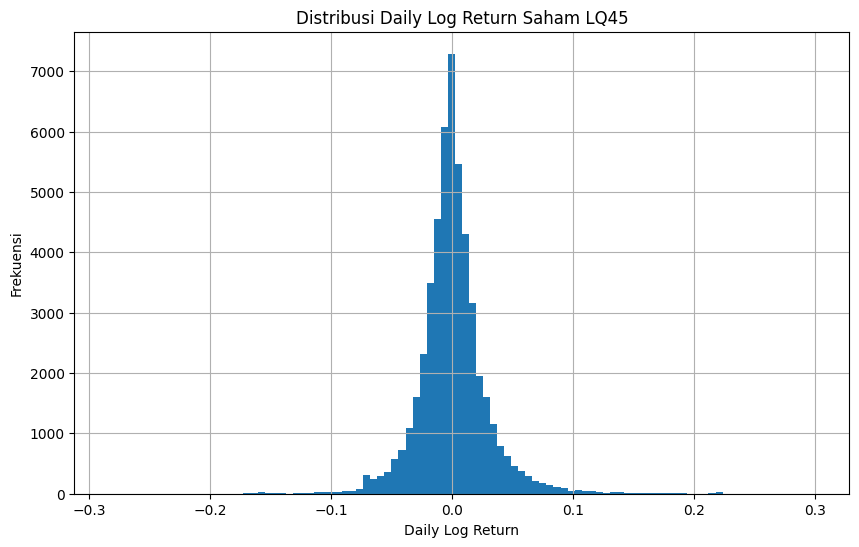

In [ ]:
plot_log_return_distribution(eda_log_return_lq45, "LQ45")

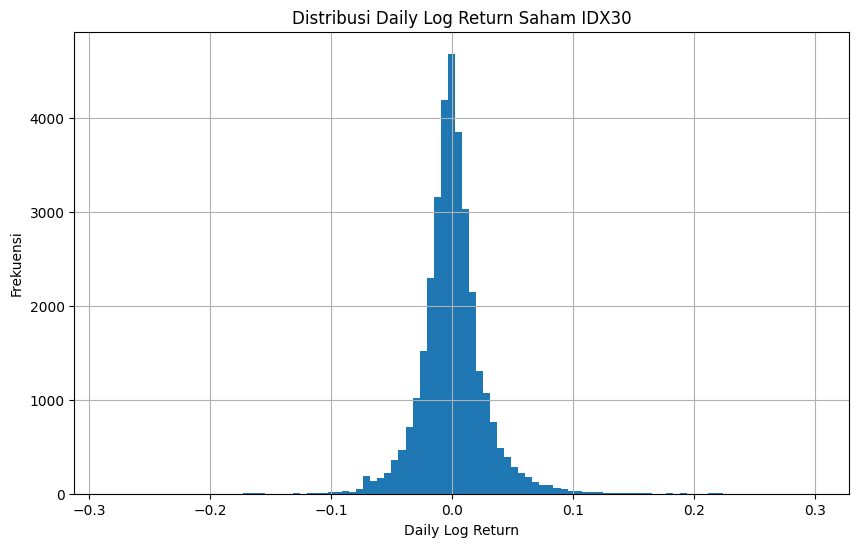

In [ ]:
plot_log_return_distribution(eda_log_return_idx30, "IDX30")

**Insight:**
- Distribusi daily log return pada saham LQ45 dan IDX30 terpusat di sekitar nilai nol, yang menunjukkan sebagian besar perubahan harga harian relatif kecil.
- Bentuk distribusi menyerupai normal namun memiliki ekor yang cukup panjang (fat tails), menandakan adanya kemungkinan return ekstrem baik positif maupun negatif.
- Saham LQ45 terlihat memiliki sebaran return yang sedikit lebih luas dibanding IDX30, yang mengindikasikan volatilitas harian yang relatif lebih tinggi.

### Histogram Annualized Volatility

In [ ]:
# 6.7 HISTOGRAM ANNUALIZED VOLATILITY

def plot_volatility_distribution(eda_summary, index_name):
    plt.figure(figsize=(10, 6))
    eda_summary["annualized_volatility"].hist(bins=30)

    plt.title(f"Distribusi Annualized Volatility Saham {index_name}")
    plt.xlabel("Annualized Volatility")
    plt.ylabel("Jumlah Saham")
    plt.show()

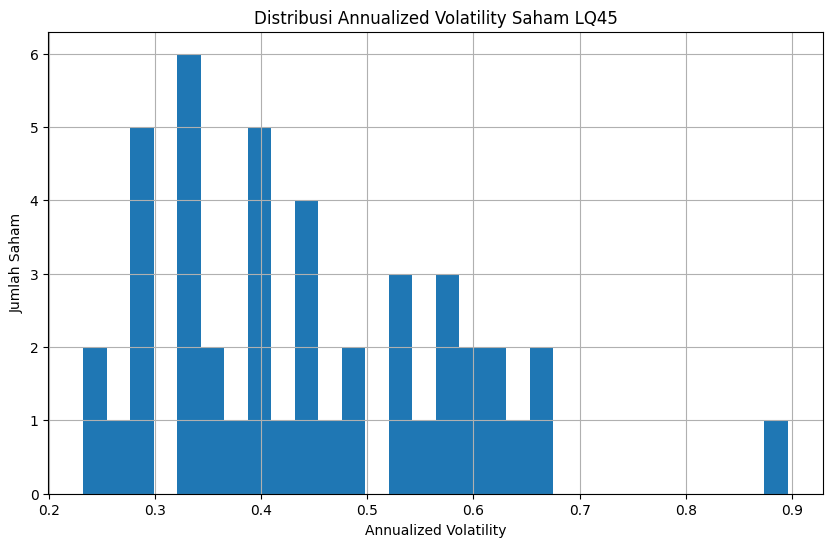

In [ ]:
plot_volatility_distribution(eda_summary_lq45, "LQ45")

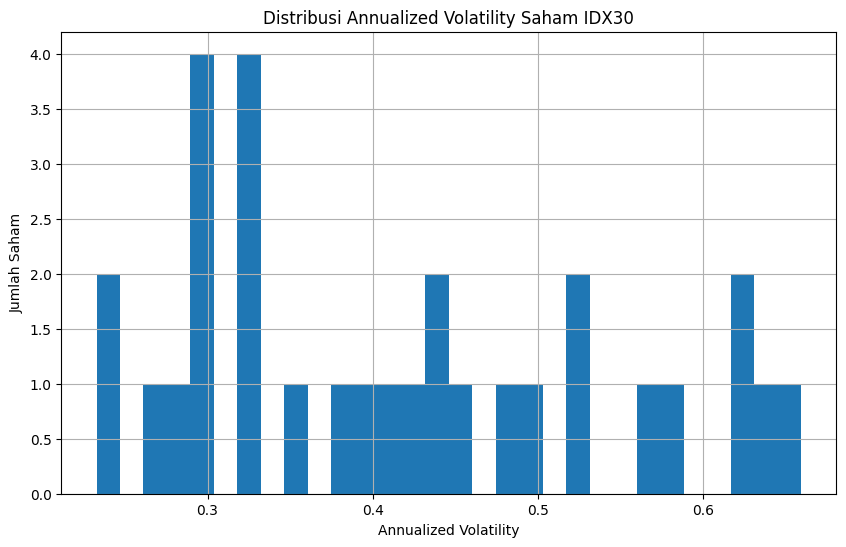

In [ ]:
plot_volatility_distribution(eda_summary_idx30, "IDX30")

**Insight:**
- Sebagian besar saham pada indeks LQ45 dan IDX30 memiliki annualized volatility pada rentang menengah, yang menunjukkan tingkat risiko yang relatif moderat.
- Terdapat beberapa saham dengan volatilitas tinggi, menandakan adanya pergerakan harga yang lebih fluktuatif dan risiko investasi yang lebih besar.
- Distribusi volatilitas pada saham LQ45 terlihat lebih luas dibanding IDX30, sehingga menunjukkan variasi tingkat risiko saham yang lebih beragam.

### Top dan Bottom Return

In [ ]:
# 6.8 TOP DAN BOTTOM RETURN

def get_top_bottom_return(eda_summary, index_name, n=10):
    top_return = eda_summary.sort_values(
        by="annualized_return",
        ascending=False
    ).head(n)

    bottom_return = eda_summary.sort_values(
        by="annualized_return",
        ascending=True
    ).head(n)

    print(f"=== TOP {n} RETURN TERTINGGI {index_name} ===")
    display(top_return)

    print(f"=== TOP {n} RETURN TERENDAH {index_name} ===")
    display(bottom_return)

    return top_return, bottom_return

In [ ]:
top_return_lq45, bottom_return_lq45 = get_top_bottom_return(
    eda_summary_lq45,
    "LQ45"
)

=== TOP 10 RETURN TERTINGGI LQ45 ===


,Ticker,mean_daily_log_return,std_daily_log_return,var_daily_log_return,sum_log_return,annualized_return,annualized_volatility,sharpe_ratio
16,CUAN.JK,0.005077,0.056451,0.003187,3.655481,1.279418,0.896124,1.371929
1,ADMR.JK,0.002704,0.041536,0.001725,2.736116,0.681325,0.659365,0.957475
22,HRTA.JK,0.002142,0.034654,0.001201,2.565571,0.539669,0.550113,0.890125
0,AADI.JK,0.001933,0.033082,0.001094,0.591438,0.487067,0.525165,0.832247
17,DEWA.JK,0.001808,0.038107,0.001452,2.165619,0.455539,0.604929,0.670391
2,ADRO.JK,0.001624,0.027528,0.000758,1.944990,0.409130,0.436993,0.821820
4,AMMN.JK,0.001591,0.036815,0.001355,1.030840,0.400882,0.584426,0.600387
28,ITMG.JK,0.001439,0.021587,0.000466,1.723650,0.362571,0.342680,0.912137
34,MEDC.JK,0.001108,0.031197,0.000973,1.327803,0.279304,0.495243,0.463013
14,BUMI.JK,0.001069,0.040603,0.001649,1.280934,0.269445,0.644558,0.340458


=== TOP 10 RETURN TERENDAH LQ45 ===


,Ticker,mean_daily_log_return,std_daily_log_return,var_daily_log_return,sum_log_return,annualized_return,annualized_volatility,sharpe_ratio
21,GOTO.JK,-0.002131,0.039049,0.001525,-2.013595,-0.536959,0.619880,-0.946890
39,SMGR.JK,-0.001083,0.024679,0.000609,-1.298012,-0.273038,0.391768,-0.824564
18,EMTK.JK,-0.000904,0.035586,0.001266,-1.082533,-0.227712,0.564917,-0.491597
43,UNVR.JK,-0.000903,0.025574,0.000654,-1.081972,-0.227594,0.405978,-0.683766
41,TOWR.JK,-0.000566,0.022099,0.000488,-0.678137,-0.142646,0.350816,-0.549138
15,CPIN.JK,-0.000373,0.020717,0.000429,-0.446393,-0.093899,0.328872,-0.437553
30,KLBF.JK,-0.000306,0.020654,0.000427,-0.366397,-0.077072,0.327872,-0.387566
32,MBMA.JK,-0.000277,0.039668,0.001574,-0.192543,-0.069915,0.629713,-0.190428
23,ICBP.JK,-0.000073,0.016768,0.000281,-0.087098,-0.018321,0.266181,-0.256672
11,BBTN.JK,-0.000045,0.021455,0.000460,-0.053676,-0.011291,0.340593,-0.179953


In [ ]:
top_return_idx30, bottom_return_idx30 = get_top_bottom_return(
    eda_summary_idx30,
    "IDX30"
)

=== TOP 10 RETURN TERTINGGI IDX30 ===


,Ticker,mean_daily_log_return,std_daily_log_return,var_daily_log_return,sum_log_return,annualized_return,annualized_volatility,sharpe_ratio
1,ADMR.JK,0.002704,0.041536,0.001725,2.736116,0.681325,0.659365,0.957475
0,AADI.JK,0.001933,0.033082,0.001094,0.591438,0.487067,0.525165,0.832247
2,ADRO.JK,0.001624,0.027528,0.000758,1.944990,0.409130,0.436993,0.821820
23,MEDC.JK,0.001108,0.031197,0.000973,1.327803,0.279304,0.495243,0.463013
11,BUMI.JK,0.001069,0.040603,0.001649,1.280934,0.269445,0.644558,0.340458
26,PTBA.JK,0.000826,0.020844,0.000434,0.990131,0.208275,0.330890,0.478330
28,UNTR.JK,0.000715,0.021907,0.000480,0.856969,0.180264,0.347756,0.374584
24,PGAS.JK,0.000597,0.020849,0.000435,0.714665,0.150330,0.330965,0.303145
9,BMRI.JK,0.000570,0.018619,0.000347,0.682501,0.143564,0.295565,0.316561
4,ANTM.JK,0.000533,0.027308,0.000746,0.638635,0.134337,0.433497,0.194551


=== TOP 10 RETURN TERENDAH IDX30 ===


,Ticker,mean_daily_log_return,std_daily_log_return,var_daily_log_return,sum_log_return,annualized_return,annualized_volatility,sharpe_ratio
14,GOTO.JK,-0.002131,0.039049,0.001525,-2.013595,-0.536959,0.619880,-0.946890
13,EMTK.JK,-0.000904,0.035586,0.001266,-1.082533,-0.227712,0.564917,-0.491597
29,UNVR.JK,-0.000903,0.025574,0.000654,-1.081972,-0.227594,0.405978,-0.683766
12,CPIN.JK,-0.000373,0.020717,0.000429,-0.446393,-0.093899,0.328872,-0.437553
20,KLBF.JK,-0.000306,0.020654,0.000427,-0.366397,-0.077072,0.327872,-0.387566
21,MBMA.JK,-0.000277,0.039668,0.001574,-0.192543,-0.069915,0.629713,-0.190428
15,ICBP.JK,-0.000073,0.016768,0.000281,-0.087098,-0.018321,0.266181,-0.256672
18,INKP.JK,-0.000010,0.026735,0.000715,-0.011876,-0.002498,0.424403,-0.123699
17,INDF.JK,0.000118,0.014913,0.000222,0.141498,0.029764,0.236742,-0.085476
8,BBRI.JK,0.000120,0.017841,0.000318,0.143735,0.030235,0.283222,-0.069788


### Visualisasi Top Return

In [ ]:
# 6.9 VISUALISASI TOP RETURN

def plot_top_return(top_return, index_name):
    plt.figure(figsize=(10, 6))

    plt.bar(
        top_return["Ticker"],
        top_return["annualized_return"]
    )

    plt.title(f"Top 10 Annualized Return Saham {index_name}")
    plt.xlabel("Ticker")
    plt.ylabel("Annualized Return")
    plt.xticks(rotation=45)
    plt.show()

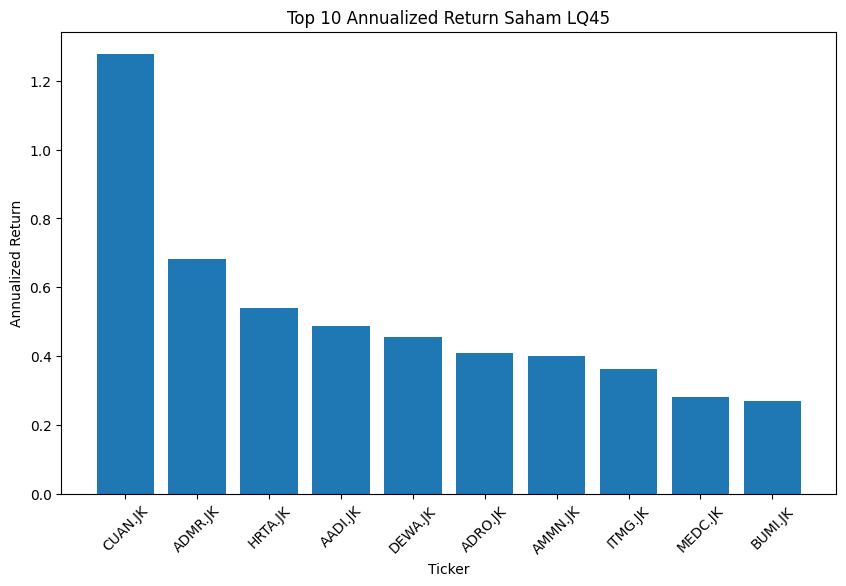

In [ ]:
plot_top_return(top_return_lq45, "LQ45")

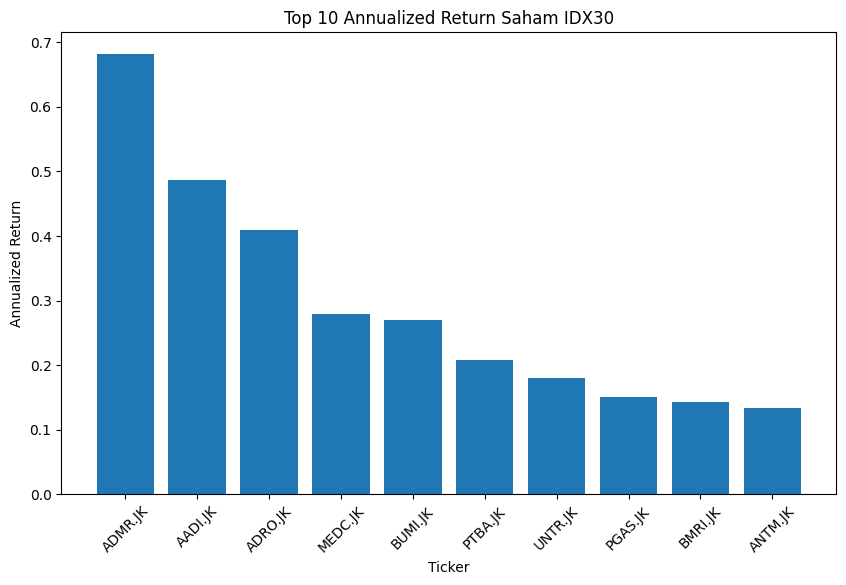

In [ ]:
plot_top_return(top_return_idx30, "IDX30")

**Insight:**
- Saham seperti CUAN.JK, ADMR.JK, dan HRTA.JK memiliki annualized return tertinggi selama periode pengamatan, yang menunjukkan potensi keuntungan investasi yang lebih besar dibanding saham lainnya.
- Beberapa saham dengan return tinggi juga memiliki volatilitas dan risiko yang relatif tinggi, sehingga menunjukkan adanya trade-off antara return dan risiko investasi.
- Saham dengan Sharpe Ratio tinggi, seperti CUAN.JK dan ADMR.JK, menunjukkan performa return yang lebih optimal terhadap risiko, sedangkan saham dengan annualized return negatif seperti GOTO.JK dan EMTK.JK menunjukkan performa yang kurang baik selama periode pengamatan.

### Top dan Bottom Risk

In [ ]:
# 6.10 FUNCTION TOP DAN BOTTOM RISK

def get_top_bottom_risk(eda_summary, index_name, n=10):
    top_risk = eda_summary.sort_values(
        by="annualized_volatility",
        ascending=False
    ).head(n)

    bottom_risk = eda_summary.sort_values(
        by="annualized_volatility",
        ascending=True
    ).head(n)

    print(f"=== TOP {n} RISIKO TERTINGGI {index_name} ===")
    display(top_risk)

    print(f"=== TOP {n} RISIKO TERENDAH {index_name} ===")
    display(bottom_risk)

    return top_risk, bottom_risk

In [ ]:
top_risk_lq45, bottom_risk_lq45 = get_top_bottom_risk(
    eda_summary_lq45,
    "LQ45"
)

=== TOP 10 RISIKO TERTINGGI LQ45 ===


,Ticker,mean_daily_log_return,std_daily_log_return,var_daily_log_return,sum_log_return,annualized_return,annualized_volatility,sharpe_ratio
16,CUAN.JK,0.005077,0.056451,0.003187,3.655481,1.279418,0.896124,1.371929
44,WIFI.JK,0.000935,0.041915,0.001757,1.120088,0.235611,0.665378,0.278956
1,ADMR.JK,0.002704,0.041536,0.001725,2.736116,0.681325,0.659365,0.957475
14,BUMI.JK,0.001069,0.040603,0.001649,1.280934,0.269445,0.644558,0.340458
32,MBMA.JK,-0.000277,0.039668,0.001574,-0.192543,-0.069915,0.629713,-0.190428
21,GOTO.JK,-0.002131,0.039049,0.001525,-2.013595,-0.536959,0.619880,-0.946890
17,DEWA.JK,0.001808,0.038107,0.001452,2.165619,0.455539,0.604929,0.670391
19,ESSA.JK,0.000613,0.037350,0.001395,0.733911,0.154379,0.592916,0.176043
4,AMMN.JK,0.001591,0.036815,0.001355,1.030840,0.400882,0.584426,0.600387
13,BRPT.JK,0.000320,0.036262,0.001315,0.383469,0.080663,0.575643,0.053267


=== TOP 10 RISIKO TERENDAH LQ45 ===


,Ticker,mean_daily_log_return,std_daily_log_return,var_daily_log_return,sum_log_return,annualized_return,annualized_volatility,sharpe_ratio
8,BBCA.JK,0.000170,0.014663,0.000215,0.203931,0.042897,0.232771,-0.030515
25,INDF.JK,0.000118,0.014913,0.000222,0.141498,0.029764,0.236742,-0.085476
23,ICBP.JK,-0.000073,0.016768,0.000281,-0.087098,-0.018321,0.266181,-0.256672
10,BBRI.JK,0.000120,0.017841,0.000318,0.143735,0.030235,0.283222,-0.069788
7,ASII.JK,0.000427,0.018567,0.000345,0.511162,0.107523,0.294734,0.195170
12,BMRI.JK,0.000570,0.018619,0.000347,0.682501,0.143564,0.295565,0.316561
9,BBNI.JK,0.000472,0.018690,0.000349,0.565064,0.118861,0.296690,0.232099
40,TLKM.JK,0.000133,0.018709,0.000350,0.159047,0.033456,0.296998,-0.055705
30,KLBF.JK,-0.000306,0.020654,0.000427,-0.366397,-0.077072,0.327872,-0.387566
15,CPIN.JK,-0.000373,0.020717,0.000429,-0.446393,-0.093899,0.328872,-0.437553


In [ ]:
top_risk_idx30, bottom_risk_idx30 = get_top_bottom_risk(
    eda_summary_idx30,
    "IDX30"
)

=== TOP 10 RISIKO TERTINGGI IDX30 ===


,Ticker,mean_daily_log_return,std_daily_log_return,var_daily_log_return,sum_log_return,annualized_return,annualized_volatility,sharpe_ratio
1,ADMR.JK,0.002704,0.041536,0.001725,2.736116,0.681325,0.659365,0.957475
11,BUMI.JK,0.001069,0.040603,0.001649,1.280934,0.269445,0.644558,0.340458
21,MBMA.JK,-0.000277,0.039668,0.001574,-0.192543,-0.069915,0.629713,-0.190428
14,GOTO.JK,-0.002131,0.039049,0.001525,-2.013595,-0.536959,0.619880,-0.946890
10,BRPT.JK,0.000320,0.036262,0.001315,0.383469,0.080663,0.575643,0.053267
13,EMTK.JK,-0.000904,0.035586,0.001266,-1.082533,-0.227712,0.564917,-0.491597
22,MDKA.JK,0.000303,0.033449,0.001119,0.362448,0.076241,0.530992,0.049419
0,AADI.JK,0.001933,0.033082,0.001094,0.591438,0.487067,0.525165,0.832247
23,MEDC.JK,0.001108,0.031197,0.000973,1.327803,0.279304,0.495243,0.463013
25,PGEO.JK,0.000336,0.030735,0.000945,0.244807,0.084741,0.487910,0.071204


=== TOP 10 RISIKO TERENDAH IDX30 ===


,Ticker,mean_daily_log_return,std_daily_log_return,var_daily_log_return,sum_log_return,annualized_return,annualized_volatility,sharpe_ratio
6,BBCA.JK,0.000170,0.014663,0.000215,0.203931,0.042897,0.232771,-0.030515
17,INDF.JK,0.000118,0.014913,0.000222,0.141498,0.029764,0.236742,-0.085476
15,ICBP.JK,-0.000073,0.016768,0.000281,-0.087098,-0.018321,0.266181,-0.256672
8,BBRI.JK,0.000120,0.017841,0.000318,0.143735,0.030235,0.283222,-0.069788
5,ASII.JK,0.000427,0.018567,0.000345,0.511162,0.107523,0.294734,0.195170
9,BMRI.JK,0.000570,0.018619,0.000347,0.682501,0.143564,0.295565,0.316561
7,BBNI.JK,0.000472,0.018690,0.000349,0.565064,0.118861,0.296690,0.232099
27,TLKM.JK,0.000133,0.018709,0.000350,0.159047,0.033456,0.296998,-0.055705
20,KLBF.JK,-0.000306,0.020654,0.000427,-0.366397,-0.077072,0.327872,-0.387566
12,CPIN.JK,-0.000373,0.020717,0.000429,-0.446393,-0.093899,0.328872,-0.437553


### Visualisasi Top Risk

In [ ]:
# 6.11 VISUALISASI TOP RISK

def plot_top_risk(top_risk, index_name):
    plt.figure(figsize=(10, 6))

    plt.bar(
        top_risk["Ticker"],
        top_risk["annualized_volatility"]
    )

    plt.title(f"Top 10 Annualized Volatility Saham {index_name}")
    plt.xlabel("Ticker")
    plt.ylabel("Annualized Volatility")
    plt.xticks(rotation=45)
    plt.show()

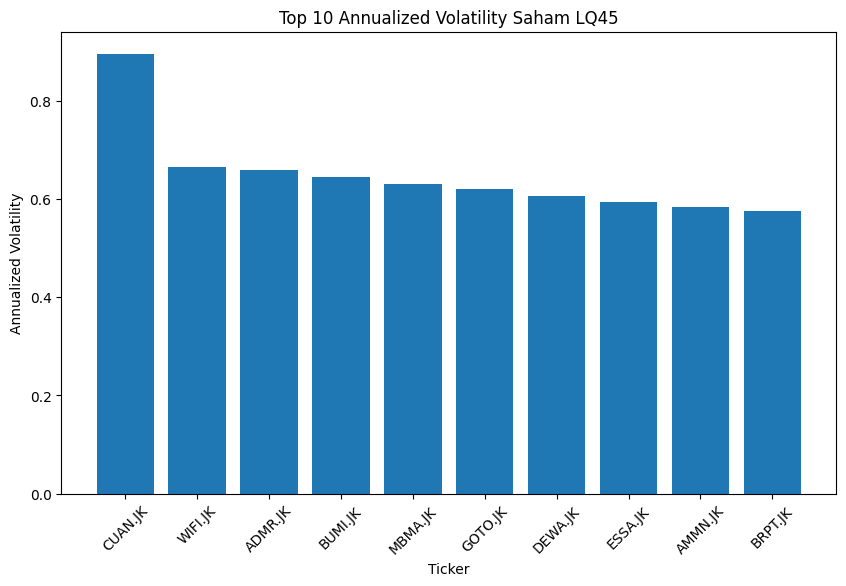

In [ ]:
plot_top_risk(top_risk_lq45, "LQ45")

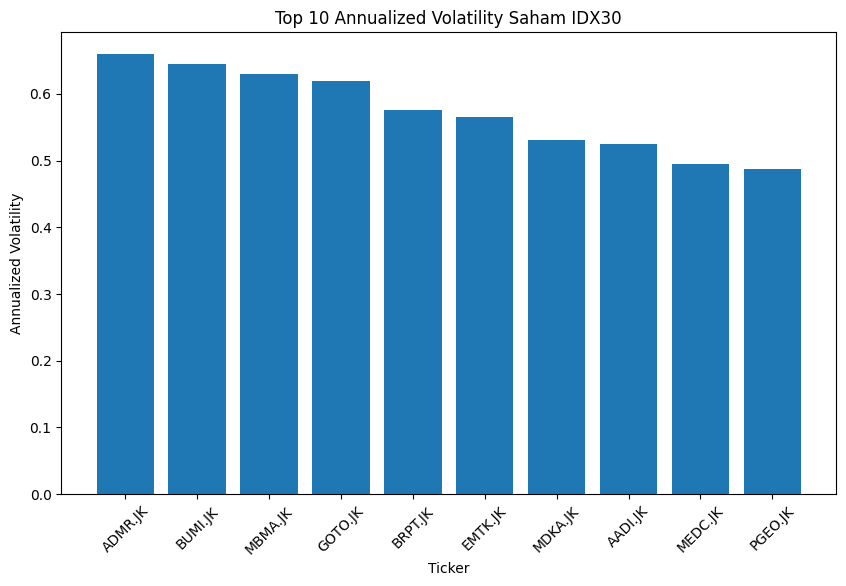

In [ ]:
plot_top_risk(top_risk_idx30, "IDX30")

**Insight :**
- Saham seperti CUAN.JK, WIFI.JK, dan ADMR.JK memiliki annualized volatility tertinggi, yang menunjukkan tingkat fluktuasi harga dan risiko investasi yang lebih besar dibanding saham lainnya.
- Saham dengan volatilitas rendah seperti BBCA.JK dan INDF.JK cenderung memiliki pergerakan harga yang lebih stabil sehingga lebih cocok untuk profil risiko konservatif.
- Tingkat risiko yang tinggi tidak selalu diikuti return yang baik, sehingga investor perlu mempertimbangkan keseimbangan antara return dan risiko dalam pembentukan portofolio.



### Correlation Heatmap

In [ ]:
# 6.12 CORRELATION HEATMAP

def plot_correlation_heatmap(eda_log_return, index_name):
    corr_matrix = eda_log_return.corr()

    plt.figure(figsize=(14, 10))

    sns.heatmap(
        corr_matrix,
        cmap="coolwarm",
        center=0
    )

    plt.title(f"Correlation Heatmap Saham {index_name}")
    plt.show()

    return corr_matrix

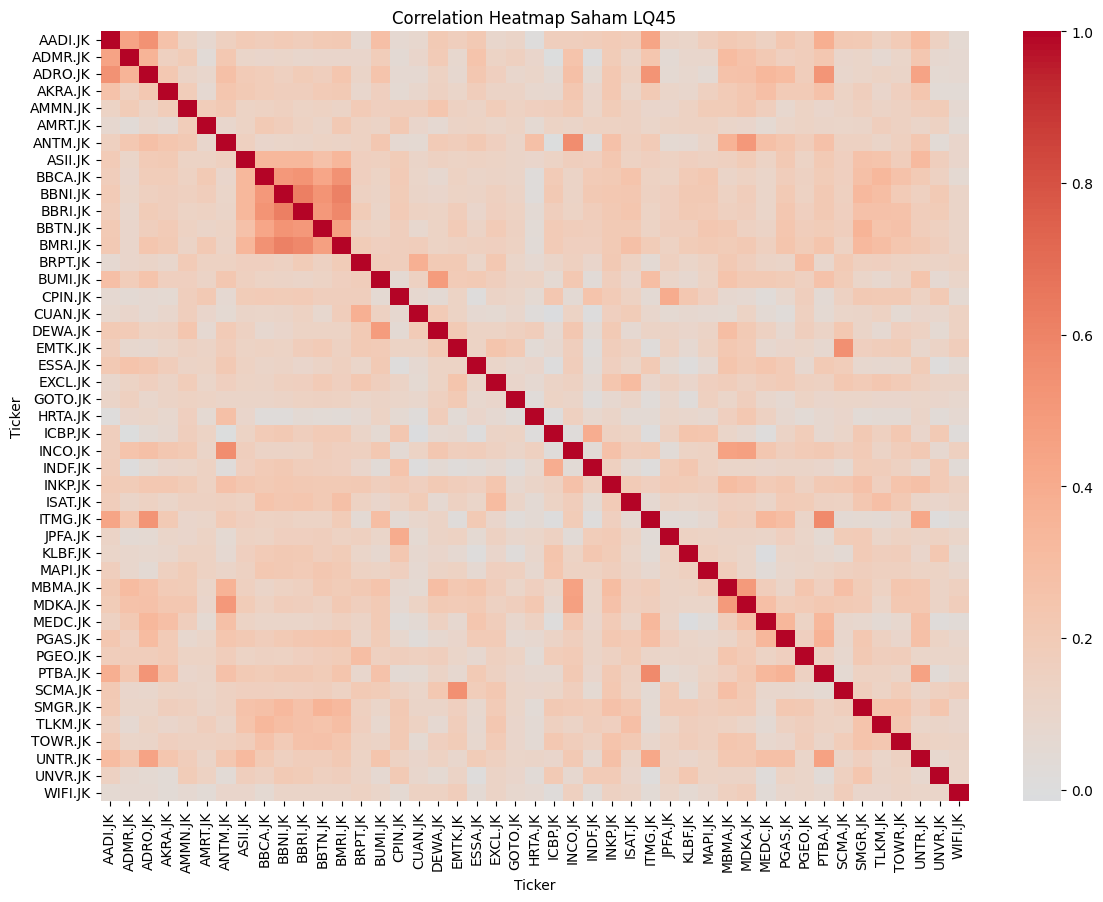

In [ ]:
corr_matrix_lq45 = plot_correlation_heatmap(
    eda_log_return_lq45,
    "LQ45"
)

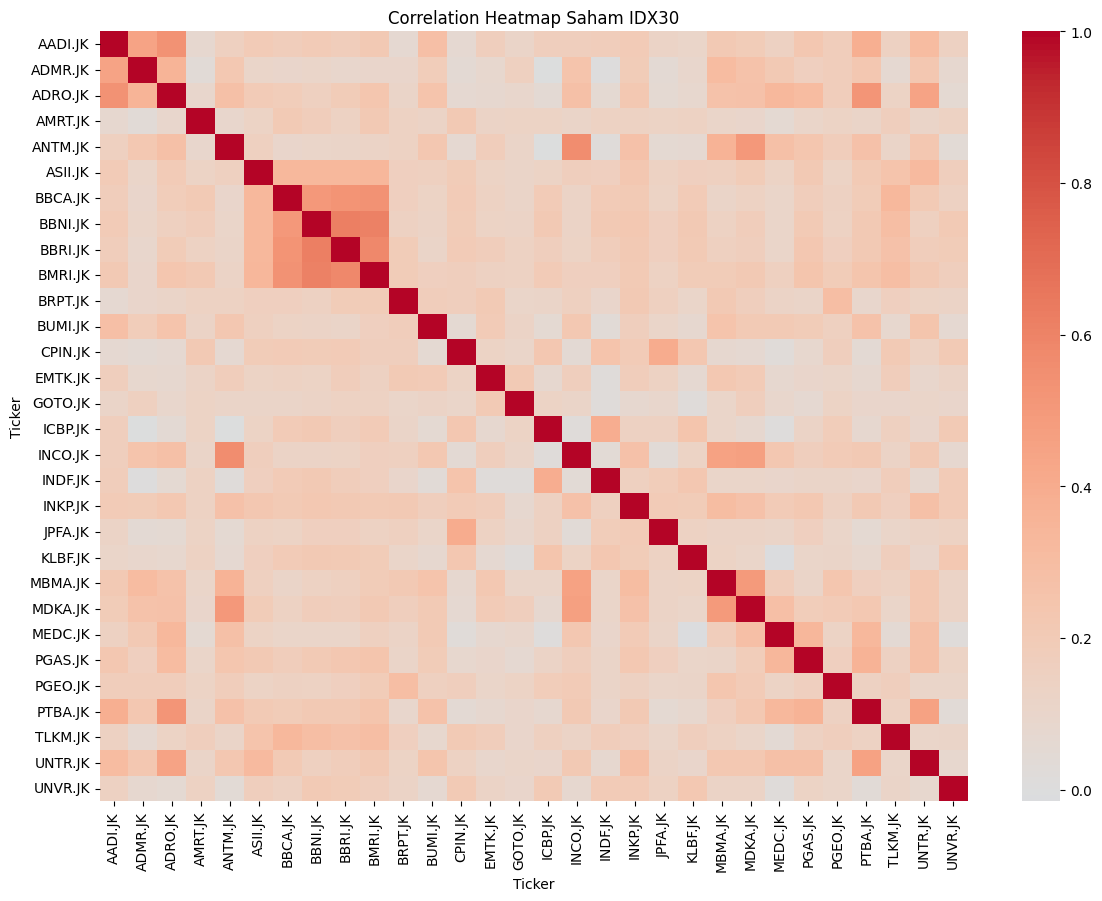

In [ ]:
corr_matrix_idx30 = plot_correlation_heatmap(
    eda_log_return_idx30,
    "IDX30"
)

**Insight:**
- Sebagian besar saham pada indeks LQ45 dan IDX30 menunjukkan korelasi positif dengan tingkat yang bervariasi, yang menandakan adanya kecenderungan pergerakan harga saham yang searah.
- Beberapa kelompok saham, terutama pada sektor perbankan, terlihat memiliki korelasi yang lebih tinggi dibanding saham lainnya karena dipengaruhi faktor pasar dan sektor yang serupa.
- Korelasi yang tidak terlalu tinggi antar sebagian besar saham menunjukkan adanya potensi diversifikasi dalam pembentukan portofolio untuk mengurangi risiko investasi.



### Risk VS Return Scatter Plot

In [ ]:
# 6.13 RISK VS RETURN SCATTER PLOT

def plot_risk_return_scatter(eda_summary, index_name):
    plt.figure(figsize=(12, 8))

    plt.scatter(
        eda_summary["annualized_volatility"],
        eda_summary["annualized_return"]
    )

    for i in range(len(eda_summary)):
        plt.text(
            eda_summary["annualized_volatility"].iloc[i],
            eda_summary["annualized_return"].iloc[i],
            eda_summary["Ticker"].iloc[i],
            fontsize=8
        )

    plt.xlabel("Annualized Volatility")
    plt.ylabel("Annualized Return")
    plt.title(f"Risk vs Return Saham {index_name}")
    plt.show()

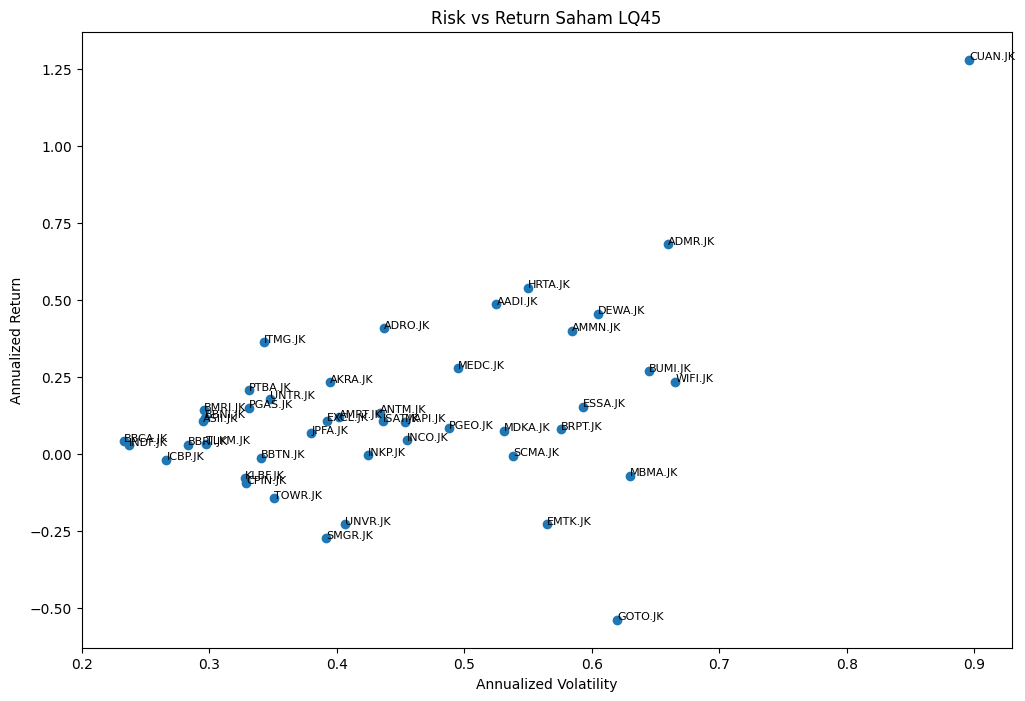

In [ ]:
plot_risk_return_scatter(eda_summary_lq45, "LQ45")

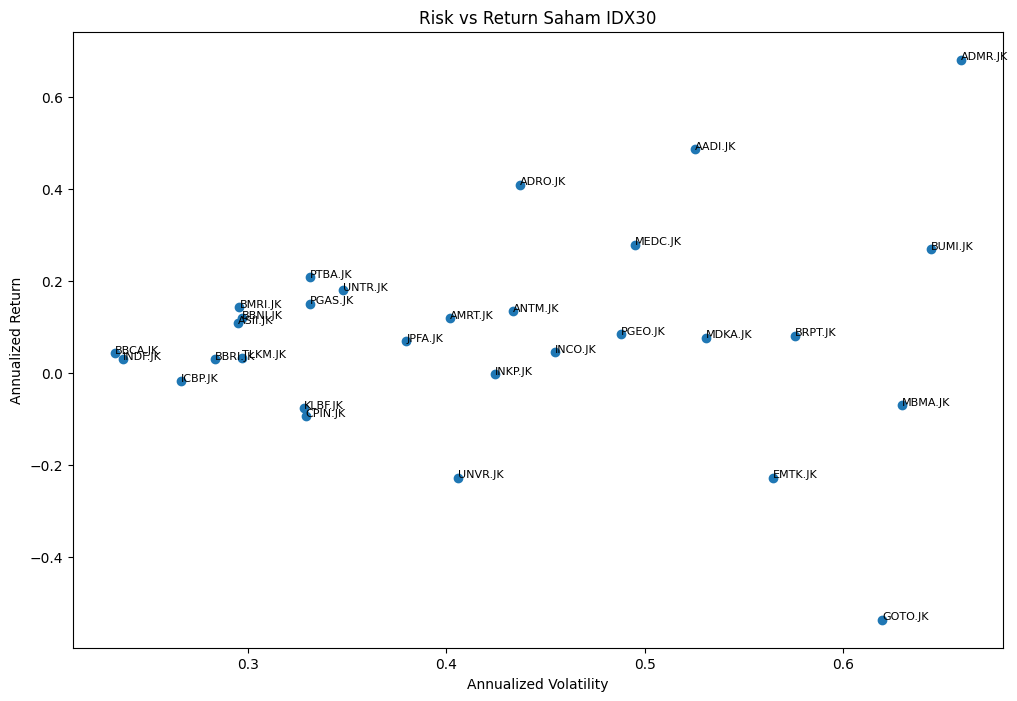

In [ ]:
plot_risk_return_scatter(eda_summary_idx30, "IDX30")

**Insight:**
- Secara umum terlihat adanya hubungan positif antara risiko dan return, di mana saham dengan annualized volatility lebih tinggi cenderung memiliki annualized return yang lebih besar.
- Saham seperti CUAN.JK dan ADMR.JK berada pada area high risk-high return, sedangkan saham seperti BBCA.JK dan INDF.JK cenderung berada pada area risiko yang lebih rendah dengan return yang lebih stabil.
- Beberapa saham seperti GOTO.JK dan EMTK.JK memiliki risiko tinggi namun return negatif, sehingga menunjukkan performa investasi yang kurang optimal selama periode pengamatan.

### Sharpe Ratio Ranking

In [ ]:
# 6.14 SHARPE RATIO RANKING

def get_top_sharpe_ratio(eda_summary, index_name, n=10):
    top_sharpe = eda_summary.sort_values(
        by="sharpe_ratio",
        ascending=False
    ).head(n)

    print(f"=== TOP {n} SHARPE RATIO {index_name} ===")
    display(top_sharpe)

    return top_sharpe

In [ ]:
top_sharpe_lq45 = get_top_sharpe_ratio(
    eda_summary_lq45,
    "LQ45"
)

=== TOP 10 SHARPE RATIO LQ45 ===


,Ticker,mean_daily_log_return,std_daily_log_return,var_daily_log_return,sum_log_return,annualized_return,annualized_volatility,sharpe_ratio
16,CUAN.JK,0.005077,0.056451,0.003187,3.655481,1.279418,0.896124,1.371929
1,ADMR.JK,0.002704,0.041536,0.001725,2.736116,0.681325,0.659365,0.957475
28,ITMG.JK,0.001439,0.021587,0.000466,1.723650,0.362571,0.342680,0.912137
22,HRTA.JK,0.002142,0.034654,0.001201,2.565571,0.539669,0.550113,0.890125
0,AADI.JK,0.001933,0.033082,0.001094,0.591438,0.487067,0.525165,0.832247
2,ADRO.JK,0.001624,0.027528,0.000758,1.944990,0.409130,0.436993,0.821820
17,DEWA.JK,0.001808,0.038107,0.001452,2.165619,0.455539,0.604929,0.670391
4,AMMN.JK,0.001591,0.036815,0.001355,1.030840,0.400882,0.584426,0.600387
37,PTBA.JK,0.000826,0.020844,0.000434,0.990131,0.208275,0.330890,0.478330
3,AKRA.JK,0.000925,0.024844,0.000617,1.108572,0.233189,0.394384,0.464493


In [ ]:
top_sharpe_idx30 = get_top_sharpe_ratio(
    eda_summary_idx30,
    "IDX30"
)

=== TOP 10 SHARPE RATIO IDX30 ===


,Ticker,mean_daily_log_return,std_daily_log_return,var_daily_log_return,sum_log_return,annualized_return,annualized_volatility,sharpe_ratio
1,ADMR.JK,0.002704,0.041536,0.001725,2.736116,0.681325,0.659365,0.957475
0,AADI.JK,0.001933,0.033082,0.001094,0.591438,0.487067,0.525165,0.832247
2,ADRO.JK,0.001624,0.027528,0.000758,1.944990,0.409130,0.436993,0.821820
26,PTBA.JK,0.000826,0.020844,0.000434,0.990131,0.208275,0.330890,0.478330
23,MEDC.JK,0.001108,0.031197,0.000973,1.327803,0.279304,0.495243,0.463013
28,UNTR.JK,0.000715,0.021907,0.000480,0.856969,0.180264,0.347756,0.374584
11,BUMI.JK,0.001069,0.040603,0.001649,1.280934,0.269445,0.644558,0.340458
9,BMRI.JK,0.000570,0.018619,0.000347,0.682501,0.143564,0.295565,0.316561
24,PGAS.JK,0.000597,0.020849,0.000435,0.714665,0.150330,0.330965,0.303145
7,BBNI.JK,0.000472,0.018690,0.000349,0.565064,0.118861,0.296690,0.232099


Insight :
- Saham seperti CUAN.JK, ADMR.JK, dan ITMG.JK memiliki Sharpe Ratio tertinggi, yang menunjukkan performa return terhadap risiko yang lebih optimal dibanding saham lainnya.
- Sharpe Ratio yang tinggi mengindikasikan bahwa saham mampu memberikan return yang relatif baik untuk setiap tingkat risiko yang diambil.
- Saham dengan Sharpe Ratio rendah atau negatif cenderung memiliki performa investasi yang kurang efisien karena return yang dihasilkan tidak sebanding dengan tingkat risikonya.

### Cumulative Return

In [ ]:
# 6.15 CUMULATIVE RETURN

def plot_cumulative_return(eda_log_return, top_return, index_name):
    cumulative_return = (
        1 + eda_log_return.fillna(0)
    ).cumprod()

    top_5_tickers = top_return["Ticker"].head(5)

    plt.figure(figsize=(14, 7))

    for ticker in top_5_tickers:
        plt.plot(
            cumulative_return.index,
            cumulative_return[ticker],
            label=ticker
        )

    plt.legend()
    plt.title(f"Cumulative Return Top 5 Saham {index_name}")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.show()

    return cumulative_return

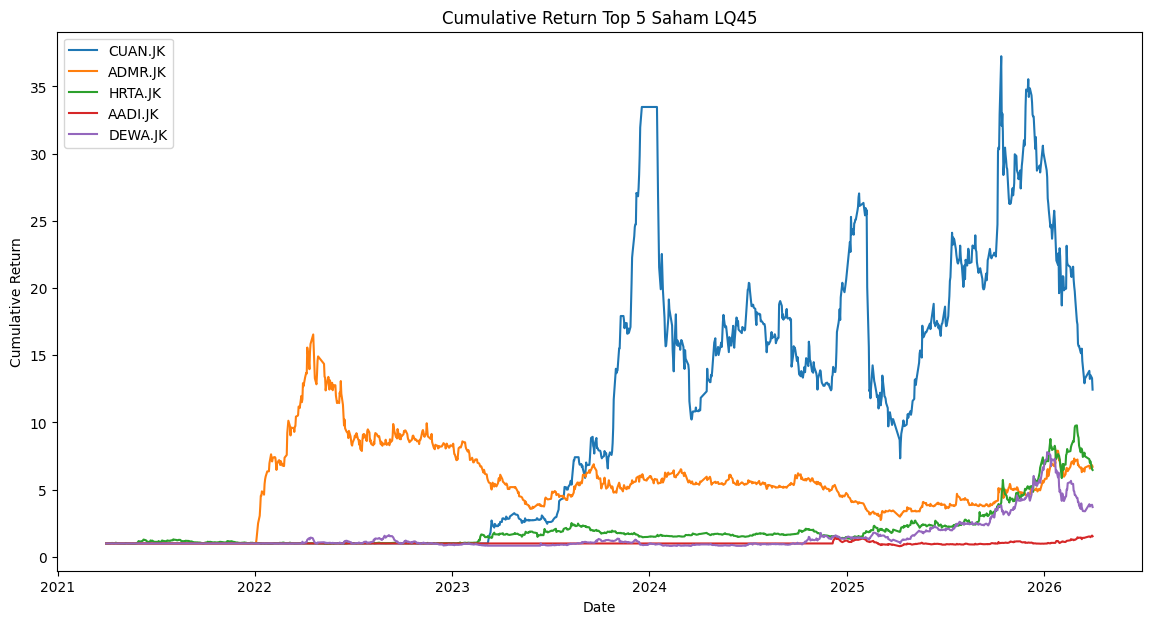

In [ ]:
cumulative_return_lq45 = plot_cumulative_return(
    eda_log_return_lq45,
    top_return_lq45,
    "LQ45"
)

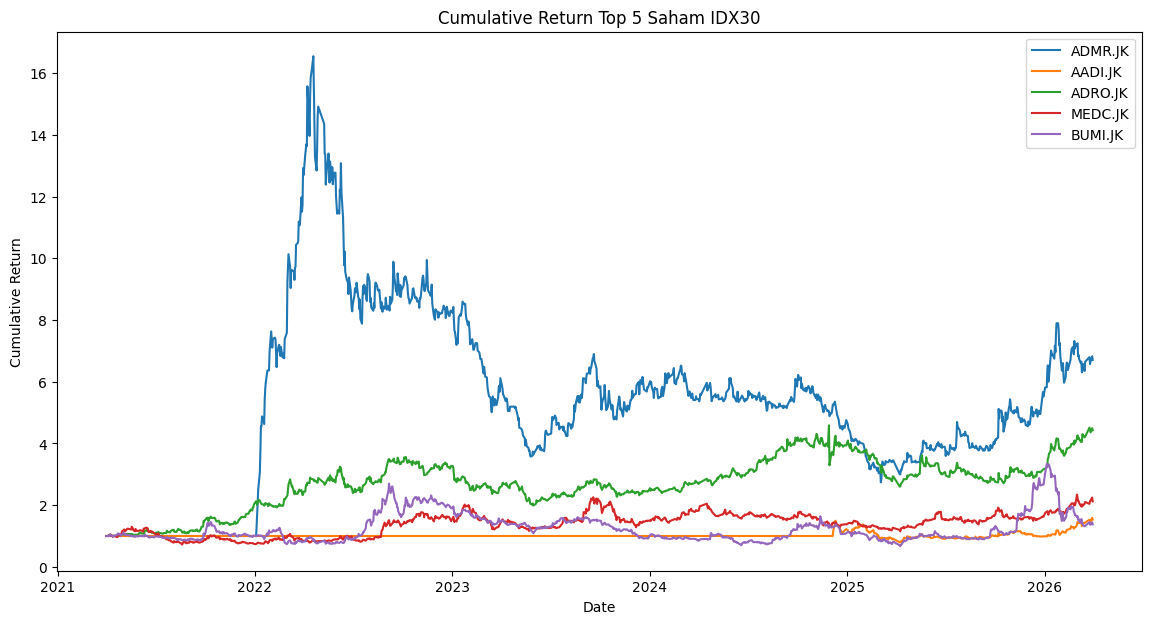

In [ ]:
cumulative_return_idx30 = plot_cumulative_return(
    eda_log_return_idx30,
    top_return_idx30,
    "IDX30"
)

**Insight :**
- Cumulative return menunjukkan bahwa saham dengan return tertinggi mengalami pertumbuhan nilai investasi yang jauh lebih besar dibanding saham lainnya selama periode pengamatan.
- Pada LQ45, CUAN.JK menunjukkan kenaikan cumulative return paling dominan, sedangkan pada IDX30 ADMR.JK menjadi saham dengan pertumbuhan paling menonjol.
- Pergerakan cumulative return yang naik-turun tajam menunjukkan bahwa saham dengan potensi return tinggi juga memiliki fluktuasi harga yang besar, sehingga tetap perlu mempertimbangkan risiko.

### Rolling Volatility

In [ ]:
# 6.16 ROLLING VOLATILITY

def plot_rolling_volatility(eda_log_return, top_return, index_name, trading_days=252):
    rolling_volatility = (
        eda_log_return.rolling(window=30).std()
        * np.sqrt(trading_days)
    )

    top_5_tickers = top_return["Ticker"].head(5)

    plt.figure(figsize=(14, 7))

    for ticker in top_5_tickers:
        plt.plot(
            rolling_volatility.index,
            rolling_volatility[ticker],
            label=ticker
        )

    plt.legend()
    plt.title(f"30-Day Rolling Volatility Top 5 Saham {index_name}")
    plt.xlabel("Date")
    plt.ylabel("Annualized Volatility")
    plt.show()

    return rolling_volatility

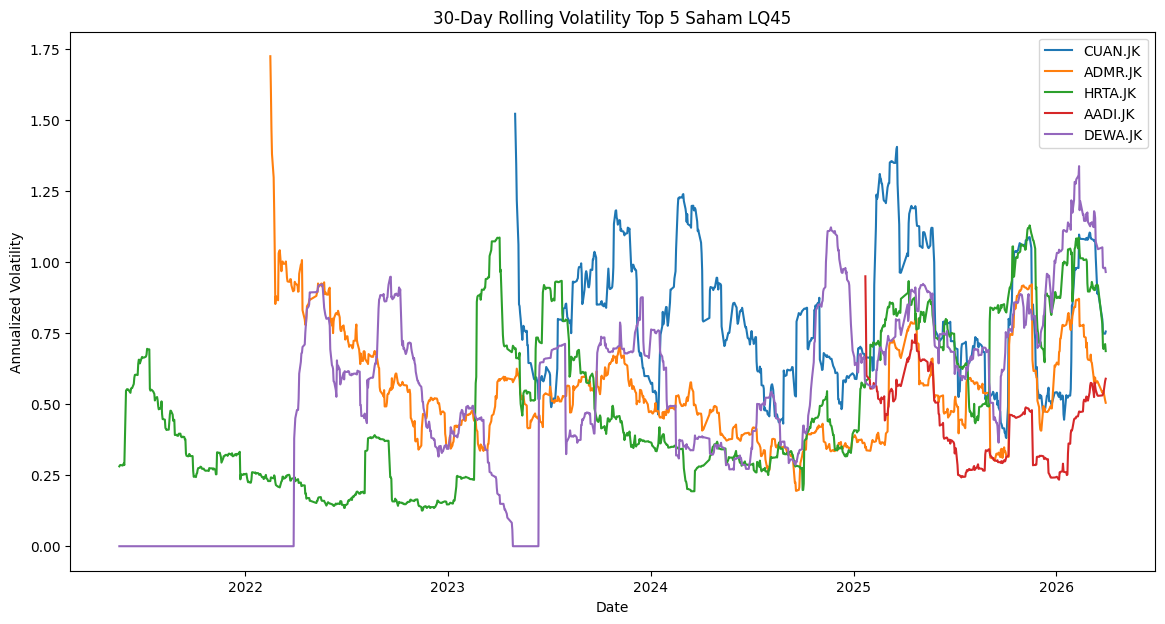

In [ ]:
rolling_volatility_lq45 = plot_rolling_volatility(
    eda_log_return_lq45,
    top_return_lq45,
    "LQ45"
)

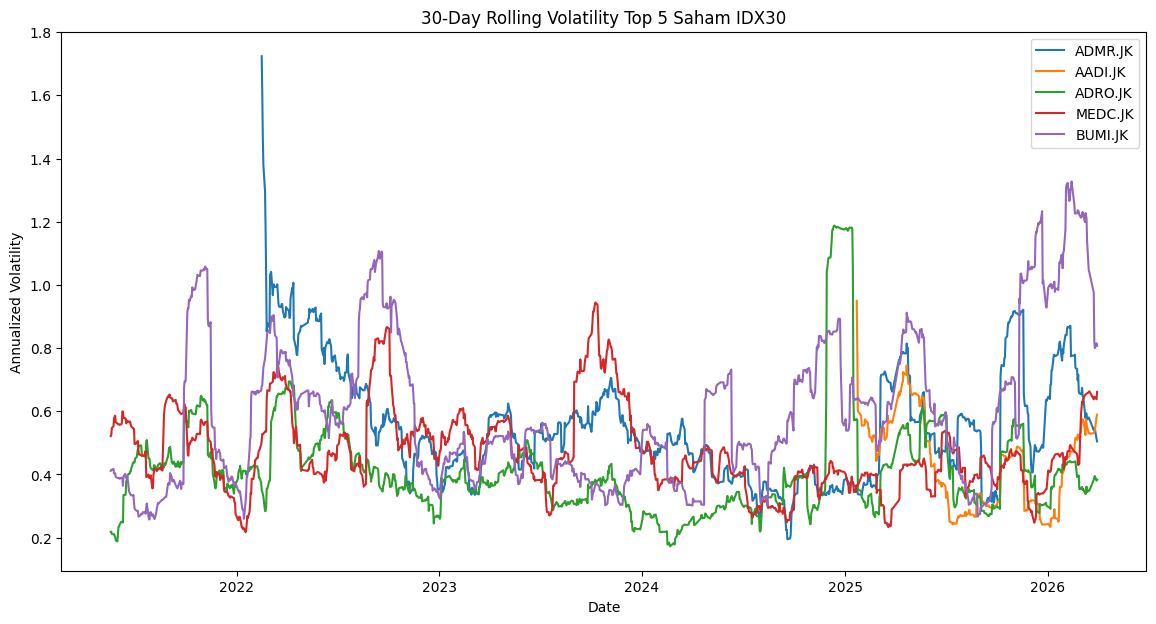

In [ ]:
rolling_volatility_idx30 = plot_rolling_volatility(
    eda_log_return_idx30,
    top_return_idx30,
    "IDX30"
)

**Insight :**
- Rolling volatility menunjukkan bahwa tingkat risiko saham berubah secara dinamis dari waktu ke waktu dan tidak bersifat konstan.
- Beberapa saham seperti CUAN.JK, ADMR.JK, dan BUMI.JK mengalami lonjakan volatilitas yang cukup tinggi pada periode tertentu, menandakan adanya peningkatan fluktuasi harga pasar.
- Saham dengan volatilitas yang lebih stabil cenderung memiliki pergerakan risiko yang lebih konsisten, sehingga dapat lebih sesuai untuk investor dengan profil risiko moderat hingga konservatif.



## 7. Portofolio Modeling - Mean Variance Efficient Portfolio (MVEP)

### Ambil 10 pasangan saham dengan korelasi terendah

In [ ]:
# 7.1 Ambil 10 pasangan saham dengan korelasi terendah
corr_matrix_mvep = correlation_matrix.copy()

corr_matrix_mvep.index.name = None
corr_matrix_mvep.columns.name = None

corr_pairs_mvep = corr_matrix_mvep.stack().reset_index()
corr_pairs_mvep.columns = ["Ticker_1", "Ticker_2", "Correlation"]

# Hilangkan korelasi diri sendiri
corr_pairs_mvep = corr_pairs_mvep[
    corr_pairs_mvep["Ticker_1"] != corr_pairs_mvep["Ticker_2"]
]

# Hilangkan duplikasi pasangan A-B dan B-A
corr_pairs_mvep["pair"] = corr_pairs_mvep.apply(
    lambda x: tuple(sorted([x["Ticker_1"], x["Ticker_2"]])),
    axis=1
)

corr_pairs_mvep = corr_pairs_mvep.drop_duplicates("pair").drop(columns="pair")

top_low_corr_pairs_mvep = corr_pairs_mvep.sort_values(
    by="Correlation",
    ascending=True
).head(10)

print("=== TOP 10 PASANGAN SAHAM DENGAN KORELASI TERENDAH UNTUK MVEP ===")
display(top_low_corr_pairs_mvep)

=== TOP 10 PASANGAN SAHAM DENGAN KORELASI TERENDAH UNTUK MVEP ===


,Ticker_1,Ticker_2,Correlation
423,INDF.JK,ITMG.JK,-0.089020
15,ADMR.JK,INDF.JK,-0.067577
399,ICBP.JK,MEDC.JK,-0.055057
102,AMRT.JK,MEDC.JK,-0.052023
258,BUMI.JK,INDF.JK,-0.041574
396,ICBP.JK,ITMG.JK,-0.041198
312,DEWA.JK,INDF.JK,-0.036663
290,CUAN.JK,MAPI.JK,-0.036596
505,ITMG.JK,JPFA.JK,-0.036078
403,ICBP.JK,UNTR.JK,-0.031058


### Ambil unique ticker dari 10 pasangan korelasi terendah

In [ ]:
# 7.2 Ambil unique ticker dari 10 pasangan korelasi terendah

selected_tickers_mvep = sorted(
    list(
        set(top_low_corr_pairs_mvep["Ticker_1"])
        .union(set(top_low_corr_pairs_mvep["Ticker_2"]))
    )
)

print("=== SAHAM TERPILIH UNTUK MVEP ===")
print(selected_tickers_mvep)
print("Jumlah saham:", len(selected_tickers_mvep))

=== SAHAM TERPILIH UNTUK MVEP ===
['ADMR.JK', 'AMRT.JK', 'BUMI.JK', 'CUAN.JK', 'DEWA.JK', 'ICBP.JK', 'INDF.JK', 'ITMG.JK', 'JPFA.JK', 'MAPI.JK', 'MEDC.JK', 'UNTR.JK']
Jumlah saham: 12


### Ambil subset covariance matrix dari hasil feature engineering

In [ ]:
# 7.3 Ambil subset covariance matrix dari hasil feature engineering

mvep_covariance_matrix = covariance_matrix.loc[
    selected_tickers_mvep,
    selected_tickers_mvep
]

print("=== SUBSET COVARIANCE MATRIX UNTUK MVEP ===")
print(mvep_covariance_matrix.shape)
display(mvep_covariance_matrix)

=== SUBSET COVARIANCE MATRIX UNTUK MVEP ===
(12, 12)


Ticker,ADMR.JK,AMRT.JK,BUMI.JK,CUAN.JK,DEWA.JK,ICBP.JK,INDF.JK,ITMG.JK,JPFA.JK,MAPI.JK,MEDC.JK,UNTR.JK
Ticker,,,,,,,,,,,,
ADMR.JK,0.000943,0.000002,0.000165,0.000078,0.000094,0.000007,-0.000024,0.000102,-0.000003,-0.000008,0.000173,0.000101
AMRT.JK,0.000002,0.000272,0.000036,0.000026,0.000022,0.000056,0.000038,0.000011,0.000018,0.000055,-0.000027,0.000003
BUMI.JK,0.000165,0.000036,0.000855,0.000019,0.000331,0.000028,-0.000014,0.000163,-0.000016,0.000065,0.000194,0.000132
CUAN.JK,0.000078,0.000026,0.000019,0.003076,0.000119,-0.000024,-0.000019,0.000059,0.000072,-0.000054,0.000025,0.000042
DEWA.JK,0.000094,0.000022,0.000331,0.000119,0.000990,0.000019,-0.000013,0.000096,0.000018,0.000039,0.000116,0.000071
ICBP.JK,0.000007,0.000056,0.000028,-0.000024,0.000019,0.000313,0.000075,-0.000011,0.000027,0.000087,-0.000031,-0.000009
INDF.JK,-0.000024,0.000038,-0.000014,-0.000019,-0.000013,0.000075,0.000131,-0.000015,0.000030,0.000059,0.000019,0.000015
ITMG.JK,0.000102,0.000011,0.000163,0.000059,0.000096,-0.000011,-0.000015,0.000224,-0.000011,0.000048,0.000172,0.000126
JPFA.JK,-0.000003,0.000018,-0.000016,0.000072,0.000018,0.000027,0.000030,-0.000011,0.000438,0.000050,-0.000003,0.000038


### Inverse covariance matrix

In [ ]:
# 7.4 Inverse covariance matrix

cov_matrix_np = mvep_covariance_matrix.values

try:
    inverse_covariance_matrix = np.linalg.inv(cov_matrix_np)
    print("Inverse covariance matrix berhasil dihitung dengan np.linalg.inv")
except np.linalg.LinAlgError:
    inverse_covariance_matrix = np.linalg.pinv(cov_matrix_np)
    print("Covariance matrix singular, digunakan np.linalg.pinv")

inverse_covariance_matrix_df = pd.DataFrame(
    inverse_covariance_matrix,
    index=selected_tickers_mvep,
    columns=selected_tickers_mvep
)

print("=== INVERSE COVARIANCE MATRIX UNTUK MVEP ===")
display(inverse_covariance_matrix_df)

Inverse covariance matrix berhasil dihitung dengan np.linalg.inv
=== INVERSE COVARIANCE MATRIX UNTUK MVEP ===


,ADMR.JK,AMRT.JK,BUMI.JK,CUAN.JK,DEWA.JK,ICBP.JK,INDF.JK,ITMG.JK,JPFA.JK,MAPI.JK,MEDC.JK,UNTR.JK
ADMR.JK,1159.442732,-11.514084,-108.778926,-18.143308,-17.037671,-115.968030,253.604427,-219.361897,7.299678,55.371164,-107.635923,-239.589650
AMRT.JK,-11.514084,3990.975893,-146.302932,-38.601041,-28.639699,-411.463673,-957.205327,-358.507003,-77.425294,-164.523777,188.943646,163.749072
BUMI.JK,-108.778926,-146.302932,1557.824747,24.617127,-409.208197,-172.289448,215.272946,-663.702352,84.534075,-42.391288,-80.809133,-287.397636
CUAN.JK,-18.143308,-38.601041,24.617127,331.179969,-37.397203,17.946829,34.463497,-85.583808,-59.074708,32.961046,7.676814,-10.006445
DEWA.JK,-17.037671,-28.639699,-409.208197,-37.397203,1177.195269,-56.554913,112.716413,-161.911857,-62.833111,-12.990763,-29.264349,0.790942
ICBP.JK,-115.968030,-411.463673,-172.289448,17.946829,-56.554913,3894.000143,-2049.821813,7.881195,-87.011891,-291.816150,158.960868,351.491163
INDF.JK,253.604427,-957.205327,215.272946,34.463497,112.716413,-2049.821813,9776.902851,1265.204325,-323.223494,-479.779542,-358.105188,-1104.789062
ITMG.JK,-219.361897,-358.507003,-663.702352,-85.583808,-161.911857,7.881195,1265.204325,7328.536389,387.958301,-323.319454,-573.643685,-2787.947504
JPFA.JK,7.299678,-77.425294,84.534075,-59.074708,-62.833111,-87.011891,-323.223494,387.958301,2401.372942,-132.209562,41.404708,-561.244137
MAPI.JK,55.371164,-164.523777,-42.391288,32.961046,-12.990763,-291.816150,-479.779542,-323.319454,-132.209562,1564.423903,-38.296196,-46.015785


### Hitung Bobot dan Ringkasan Portofolio MVEP

In [ ]:
# 7.5 Hitung Bobot dan Ringkasan Portofolio MVEP

ones = np.ones(len(selected_tickers_mvep))

# Rumus MVEP:
# w = (Σ^-1 * 1) / (1^T * Σ^-1 * 1)

mvep_weights = inverse_covariance_matrix @ ones / (
    ones.T @ inverse_covariance_matrix @ ones
)

mvep_weights_series = pd.Series(
    mvep_weights,
    index=selected_tickers_mvep,
    name="weight"
)

# Buat summary bobot
mvep_weights_summary = pd.DataFrame({
    "Ticker": mvep_weights_series.index,
    "weight": mvep_weights_series.values
})

print("=== BOBOT PORTOFOLIO MVEP ===")
display(mvep_weights_summary)

print("Total bobot:", mvep_weights_series.sum())

=== BOBOT PORTOFOLIO MVEP ===


,Ticker,weight
0,ADMR.JK,0.036174
1,AMRT.JK,0.121933
2,BUMI.JK,-0.001624
3,CUAN.JK,0.011348
4,DEWA.JK,0.026938
5,ICBP.JK,0.070645
6,INDF.JK,0.362213
7,ITMG.JK,0.216446
8,JPFA.JK,0.091872
9,MAPI.JK,0.006887


Total bobot: 1.0


### Hitung Performa Portofolio MVEP


In [ ]:
# 7.6 Hitung Performa Portofolio MVEP

mvep_return_matrix = log_return_matrix[selected_tickers_mvep]

mvep_portfolio_daily_return = mvep_return_matrix @ mvep_weights_series

mvep_portfolio_annual_return = mvep_portfolio_daily_return.mean() * trading_days

mvep_portfolio_annual_volatility = (
    mvep_portfolio_daily_return.std() * np.sqrt(trading_days)
)

mvep_portfolio_sharpe = (
    mvep_portfolio_annual_return - risk_free_rate_annual
) / mvep_portfolio_annual_volatility

print("=== PERFORMA PORTOFOLIO MVEP ===")
print("Annualized Return:", mvep_portfolio_annual_return)
print("Annualized Volatility:", mvep_portfolio_annual_volatility)
print("Sharpe Ratio:", mvep_portfolio_sharpe)

=== PERFORMA PORTOFOLIO MVEP ===
Annualized Return: 0.1559520975227233
Annualized Volatility: 0.11956221973362273
Sharpe Ratio: 0.8013631184992477


### Menyimpan Hasil MVEP

In [ ]:
# 7.7 Simpan Hasil MVEP

mvep_covariance_matrix.to_csv("mvep_covariance_matrix.csv")
inverse_covariance_matrix_df.to_csv("mvep_inverse_covariance_matrix.csv")

mvep_weights_summary.to_csv(
    "mvep_optimal_portfolio_weights.csv",
    index=False
)

pd.DataFrame({
    "metric": [
        "annualized_return",
        "annualized_volatility",
        "sharpe_ratio",
        "selected_stock_count",
        "total_weight"
    ],
    "value": [
        mvep_portfolio_annual_return,
        mvep_portfolio_annual_volatility,
        mvep_portfolio_sharpe,
        len(selected_tickers_mvep),
        mvep_weights_series.sum()
    ]
}).to_csv("mvep_portfolio_performance.csv", index=False)

print("✅ Hasil MVEP berhasil disimpan:")
print("- mvep_covariance_matrix.csv")
print("- mvep_inverse_covariance_matrix.csv")
print("- mvep_optimal_portfolio_weights.csv")
print("- mvep_portfolio_performance.csv")

✅ Hasil MVEP berhasil disimpan:
- mvep_covariance_matrix.csv
- mvep_inverse_covariance_matrix.csv
- mvep_optimal_portfolio_weights.csv
- mvep_portfolio_performance.csv


**Insight:**
- Pemodelan portofolio MVEP dilakukan menggunakan saham dengan korelasi terendah untuk memaksimalkan efek diversifikasi dan meminimalkan risiko portofolio.
- Berdasarkan hasil korelasi, pasangan saham seperti `INDF.JK - ITMG.JK` dan `ADMR.JK - INDF.JK` memiliki korelasi negatif terendah sehingga berpotensi memberikan diversifikasi yang lebih baik.
- Dari hasil seleksi korelasi terendah, diperoleh 12 saham terpilih yang digunakan dalam pembentukan portofolio MVEP.
- Covariance matrix dan inverse covariance matrix berhasil dihitung dan digunakan untuk menentukan bobot optimal portofolio menggunakan pendekatan Mean Variance Efficient Portfolio.
- Hasil optimasi menunjukkan bahwa saham `INDF.JK` dan `ITMG.JK` memiliki bobot terbesar dalam portofolio, yang mengindikasikan kontribusi penting terhadap performa portofolio optimal.
- Terdapat beberapa saham dengan bobot negatif seperti `BUMI.JK` dan `MEDC.JK`, yang menunjukkan adanya mekanisme short allocation secara matematis dalam optimasi MVEP.
- Portofolio MVEP menghasilkan annualized return sebesar sekitar 15,60% dengan annualized volatility sebesar 11,96%.
- Nilai Sharpe Ratio sebesar 0,80 menunjukkan bahwa portofolio memiliki performa return yang cukup baik dibandingkan tingkat risiko yang ditanggung.
- Seluruh hasil optimasi MVEP berhasil disimpan dalam format CSV untuk mendukung integrasi ke dashboard dan proses analisis selanjutnya.


## 8. Portofolio Modeling - Single Index Model (SIM)

In [ ]:
# 8.1 Siapkan input SIM dari hasil Feature Engineering

sim_return_matrix = log_return_matrix.copy()
sim_market_return = market_log_return.copy()

sim_expected_return = annualized_return.copy()
sim_beta = beta_series.copy()
sim_alpha = alpha_series.copy()

rf = risk_free_rate_annual
market_variance = market_log_return.var()

print("=== INPUT SIM ===")
print("Jumlah saham:", sim_return_matrix.shape[1])
print("Risk-free rate annual:", rf)
print("Market variance daily:", market_variance)

=== INPUT SIM ===
Jumlah saham: 27
Risk-free rate annual: 0.060139344262295086
Market variance daily: 5.1869291836396494e-05


### Hitung residual dan residual variance

In [ ]:
# 8.2 Hitung residual dan residual variance

residual_variance = {}

for ticker in sim_return_matrix.columns:
    predicted_return = sim_alpha[ticker] + sim_beta[ticker] * sim_market_return
    residual = sim_return_matrix[ticker] - predicted_return
    residual_variance[ticker] = residual.var()

residual_variance = pd.Series(residual_variance, name="residual_variance")

print("=== RESIDUAL VARIANCE ===")
display(residual_variance.head())

=== RESIDUAL VARIANCE ===


,residual_variance
ADMR.JK,0.000898
ADRO.JK,0.000346
AKRA.JK,0.000301
AMRT.JK,0.000244
BBCA.JK,0.000109


### Buat tabel awal SIM

In [ ]:
# 8.3 Buat tabel awal SIM

sim_table = pd.DataFrame({
    "expected_return": sim_expected_return,
    "alpha": sim_alpha,
    "beta": sim_beta,
    "residual_variance": residual_variance
})

# Filter agar SIM stabil
sim_table = sim_table.replace([np.inf, -np.inf], np.nan).dropna()

# Beta harus positif dan residual variance tidak boleh nol
sim_table = sim_table[
    (sim_table["beta"] > 0) &
    (sim_table["residual_variance"] > 0)
]

print("=== SIM TABLE AWAL SETELAH FILTER ===")
display(sim_table.head())
print("Jumlah saham valid:", sim_table.shape[0])

=== SIM TABLE AWAL SETELAH FILTER ===


,expected_return,alpha,beta,residual_variance
ADMR.JK,0.452536,0.001440,0.932192,0.000898
ADRO.JK,0.562583,0.001912,0.837921,0.000346
AKRA.JK,0.140519,0.000359,0.520342,0.000301
AMRT.JK,0.173186,0.000406,0.735861,0.000244
BBCA.JK,0.125248,0.000140,0.934774,0.000109


Jumlah saham valid: 27


### Menghitung ERB

In [ ]:
# 8.4 Menghitung ERB

# ERB = (E(ri) - rf) / beta_i

sim_table["ERB"] = (
    sim_table["expected_return"] - rf
) / sim_table["beta"]

print("=== ERB ===")
display(sim_table[["expected_return", "beta", "ERB"]].head())

=== ERB ===


,expected_return,beta,ERB
ADMR.JK,0.452536,0.932192,0.420940
ADRO.JK,0.562583,0.837921,0.599631
AKRA.JK,0.140519,0.520342,0.154474
AMRT.JK,0.173186,0.735861,0.153625
BBCA.JK,0.125248,0.934774,0.069652


### Mengurutkan ERB dari terbesar ke terkecil

In [ ]:
# 8.5 Mengurutkan ERB dari terbesar ke terkecil

sim_table = sim_table.sort_values(by="ERB", ascending=False)

print("=== SIM TABLE SORTED BY ERB ===")
display(sim_table.head(10))

=== SIM TABLE SORTED BY ERB ===


,expected_return,alpha,beta,residual_variance,ERB
CUAN.JK,1.757587,0.006202,2.021449,0.002864,0.839718
ADRO.JK,0.562583,0.001912,0.837921,0.000346,0.599631
ADMR.JK,0.452536,0.001440,0.932192,0.000898,0.420940
ITMG.JK,0.250201,0.000747,0.644773,0.000203,0.294773
ESSA.JK,0.335277,0.000888,1.159313,0.001035,0.237328
MEDC.JK,0.283883,0.000757,0.967616,0.000961,0.231232
UNTR.JK,0.203064,0.000554,0.659491,0.000233,0.216719
PTBA.JK,0.226528,0.000603,0.775114,0.000434,0.214663
PGEO.JK,0.259156,0.000647,0.997817,0.000922,0.199452
ISAT.JK,0.198606,0.000482,0.800756,0.000356,0.172920


### Menghitung nilai Ai dan Bi

In [ ]:
# 8.6 Menghitung Ai dan Bi

# Ai = beta_i * (E(ri) - rf) / residual_variance_i
# Bi = beta_i^2 / residual_variance_i

sim_table["Ai"] = (
    sim_table["beta"] *
    (sim_table["expected_return"] - rf)
) / sim_table["residual_variance"]

sim_table["Bi"] = (
    sim_table["beta"] ** 2
) / sim_table["residual_variance"]

print("=== Ai dan Bi ===")
display(sim_table[["ERB", "Ai", "Bi"]].head())

=== Ai dan Bi ===


,ERB,Ai,Bi
CUAN.JK,0.839718,1197.974012,1426.638289
ADRO.JK,0.599631,1218.213099,2031.603323
ADMR.JK,0.420940,407.311717,967.624016
ITMG.JK,0.294773,604.368472,2050.281868
ESSA.JK,0.237328,308.256343,1298.861061


### Menghitung Nilai Ci Secara Kumulatif

In [ ]:
# 8.7 Menghitung nilai Ci secara kumulatif

sim_table["cum_Ai"] = sim_table["Ai"].cumsum()
sim_table["cum_Bi"] = sim_table["Bi"].cumsum()

sim_table["Ci"] = (
    market_variance * sim_table["cum_Ai"]
) / (
    1 + market_variance * sim_table["cum_Bi"]
)

print("=== NILAI Ci ===")
display(sim_table[["ERB", "Ai", "Bi", "cum_Ai", "cum_Bi", "Ci"]].head(10))

=== NILAI Ci ===


,ERB,Ai,Bi,cum_Ai,cum_Bi,Ci
CUAN.JK,0.839718,1197.974012,1426.638289,1197.974012,1426.638289,0.057857
ADRO.JK,0.599631,1218.213099,2031.603323,2416.187111,3458.241611,0.106265
ADMR.JK,0.420940,407.311717,967.624016,2823.498829,4425.865627,0.119109
ITMG.JK,0.294773,604.368472,2050.281868,3427.867300,6476.147495,0.133093
ESSA.JK,0.237328,308.256343,1298.861061,3736.123644,7775.008556,0.138098
MEDC.JK,0.231232,225.350435,974.563671,3961.474078,8749.572228,0.141336
UNTR.JK,0.216719,405.034285,1868.934049,4366.508363,10618.506276,0.146048
PTBA.JK,0.214663,297.404862,1385.451332,4663.913224,12003.957608,0.149087
PGEO.JK,0.199452,215.400504,1079.961506,4879.313729,13083.919114,0.150768
ISAT.JK,0.172920,311.348242,1800.534838,5190.661971,14884.453951,0.151935


### Menentukan Cut-off Point C*

In [ ]:
# 8.8 Menentukan Cut-off Point C*

# C* adalah Ci terakhir di mana ERB_i > Ci

eligible_cutoff = sim_table[sim_table["ERB"] > sim_table["Ci"]]

if eligible_cutoff.empty:
    raise ValueError("Tidak ada saham yang memenuhi kriteria ERB > Ci untuk portofolio optimal SIM.")

C_star = eligible_cutoff["Ci"].iloc[-1]

print("=== CUT-OFF POINT SIM ===")
print("C*:", C_star)

display(eligible_cutoff[["expected_return", "beta", "ERB", "Ci"]])

=== CUT-OFF POINT SIM ===
C*: 0.15593183399028396


,expected_return,beta,ERB,Ci
CUAN.JK,1.757587,2.021449,0.839718,0.057857
ADRO.JK,0.562583,0.837921,0.599631,0.106265
ADMR.JK,0.452536,0.932192,0.420940,0.119109
ITMG.JK,0.250201,0.644773,0.294773,0.133093
ESSA.JK,0.335277,1.159313,0.237328,0.138098
MEDC.JK,0.283883,0.967616,0.231232,0.141336
UNTR.JK,0.203064,0.659491,0.216719,0.146048
PTBA.JK,0.226528,0.775114,0.214663,0.149087
PGEO.JK,0.259156,0.997817,0.199452,0.150768
ISAT.JK,0.198606,0.800756,0.172920,0.151935


### Menentukan saham yang masuk portofolio optimal SIM

In [ ]:
# 8.9 Menentukan saham yang masuk portofolio optimal SIM

sim_selected = sim_table[sim_table["ERB"] > C_star].copy()

print("=== SAHAM TERPILIH PORTOFOLIO SIM ===")
display(sim_selected[["expected_return", "beta", "ERB", "Ci"]])
print("Jumlah saham terpilih:", sim_selected.shape[0])

=== SAHAM TERPILIH PORTOFOLIO SIM ===


,expected_return,beta,ERB,Ci
CUAN.JK,1.757587,2.021449,0.839718,0.057857
ADRO.JK,0.562583,0.837921,0.599631,0.106265
ADMR.JK,0.452536,0.932192,0.420940,0.119109
ITMG.JK,0.250201,0.644773,0.294773,0.133093
ESSA.JK,0.335277,1.159313,0.237328,0.138098
MEDC.JK,0.283883,0.967616,0.231232,0.141336
UNTR.JK,0.203064,0.659491,0.216719,0.146048
PTBA.JK,0.226528,0.775114,0.214663,0.149087
PGEO.JK,0.259156,0.997817,0.199452,0.150768
ISAT.JK,0.198606,0.800756,0.172920,0.151935


Jumlah saham terpilih: 12


### Menghitung Nilai Zi


In [ ]:
# 8.10 Menghitung Zi

# Zi = beta_i / residual_variance_i * (ERB_i - C*)

sim_selected["Zi"] = (
    sim_selected["beta"] / sim_selected["residual_variance"]
) * (
    sim_selected["ERB"] - C_star
)

print("=== NILAI Zi ===")
display(sim_selected[["ERB", "residual_variance", "Zi"]])

=== NILAI Zi ===


,ERB,residual_variance,Zi
CUAN.JK,0.839718,0.002864,482.582334
ADRO.JK,0.599631,0.000346,1075.783850
ADMR.JK,0.420940,0.000898,275.080974
ITMG.JK,0.294773,0.000203,441.495242
ESSA.JK,0.237328,0.001035,91.194128
MEDC.JK,0.231232,0.000961,75.840962
UNTR.JK,0.216719,0.000233,172.266103
PTBA.JK,0.214663,0.000434,104.976626
PGEO.JK,0.199452,0.000922,47.102948
ISAT.JK,0.172920,0.000356,38.198321


### Menghitung Bobot wi

In [ ]:
# 8.11 Menghitung bobot wi

sim_selected["weight"] = sim_selected["Zi"] / sim_selected["Zi"].sum()

print("=== BOBOT PORTOFOLIO SIM ===")
display(sim_selected[["expected_return", "beta", "ERB", "Zi", "weight"]])

print("Total bobot:", sim_selected["weight"].sum())

=== BOBOT PORTOFOLIO SIM ===


,expected_return,beta,ERB,Zi,weight
CUAN.JK,1.757587,2.021449,0.839718,482.582334,0.166104
ADRO.JK,0.562583,0.837921,0.599631,1075.783850,0.370282
ADMR.JK,0.452536,0.932192,0.420940,275.080974,0.094682
ITMG.JK,0.250201,0.644773,0.294773,441.495242,0.151962
ESSA.JK,0.335277,1.159313,0.237328,91.194128,0.031389
MEDC.JK,0.283883,0.967616,0.231232,75.840962,0.026104
UNTR.JK,0.203064,0.659491,0.216719,172.266103,0.059294
PTBA.JK,0.226528,0.775114,0.214663,104.976626,0.036133
PGEO.JK,0.259156,0.997817,0.199452,47.102948,0.016213
ISAT.JK,0.198606,0.800756,0.172920,38.198321,0.013148


Total bobot: 1.0000000000000002


### Menghitung performa portofolio SIM

In [ ]:
# 8.12 Menghitung performa portofolio SIM

sim_weights = sim_selected["weight"]
sim_selected_tickers = sim_selected.index.tolist()

sim_portfolio_returns = sim_return_matrix[sim_selected_tickers]

sim_portfolio_daily_return = sim_portfolio_returns @ sim_weights

sim_portfolio_annual_return = sim_portfolio_daily_return.mean() * trading_days
sim_portfolio_annual_volatility = sim_portfolio_daily_return.std() * np.sqrt(trading_days)

sim_portfolio_sharpe = (
    sim_portfolio_annual_return - rf
) / sim_portfolio_annual_volatility

print("=== PERFORMA PORTOFOLIO SIM ===")
print("Annualized Return:", sim_portfolio_annual_return)
print("Annualized Volatility:", sim_portfolio_annual_volatility)
print("Sharpe Ratio:", sim_portfolio_sharpe)

=== PERFORMA PORTOFOLIO SIM ===
Annualized Return: 0.6360390547883836
Annualized Volatility: 0.24941262563443045
Sharpe Ratio: 2.309023887869243


In [ ]:
# 8.13 Menghitung Beta Portofolio SIM

# Rumus:
# beta_p = Σ wi * beta_i

sim_portfolio_beta = np.sum(
    sim_weights.values *
    sim_beta.loc[sim_selected_tickers].values
)

print("=== BETA PORTOFOLIO SIM ===")
print("Portfolio Beta:", sim_portfolio_beta)

=== BETA PORTOFOLIO SIM ===
Portfolio Beta: 1.0347423341632447


In [ ]:
# 8.14 Menghitung Alpha Portofolio SIM

# Market return tahunan
sim_market_annual_return = sim_market_return.mean() * trading_days

# Expected return portofolio menurut CAPM
sim_expected_portfolio_return_capm = (
    rf + sim_portfolio_beta * (sim_market_annual_return - rf)
)

# Jensen Alpha:
# alpha_p = Rp - [Rf + beta_p * (Rm - Rf)]

sim_portfolio_alpha = (
    sim_portfolio_annual_return -
    sim_expected_portfolio_return_capm
)

print("=== ALPHA PORTOFOLIO SIM ===")
print("Market Annual Return:", sim_market_annual_return)
print("Expected Portfolio Return:", sim_expected_portfolio_return_capm)
print("Portfolio Alpha:", sim_portfolio_alpha)

=== ALPHA PORTOFOLIO SIM ===
Market Annual Return: 0.09625799554877498
Expected Portfolio Return: 0.09751284180129557
Portfolio Alpha: 0.538526212987088


### Ringkasan hasil SIM

In [ ]:
# 8.15 Ringkasan bobot SIM

sim_weights_summary = sim_selected.reset_index().rename(columns={"index": "Ticker"})

sim_weights_summary = sim_weights_summary[[
    "Ticker",
    "expected_return",
    "alpha",
    "beta",
    "residual_variance",
    "ERB",
    "Ai",
    "Bi",
    "Ci",
    "Zi",
    "weight"
]]

print("=== RINGKASAN HASIL SIM ===")
display(sim_weights_summary)

=== RINGKASAN HASIL SIM ===


,Ticker,expected_return,alpha,beta,residual_variance,ERB,Ai,Bi,Ci,Zi,weight
0,CUAN.JK,1.757587,0.006202,2.021449,0.002864,0.839718,1197.974012,1426.638289,0.057857,482.582334,0.166104
1,ADRO.JK,0.562583,0.001912,0.837921,0.000346,0.599631,1218.213099,2031.603323,0.106265,1075.783850,0.370282
2,ADMR.JK,0.452536,0.001440,0.932192,0.000898,0.420940,407.311717,967.624016,0.119109,275.080974,0.094682
3,ITMG.JK,0.250201,0.000747,0.644773,0.000203,0.294773,604.368472,2050.281868,0.133093,441.495242,0.151962
4,ESSA.JK,0.335277,0.000888,1.159313,0.001035,0.237328,308.256343,1298.861061,0.138098,91.194128,0.031389
5,MEDC.JK,0.283883,0.000757,0.967616,0.000961,0.231232,225.350435,974.563671,0.141336,75.840962,0.026104
6,UNTR.JK,0.203064,0.000554,0.659491,0.000233,0.216719,405.034285,1868.934049,0.146048,172.266103,0.059294
7,PTBA.JK,0.226528,0.000603,0.775114,0.000434,0.214663,297.404862,1385.451332,0.149087,104.976626,0.036133
8,PGEO.JK,0.259156,0.000647,0.997817,0.000922,0.199452,215.400504,1079.961506,0.150768,47.102948,0.016213
9,ISAT.JK,0.198606,0.000482,0.800756,0.000356,0.172920,311.348242,1800.534838,0.151935,38.198321,0.013148


### Menyimpan hasil untuk SIM

In [ ]:
# 8.16 Simpan hasil SIM

sim_table.reset_index().rename(columns={"index": "Ticker"}).to_csv(
    "sim_calculation_table.csv",
    index=False
)

sim_weights_summary.to_csv(
    "sim_optimal_portfolio_weights.csv",
    index=False
)

pd.DataFrame({
    "metric": [
        "C_star",
        "annualized_return",
        "annualized_volatility",
        "sharpe_ratio",
        "selected_stock_count"
    ],
    "value": [
        C_star,
        sim_portfolio_annual_return,
        sim_portfolio_annual_volatility,
        sim_portfolio_sharpe,
        sim_selected.shape[0]
    ]
}).to_csv("sim_portfolio_performance.csv", index=False)

print("✅ Model SIM selesai & hasil berhasil disimpan")

✅ Model SIM selesai & hasil berhasil disimpan


**Insight:**
- Pemodelan portofolio menggunakan Single Index Model (SIM) dilakukan terhadap 27 saham hasil feature engineering dengan mempertimbangkan hubungan saham terhadap market benchmark (IHSG).
- Proses SIM berhasil menghitung residual variance untuk mengukur risiko unik masing-masing saham di luar pengaruh pasar.
- Saham dengan nilai beta positif dan residual variance valid berhasil dipertahankan untuk memastikan stabilitas perhitungan model SIM.
- Perhitungan Excess Return to Beta (ERB) digunakan untuk mengukur tingkat return tambahan yang diperoleh investor terhadap risiko sistematis saham.
- Saham `CUAN.JK` memiliki nilai ERB tertinggi sehingga menjadi salah satu saham paling menarik dalam portofolio optimal SIM pada periode simulasi.
- Nilai cut-off point (C*) berhasil digunakan untuk menentukan saham yang layak masuk ke dalam portofolio optimal berdasarkan kriteria ERB > C*.
- Bobot portofolio SIM menunjukkan bahwa `ADRO.JK`, `CUAN.JK`, dan `ITMG.JK` memiliki kontribusi terbesar dalam portofolio optimal.
- Portofolio SIM menghasilkan annualized return sebesar sekitar 63,60% dengan annualized volatility sebesar 24,94%.
- Nilai Sharpe Ratio sebesar 2,31 menunjukkan bahwa portofolio SIM memiliki performa risk-adjusted return yang sangat baik pada periode simulasi.
- Seluruh hasil perhitungan SIM, termasuk tabel kalkulasi dan bobot portofolio optimal, berhasil disimpan dalam format CSV untuk integrasi ke dashboard dan analisis lanjutan.


## 9. Portofolio Modeling - Capital Asset Pricing Model (CAPM)

In [ ]:
# 9.1 Input CAPM

rf = risk_free_rate_annual

# Return market tahunan IHSG
market_return_annual = market_log_return.mean() * trading_days

# Return saham
capm_return_matrix = log_return_matrix.copy()

# Covariance matrix tahunan
capm_covariance_matrix = covariance_matrix * trading_days

print("=== INPUT CAPM ===")
print("Risk Free Rate:", rf)
print("Market Return Annual:", market_return_annual)
print("Jumlah saham:", capm_return_matrix.shape[1])
print("Covariance Matrix Shape:", capm_covariance_matrix.shape)

=== INPUT CAPM ===
Risk Free Rate: 0.060139344262295086
Market Return Annual: 0.09625799554877498
Jumlah saham: 27
Covariance Matrix Shape: (27, 27)


### Hitung Beta Saham

In [ ]:
# 9.2 Hitung beta saham terhadap IHSG

market_variance = market_log_return.var()

beta_values = {}

for ticker in capm_return_matrix.columns:
    covariance_with_market = capm_return_matrix[ticker].cov(market_log_return)
    beta = covariance_with_market / market_variance
    beta_values[ticker] = beta

beta_series = pd.Series(beta_values, name="Beta")

print("=== BETA SAHAM ===")
display(beta_series.head())

=== BETA SAHAM ===


,Beta
ADMR.JK,0.932192
ADRO.JK,0.837921
AKRA.JK,0.520342
AMRT.JK,0.735861
BBCA.JK,0.934774


### Hitung Expected Return Berdasarkan CAPM

In [ ]:
# 9.3 Expected Return CAPM
# Rumus: E(Ri) = Rf + Beta_i * (E(Rm) - Rf)

capm_expected_return = rf + beta_series * (
    market_return_annual - rf
)

capm_expected_return.name = "Expected_Return_CAPM"

print("=== EXPECTED RETURN CAPM ===")
display(capm_expected_return.head())

=== EXPECTED RETURN CAPM ===


,Expected_Return_CAPM
ADMR.JK,0.093809
ADRO.JK,0.090404
AKRA.JK,0.078933
AMRT.JK,0.086718
BBCA.JK,0.093902


### Hitung Excess Return

In [ ]:
# 9.4 Excess return

capm_excess_return = capm_expected_return - rf
capm_excess_return.name = "Excess_Return"

print("=== EXCESS RETURN ===")
display(capm_excess_return.head())

=== EXCESS RETURN ===


,Excess_Return
ADMR.JK,0.033670
ADRO.JK,0.030265
AKRA.JK,0.018794
AMRT.JK,0.026578
BBCA.JK,0.033763


### Validasi Ticker

In [ ]:
# 9.5 Validasi ticker

capm_tickers = [
    ticker for ticker in capm_expected_return.index
    if ticker in capm_covariance_matrix.index
]

capm_expected_return = capm_expected_return.loc[capm_tickers]
capm_excess_return = capm_excess_return.loc[capm_tickers]

capm_covariance_matrix = capm_covariance_matrix.loc[
    capm_tickers,
    capm_tickers
]

if len(capm_tickers) < 2:
    raise ValueError("Jumlah saham terlalu sedikit untuk membentuk portofolio CAPM.")

print("=== TICKER VALID CAPM ===")
print(capm_tickers)
print("Jumlah ticker:", len(capm_tickers))

=== TICKER VALID CAPM ===
['ADMR.JK', 'ADRO.JK', 'AKRA.JK', 'AMRT.JK', 'BBCA.JK', 'BBNI.JK', 'BBTN.JK', 'BMRI.JK', 'BRPT.JK', 'BUMI.JK', 'CUAN.JK', 'DEWA.JK', 'ESSA.JK', 'EXCL.JK', 'ICBP.JK', 'INDF.JK', 'INKP.JK', 'ISAT.JK', 'ITMG.JK', 'JPFA.JK', 'MAPI.JK', 'MEDC.JK', 'PGAS.JK', 'PGEO.JK', 'PTBA.JK', 'UNTR.JK', 'WIFI.JK']
Jumlah ticker: 27


### Inverse Covariance Matrix

In [ ]:
# 9.6 Inverse covariance matrix

capm_cov_np = capm_covariance_matrix.values

try:
    capm_inverse_covariance = np.linalg.inv(capm_cov_np)
    print("Inverse covariance matrix berhasil dihitung dengan np.linalg.inv")
except np.linalg.LinAlgError:
    capm_inverse_covariance = np.linalg.pinv(capm_cov_np)
    print("Covariance matrix singular, digunakan np.linalg.pinv")

capm_inverse_covariance_df = pd.DataFrame(
    capm_inverse_covariance,
    index=capm_tickers,
    columns=capm_tickers
)

print("=== INVERSE COVARIANCE MATRIX CAPM ===")
display(capm_inverse_covariance_df.head())

Inverse covariance matrix berhasil dihitung dengan np.linalg.inv
=== INVERSE COVARIANCE MATRIX CAPM ===


,ADMR.JK,ADRO.JK,AKRA.JK,AMRT.JK,BBCA.JK,BBNI.JK,BBTN.JK,BMRI.JK,BRPT.JK,BUMI.JK,...,ISAT.JK,ITMG.JK,JPFA.JK,MAPI.JK,MEDC.JK,PGAS.JK,PGEO.JK,PTBA.JK,UNTR.JK,WIFI.JK
ADMR.JK,5.273516,-3.180456,-0.111413,0.178949,1.021997,0.061154,-0.767889,-0.525072,-0.192537,-0.258848,...,0.548719,0.478291,-0.148113,0.248171,-0.242547,0.389294,-0.286601,0.128914,-0.179812,-0.251551
ADRO.JK,-3.180456,21.693549,-1.889522,-1.047627,-1.196429,-0.110801,-0.299642,2.177990,-0.562474,-1.077795,...,-0.962694,-8.337823,1.486039,-0.445796,-0.587736,-1.344989,-0.242295,-2.016280,-5.557105,0.861500
AKRA.JK,-0.111413,-1.889522,16.535670,0.707084,1.372410,0.706247,0.538224,-2.213533,0.589190,-0.233162,...,0.279260,-0.036960,-0.715304,0.074680,-2.695598,0.453314,-0.701162,-1.780967,0.904912,-0.349849
AMRT.JK,0.178949,-1.047627,0.707084,16.909616,-2.392457,-0.655335,0.290482,-0.730309,-0.491932,-0.047966,...,-1.067520,-0.795051,-0.065707,-0.374798,1.110230,-0.605459,-0.171224,0.587373,0.912428,-0.297035
BBCA.JK,1.021997,-1.196429,1.372410,-2.392457,40.820563,-2.049619,-6.002228,-8.691171,-0.702668,-4.447953,...,-1.732761,0.782484,-1.431024,-2.094796,-1.676044,0.365172,1.048625,-0.712546,1.540122,0.473949


### Hitung Bobot Portofolio Optimal

In [ ]:
# 9.7 Hitung bobot portofolio CAPM
# Rumus:
# w = (Σ^-1 * (E(Ri) - Rf)) / (1^T * Σ^-1 * (E(Ri) - Rf))

ones_vector = np.ones(len(capm_tickers))
excess_return_vector = capm_excess_return.values

numerator = capm_inverse_covariance @ excess_return_vector

denominator = (
    ones_vector.T
    @ capm_inverse_covariance
    @ excess_return_vector
)

if denominator == 0:
    raise ValueError("Denominator bobot CAPM bernilai 0, bobot tidak dapat dihitung.")

capm_weights = numerator / denominator

capm_weights_series = pd.Series(
    capm_weights,
    index=capm_tickers,
    name="Weight"
)

print("=== BOBOT PORTOFOLIO CAPM SEBELUM CUT-OFF ===")
display(capm_weights_series.sort_values(ascending=False))

print("Total bobot:", capm_weights_series.sum())

=== BOBOT PORTOFOLIO CAPM SEBELUM CUT-OFF ===


,Weight
BBCA.JK,0.217624
BMRI.JK,0.110410
BBNI.JK,0.089515
INDF.JK,0.071821
AMRT.JK,0.063062
BRPT.JK,0.052732
BBTN.JK,0.046806
ITMG.JK,0.046093
UNTR.JK,0.043827
EXCL.JK,0.036520


Total bobot: 0.9999999999999999


### Ringkasan bobot

In [ ]:
# 9.8 Ringkasan bobot awal

capm_weights_summary_all = pd.DataFrame({
    "Ticker": capm_weights_series.index,
    "Beta": beta_series.loc[capm_tickers].values,
    "Expected_Return_CAPM": capm_expected_return.values,
    "Excess_Return": capm_excess_return.values,
    "Weight": capm_weights_series.values
})

print("=== RINGKASAN BOBOT CAPM SEBELUM CUT-OFF ===")
display(
    capm_weights_summary_all.sort_values(
        by="Weight",
        ascending=False
    )
)

=== RINGKASAN BOBOT CAPM SEBELUM CUT-OFF ===


,Ticker,Beta,Expected_Return_CAPM,Excess_Return,Weight
4,BBCA.JK,0.934774,0.093902,0.033763,0.217624
7,BMRI.JK,1.403974,0.110849,0.050710,0.110410
5,BBNI.JK,1.184800,0.102933,0.042793,0.089515
15,INDF.JK,0.436293,0.075898,0.015758,0.071821
3,AMRT.JK,0.735861,0.086718,0.026578,0.063062
8,BRPT.JK,2.908079,0.165175,0.105036,0.052732
6,BBTN.JK,1.313647,0.107586,0.047447,0.046806
18,ITMG.JK,0.644773,0.083428,0.023288,0.046093
25,UNTR.JK,0.659491,0.083959,0.023820,0.043827
13,EXCL.JK,0.818705,0.089710,0.029571,0.036520


### Cut - offf Top 10 Saham Berdasarkan Bobot

In [ ]:
# 9.9 Cut-Off Top 10 Saham Berdasarkan Bobot

top_n = 10

capm_weights_summary = (
    capm_weights_summary_all
    .sort_values(by="Weight", ascending=False)
    .head(top_n)
    .reset_index(drop=True)
)

# Normalisasi ulang bobot agar total = 1
capm_weights_summary["Weight"] = (
    capm_weights_summary["Weight"] /
    capm_weights_summary["Weight"].sum()
)

# Update ticker portfolio setelah cut-off
capm_tickers = capm_weights_summary["Ticker"].tolist()

# Update weights series setelah normalisasi
capm_weights_series = pd.Series(
    capm_weights_summary["Weight"].values,
    index=capm_tickers,
    name="Weight"
)

print("=== TOP 10 SAHAM CAPM SETELAH CUT-OFF ===")
display(capm_weights_summary)

print("Total bobot setelah normalisasi:", capm_weights_series.sum())

if np.isclose(capm_weights_series.sum(), 1):
    print("✅ Total bobot valid (= 1)")
else:
    print("⚠️ Total bobot belum sama dengan 1")

=== TOP 10 SAHAM CAPM SETELAH CUT-OFF ===


,Ticker,Beta,Expected_Return_CAPM,Excess_Return,Weight
0,BBCA.JK,0.934774,0.093902,0.033763,0.279575
1,BMRI.JK,1.403974,0.110849,0.050710,0.141840
2,BBNI.JK,1.184800,0.102933,0.042793,0.114998
3,INDF.JK,0.436293,0.075898,0.015758,0.092267
4,AMRT.JK,0.735861,0.086718,0.026578,0.081013
5,BRPT.JK,2.908079,0.165175,0.105036,0.067743
6,BBTN.JK,1.313647,0.107586,0.047447,0.060131
7,ITMG.JK,0.644773,0.083428,0.023288,0.059215
8,UNTR.JK,0.659491,0.083959,0.023820,0.056303
9,EXCL.JK,0.818705,0.089710,0.029571,0.046916


Total bobot setelah normalisasi: 1.0
✅ Total bobot valid (= 1)


### Hitung Return Portofolio

In [ ]:
# 9.10 Hitung return harian portofolio CAPM

capm_portfolio_daily_return = (
    capm_return_matrix[capm_tickers]
    @ capm_weights_series
)

print("=== DAILY RETURN PORTOFOLIO CAPM ===")
display(capm_portfolio_daily_return.head())

=== DAILY RETURN PORTOFOLIO CAPM ===


,0
Date,
2023-06-22,-0.007028
2023-06-23,0.001511
2023-06-26,0.003957
2023-06-27,0.004761
2023-07-03,0.002854


### Hitung Risiko Portofolio

In [ ]:
# 9.11 Hitung risiko portofolio CAPM
# Rumus: σp² = w.T @ Σ @ w

top_covariance_matrix = capm_covariance_matrix.loc[
    capm_tickers,
    capm_tickers
]

capm_portfolio_variance = (
    capm_weights_series.values.T
    @ top_covariance_matrix.values
    @ capm_weights_series.values
)

capm_portfolio_annual_volatility = np.sqrt(capm_portfolio_variance)

print("=== RISIKO PORTOFOLIO CAPM ===")
print("Portfolio Variance:", capm_portfolio_variance)
print("Portfolio Annual Volatility:", capm_portfolio_annual_volatility)

=== RISIKO PORTOFOLIO CAPM ===
Portfolio Variance: 0.021777443417779138
Portfolio Annual Volatility: 0.1475718246067966


### Hitung Return Tahunan Portfolio

In [ ]:
# 9.12 Hitung return tahunan portofolio CAPM

capm_portfolio_annual_return = (
    capm_portfolio_daily_return.mean()
    * trading_days
)

print("=== RETURN TAHUNAN PORTOFOLIO CAPM ===")
print("Annualized Return:", capm_portfolio_annual_return)

=== RETURN TAHUNAN PORTOFOLIO CAPM ===
Annualized Return: 0.17208985116350664


### Hitung Sharpe Ratio

In [ ]:
# 9.13 Hitung Sharpe Ratio CAPM
# Rumus: Sharpe = (Rp - Rf) / σp

capm_sharpe_ratio = (
    capm_portfolio_annual_return - rf
) / capm_portfolio_annual_volatility

print("=== SHARPE RATIO CAPM ===")
print("Sharpe Ratio:", capm_sharpe_ratio)

=== SHARPE RATIO CAPM ===
Sharpe Ratio: 0.7586170815431901


### Ringkasan Portofolio Beta

In [ ]:
# 9.14 Hitung Portfolio Beta
# Rumus: Beta_p = Σ(w_i * beta_i)

capm_portfolio_beta = np.sum(
    capm_weights_series.values *
    beta_series.loc[capm_tickers].values
)

print("=== PORTFOLIO BETA CAPM ===")
print("Portfolio Beta:", capm_portfolio_beta)

=== PORTFOLIO BETA CAPM ===
Portfolio Beta: 1.0863117999465572


### Hitung Portofolio Alpha

In [ ]:
# 9.15 Hitung Portfolio Alpha
# Rumus: Alpha_p = Rp - [Rf + Beta_p * (Rm - Rf)]

expected_capm_portfolio_return = (
    rf +
    capm_portfolio_beta *
    (market_return_annual - rf)
)

capm_portfolio_alpha = (
    capm_portfolio_annual_return -
    expected_capm_portfolio_return
)

print("=== PORTFOLIO ALPHA CAPM ===")
print("Expected CAPM Portfolio Return:", expected_capm_portfolio_return)
print("Portfolio Alpha:", capm_portfolio_alpha)

=== PORTFOLIO ALPHA CAPM ===
Expected CAPM Portfolio Return: 0.0993754613529531
Portfolio Alpha: 0.07271438981055355


Ringkasan Performa Portfolio CAPM

In [ ]:
# 9.16 Ringkasan performa portofolio CAPM

capm_portfolio_summary = pd.DataFrame({
    "Metric": [
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Portfolio Beta",
        "Portfolio Alpha",
        "Expected CAPM Portfolio Return",
        "Risk Free Rate",
        "Market Return",
        "Selected Stock Count",
        "Total Weight"
    ],
    "Value": [
        capm_portfolio_annual_return,
        capm_portfolio_annual_volatility,
        capm_sharpe_ratio,
        capm_portfolio_beta,
        capm_portfolio_alpha,
        expected_capm_portfolio_return,
        rf,
        market_return_annual,
        len(capm_tickers),
        capm_weights_series.sum()
    ]
})

print("=== RINGKASAN PERFORMA CAPM ===")
display(capm_portfolio_summary)

=== RINGKASAN PERFORMA CAPM ===


,Metric,Value
0,Annualized Return,0.172090
1,Annualized Volatility,0.147572
2,Sharpe Ratio,0.758617
3,Portfolio Beta,1.086312
4,Portfolio Alpha,0.072714
5,Expected CAPM Portfolio Return,0.099375
6,Risk Free Rate,0.060139
7,Market Return,0.096258
8,Selected Stock Count,10.000000
9,Total Weight,1.000000


### Hitung Alokasi Dana

In [ ]:
# 9.17 Hitung alokasi dana investasi

investment_amount = user_input["investment_amount"]

capm_weights_summary["Allocation"] = (
    capm_weights_summary["Weight"] * investment_amount
)

print("=== ALOKASI DANA CAPM ===")
display(
    capm_weights_summary.sort_values(
        by="Weight",
        ascending=False
    )
)

=== ALOKASI DANA CAPM ===


,Ticker,Beta,Expected_Return_CAPM,Excess_Return,Weight,Allocation
0,BBCA.JK,0.934774,0.093902,0.033763,0.279575,2.795750e+06
1,BMRI.JK,1.403974,0.110849,0.050710,0.141840,1.418400e+06
2,BBNI.JK,1.184800,0.102933,0.042793,0.114998,1.149978e+06
3,INDF.JK,0.436293,0.075898,0.015758,0.092267,9.226678e+05
4,AMRT.JK,0.735861,0.086718,0.026578,0.081013,8.101346e+05
5,BRPT.JK,2.908079,0.165175,0.105036,0.067743,6.774273e+05
6,BBTN.JK,1.313647,0.107586,0.047447,0.060131,6.013071e+05
7,ITMG.JK,0.644773,0.083428,0.023288,0.059215,5.921476e+05
8,UNTR.JK,0.659491,0.083959,0.023820,0.056303,5.630285e+05
9,EXCL.JK,0.818705,0.089710,0.029571,0.046916,4.691597e+05


In [ ]:
# 9.18 Format output CAPM untuk frontend/backend

capm_output = {
    "method": "CAPM",
    "selected_stock_count": len(capm_tickers),
    "investment_amount": investment_amount,
    "annualized_return": capm_portfolio_annual_return,
    "annualized_volatility": capm_portfolio_annual_volatility,
    "sharpe_ratio": capm_sharpe_ratio,
    "portfolio_beta": capm_portfolio_beta,
    "portfolio_alpha": capm_portfolio_alpha,
    "expected_capm_portfolio_return": expected_capm_portfolio_return,
    "risk_free_rate": rf,
    "market_return": market_return_annual,
    "portfolio": capm_weights_summary[
        [
            "Ticker",
            "Beta",
            "Expected_Return_CAPM",
            "Excess_Return",
            "Weight",
            "Allocation"
        ]
    ].to_dict(orient="records")
}

capm_output

{'method': 'CAPM',
 'selected_stock_count': 10,
 'investment_amount': 10000000,
 'annualized_return': np.float64(0.17208985116350664),
 'annualized_volatility': np.float64(0.1475718246067966),
 'sharpe_ratio': np.float64(0.7586170815431901),
 'portfolio_beta': np.float64(1.0863117999465572),
 'portfolio_alpha': np.float64(0.07271438981055355),
 'expected_capm_portfolio_return': np.float64(0.0993754613529531),
 'risk_free_rate': np.float64(0.060139344262295086),
 'market_return': np.float64(0.09625799554877498),
 'portfolio': [{'Ticker': 'BBCA.JK',
   'Beta': 0.9347741229104477,
   'Expected_Return_CAPM': 0.09390212483932264,
   'Excess_Return': 0.03376278057702756,
   'Weight': 0.2795749601044028,
   'Allocation': 2795749.601044028},
  {'Ticker': 'BMRI.JK',
   'Beta': 1.4039737952646592,
   'Expected_Return_CAPM': 0.11084898418881503,
   'Excess_Return': 0.050709639926519945,
   'Weight': 0.14184002538408202,
   'Allocation': 1418400.2538408202},
  {'Ticker': 'BBNI.JK',
   'Beta': 1.18

### Simpan Output CAPM

In [ ]:
# 9.19 Simpan hasil CAPM

capm_weights_summary_all.to_csv(
    "capm_all_weights_before_cutoff.csv",
    index=False
)

capm_weights_summary.to_csv(
    "capm_top10_optimal_weights.csv",
    index=False
)

capm_portfolio_summary.to_csv(
    "capm_portfolio_summary.csv",
    index=False
)

capm_portfolio_daily_return.to_csv(
    "capm_portfolio_daily_return.csv"
)

pd.DataFrame(capm_output["portfolio"]).to_csv(
    "capm_output_portfolio_for_frontend.csv",
    index=False
)

print("✅ CAPM selesai & hasil berhasil disimpan:")
print("- capm_all_weights_before_cutoff.csv")
print("- capm_top10_optimal_weights.csv")
print("- capm_portfolio_summary.csv")
print("- capm_portfolio_daily_return.csv")
print("- capm_output_portfolio_for_frontend.csv")

✅ CAPM selesai & hasil berhasil disimpan:
- capm_all_weights_before_cutoff.csv
- capm_top10_optimal_weights.csv
- capm_portfolio_summary.csv
- capm_portfolio_daily_return.csv
- capm_output_portfolio_for_frontend.csv


**Insight:**
 Pemodelan portofolio CAPM dilakukan menggunakan 27 saham hasil feature engineering dengan mempertimbangkan expected return berdasarkan risiko sistematis pasar (beta).
- Pemodelan portofolio CAPM dilakukan menggunakan 27 saham hasil feature engineering dengan pendekatan Capital Asset Pricing Model (CAPM) berbasis beta terhadap IHSG.
- Risk-free rate yang digunakan dalam perhitungan sebesar sekitar 6,01% dan market return tahunan IHSG sebesar sekitar 9,63% sebagai dasar estimasi expected return saham.
- Beta masing-masing saham berhasil dihitung untuk mengukur sensitivitas return saham terhadap pergerakan pasar IHSG.
- Expected return CAPM berhasil dihitung menggunakan rumus CAPM sehingga diperoleh estimasi return teoritis setiap saham berdasarkan risiko sistematisnya.
- Excess return setiap saham berhasil dihitung untuk mengukur tambahan return di atas tingkat risk-free rate dan digunakan sebagai dasar optimasi bobot portofolio.
- Seluruh ticker valid berhasil diselaraskan dengan covariance matrix sehingga proses optimasi portofolio CAPM dapat dilakukan tanpa missing data.
- Inverse covariance matrix berhasil dihitung dan digunakan untuk menentukan bobot optimal portofolio berdasarkan kombinasi excess return dan risiko antar saham.
- Setelah optimasi awal, dilakukan cut-off terhadap 10 saham dengan bobot terbesar untuk membentuk portofolio yang lebih fokus dan lebih realistis untuk implementasi investasi.
- Bobot portofolio kemudian dinormalisasi ulang dan berhasil tervalidasi memiliki total bobot sebesar 1 (100%), sehingga alokasi portofolio tetap konsisten.
- Saham BBCA.JK, BMRI.JK, dan BBNI.JK menjadi kontributor terbesar dalam portofolio CAPM, menunjukkan dominasi sektor perbankan terhadap performa portofolio optimal pada periode simulasi.
- Portofolio CAPM menghasilkan annualized return sebesar sekitar 17,21% dengan annualized volatility sebesar sekitar 14,76%.
- Nilai Sharpe Ratio sebesar sekitar 0,76 menunjukkan bahwa portofolio CAPM masih memberikan performa risk-adjusted return yang cukup baik selama periode simulasi.
- Portfolio beta sebesar sekitar 1,09 menunjukkan bahwa portofolio memiliki sensitivitas yang sedikit lebih tinggi dibanding pergerakan pasar IHSG.
- Portfolio alpha bernilai positif sebesar sekitar 7,27%, yang menunjukkan bahwa portofolio mampu menghasilkan return aktual di atas expected return teoritis CAPM.
- Sistem juga berhasil menghasilkan simulasi alokasi dana investasi berdasarkan nominal investasi user sehingga hasil CAPM siap diintegrasikan ke dashboard frontend maupun backend aplikasi SmartInvest.

## Conclusion

Berdasarkan hasil analisis data saham dan pemodelan portofolio, sistem SmartInvest berhasil membangun proses analisis investasi yang terstruktur mulai dari data gathering, preprocessing, feature engineering, hingga optimasi portofolio menggunakan metode MVEP, SIM, dan CAPM.

Hasil analisis menunjukkan bahwa kualitas dan kelengkapan data saham sangat mempengaruhi proses pembentukan portofolio optimal. Dengan pendekatan dynamic filtering, sistem mampu menyesuaikan saham valid berdasarkan periode analisis yang dipilih user sehingga proses analisis menjadi lebih fleksibel dan realistis.

Pada tahap feature engineering, beberapa saham dieliminasi karena memiliki mean return negatif, sehingga portofolio difokuskan pada saham dengan potensi performa yang lebih baik. Selain itu, perhitungan beta, alpha, covariance matrix, dan Sharpe Ratio berhasil memberikan gambaran mengenai hubungan return dan risiko masing-masing saham.

Berdasarkan hasil portfolio modeling:
- Metode MVEP menghasilkan portofolio dengan risiko relatif rendah melalui diversifikasi saham berkorelasi rendah.
- Metode SIM menghasilkan performa return tertinggi dengan Sharpe Ratio terbaik pada periode simulasi.
- Metode CAPM menghasilkan portofolio yang lebih seimbang dengan mempertimbangkan expected return dan risiko sistematis pasar.

Secara keseluruhan, SmartInvest mampu membantu proses pengambilan keputusan investasi secara lebih berbasis data dengan mengintegrasikan analisis risiko, return, dan optimasi portofolio ke dalam satu sistem yang dinamis dan mudah dikembangkan untuk implementasi dashboard investasi berbasis web.